# 3D Stereo Traffic Perception and Vehicle Trajectory Prediction on KITTI

**A stereo-geometry + machine-learning pipeline built on the KITTI raw driving dataset.**

---

## 1. Project Overview

This notebook builds an end-to-end perception and prediction pipeline from synchronised
stereo camera images recorded from a moving car:

```
stereo pair -> calibration -> disparity -> depth -> detection -> tracking
   -> 3D localisation -> ego-motion compensation -> 3D trajectories
   -> speed / acceleration / TTC -> behaviour labels -> trajectory prediction -> demo
```

### What is classical computer vision here, and what is machine learning?

The project is often mislabelled as "a machine-learning project". It is not. Most of the
geometric backbone is **deterministic multi-view geometry with no learned parameters**:

| Stage | Family | Learned parameters? |
|---|---|---|
| Camera intrinsics / extrinsics, projection model | Classical geometry | No |
| Epipolar geometry, rectification | Classical geometry | No |
| StereoSGBM disparity, `Z = fB/d` triangulation | Classical CV (optimisation over a cost volume) | No |
| 3D back-projection, point cloud | Classical geometry | No |
| Ego-motion compensation from GPS/IMU poses | Classical geometry / sensor fusion | No |
| Kalman filter + Hungarian assignment tracking | Classical estimation | No |
| Speed, acceleration, TTC from finite differences | Classical kinematics | No |
| **RAFT-based learned disparity** (optional) | Deep learning (pretrained) | Yes, pretrained |
| **YOLO object detection** | Deep learning (pretrained) | Yes, pretrained |
| **Behaviour classification** | Classical ML / DL | Yes, trained here |
| **Trajectory prediction (GRU)** | Deep learning | Yes, **trained here — the primary ML task** |
| **Motion anomaly detection** | Classical ML (unsupervised) | Yes, fitted here |

Only three components are actually *trained in this notebook*: the trajectory predictor
(main task), the behaviour classifier, and the anomaly model. The detector and the
optional learned stereo model use **pretrained weights** — no training is claimed for them.

### Scientific-honesty rules followed throughout

* **Ground truth**, **derived (pseudo-)labels**, **model predictions** and **heuristic
  estimates** are labelled as such everywhere.
* No metric is printed unless real ground truth supports it. Missing ground truth produces
  an explicit `NOT AVAILABLE` row rather than an invented number.
* Depth/disparity ground truth comes from the **Velodyne HDL-64E point cloud** shipped
  inside the KITTI raw archives, projected into the rectified left colour camera.
  Object ground truth comes from the official KITTI **tracklet** annotations
  (`tracklet_labels.xml`) where the drive provides them.
* Behaviour classes are **derived from kinematics with documented thresholds** — they are
  pseudo-labels, not human annotations, and the notebook says so where the results appear.
* Time-to-collision is an **estimated perception metric**, not a safety-certified system.

### How to run

1. Upload to Google Colab, choose a **GPU runtime** (`Runtime -> Change runtime type -> T4 GPU`).
   CPU works, but slower; the notebook detects and adapts.
2. Leave `CONFIG["debug_mode"] = True` and use **Runtime -> Run all**. This smoke-tests every
   component on a small number of frames and takes roughly 15–25 minutes including download.
3. Once that succeeds, set `CONFIG["debug_mode"] = False` in the single configuration cell
   (Section 4) and run all again for the full experiment.

Everything else is automatic: Drive mount, download, extraction, caching, verification.

### Data source and access

KITTI raw data is published by Karlsruhe Institute of Technology and Toyota Technological
Institute under **CC BY-NC-SA 3.0** (non-commercial, share-alike, with attribution) at
<http://www.cvlibs.net/datasets/kitti/raw_data.php>. The per-drive archives are served from a
public object store and are fetched here **without any login or manual acceptance step**.
The notebook downloads *only* the drives listed in `CONFIG`, and — by default — only the first
`max_frames` frames of each drive, using HTTP range requests into the remote ZIP.
If that fails for any reason it falls back to a full per-drive download, and if the network
blocks the host entirely, Section 5 stops with an explicit message and a manual-placement
path rather than failing silently later.

## 2. Research Questions

The notebook is organised to answer these explicitly; Section 30 collects the answers with
the numbers that were actually measured during the run.

1. **How accurately can stereo geometry recover vehicle depth?**
   Measured against projected Velodyne returns (MAE / RMSE / bad-3px, by distance band).
2. **How accurately can vehicle 3D trajectories be reconstructed?**
   Measured against KITTI tracklet 3D box centres where available.
3. **How much does ego-motion compensation change motion estimation?**
   Measured by comparing raw camera-relative and ego-compensated speeds for objects that are
   stationary in the world frame.
4. **How accurately can vehicle speed be estimated?**
   Validated against OXTS GPS/IMU ego velocity using static-object consistency.
5. **Can a learned model predict future trajectories better than a constant-velocity baseline?**
   ADE / FDE on held-out *drives*, GRU vs. Random Forest vs. constant velocity.
6. **Can vehicle behaviour be classified from 3D motion features?**
   Macro-F1 and confusion matrix on held-out drives, with the pseudo-label caveat stated.
7. **Can unusual vehicle motion be detected automatically?**
   Isolation Forest + autoencoder agreement; qualitative review (no anomaly ground truth exists).
8. **What are the major failure modes of the complete system?**
   Section 32.

## 3. Environment Setup

Installs anything missing, imports everything once, detects the accelerator and seeds every
random source. If a package install requires a Colab session restart, this cell says so.

In [1]:
# ---------------------------------------------------------------------------
# Section 3 - Environment setup
# ---------------------------------------------------------------------------
import importlib, os, subprocess, sys, tempfile, time, warnings

warnings.filterwarnings("ignore")
T_START = time.time()


def log(msg: str, level: str = "INFO") -> None:
    """Timestamped progress message (elapsed seconds since notebook start)."""
    print(f"[{time.time() - T_START:7.1f}s][{level}] {msg}", flush=True)


def ensure(module: str, pip_name: str | None = None, quiet: bool = True) -> bool:
    """Import-or-install. Returns True if the module is importable afterwards."""
    try:
        importlib.import_module(module)
        return True
    except ImportError:
        pass
    pkg = pip_name or module
    log(f"installing {pkg} ...")
    cmd = [sys.executable, "-m", "pip", "install", "-q" if quiet else "-v", pkg]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        log(f"pip install {pkg} FAILED: {r.stderr.strip().splitlines()[-1:]}", "WARN")
        return False
    importlib.invalidate_caches()
    try:
        importlib.import_module(module)
        return True
    except Exception as e:  # pragma: no cover - environment dependent
        log(f"{pkg} installed but not importable ({e}); a runtime restart may be needed", "WARN")
        return False


IN_COLAB = "google.colab" in sys.modules or importlib.util.find_spec("google.colab") is not None

# Core scientific stack ships with Colab; these are the extras this notebook needs.
HAVE = {
    "cv2":        ensure("cv2", "opencv-python-headless"),
    "torch":      ensure("torch"),
    "torchvision": ensure("torchvision"),
    "sklearn":    ensure("sklearn", "scikit-learn"),
    "scipy":      ensure("scipy"),
    "plotly":     ensure("plotly"),
    "tqdm":       ensure("tqdm"),
    "ultralytics": ensure("ultralytics"),      # pretrained detector
    "remotezip":  ensure("remotezip"),         # partial (range-request) ZIP extraction
    "gradio":     ensure("gradio"),            # final demo
}

import json, math, random, shutil, zipfile
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import cv2
import torch

matplotlib.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 4), "font.size": 9})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "none (CPU fallback)"


def set_seed(seed: int = 42) -> None:
    """Seed every random source we rely on."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed(42)

ENV_INFO = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "opencv": cv2.__version__,
    "torch": torch.__version__,
    "device": str(DEVICE),
    "gpu": GPU_NAME,
    "in_colab": IN_COLAB,
}
log("environment ready")
for k, v in ENV_INFO.items():
    print(f"  {k:10s}: {v}")
missing = [k for k, v in HAVE.items() if not v]
if missing:
    log(f"optional/needed packages unavailable: {missing} - dependent sections will self-disable", "WARN")

[   14.7s][INFO] environment ready
  python    : 3.13.15
  numpy     : 2.1.3
  pandas    : 2.2.3
  opencv    : 5.0.0
  torch     : 2.11.0+cu128
  device    : cuda
  gpu       : Tesla T4
  in_colab  : True


## 4. Configuration

**This is the only cell you need to edit.**

`debug_mode = True` is the smoke-test configuration: few frames, few epochs, few drives, but
every component still executes so that failures surface in minutes rather than hours.
Set it to `False` for the full experiment.

### Sequence-level split (no data leakage)

Frames inside one KITTI drive are ~10 Hz samples of the same vehicles on the same street:
consecutive frames are almost duplicates. Randomly splitting *frames* would put a car's
position at `t` in training and at `t+0.1s` in test, which inflates every metric.
The split here is therefore **by drive**, and a track never crosses the split boundary:

```
TRAIN   2011_09_26_drive_0009, _0011, _0018, _0057
VAL     2011_09_26_drive_0059
TEST    2011_09_26_drive_0013, _0014
```

All of these are `city` recordings from the `2011_09_26` calibration date (one calibration
file set covers them all, so only one small calib archive is downloaded). Test drives are
not touched until Section 27.

In [2]:
# ---------------------------------------------------------------------------
# Section 4 - Configuration  (THE ONLY CELL YOU SHOULD NEED TO EDIT)
# ---------------------------------------------------------------------------
CONFIG: Dict[str, Any] = {
    # --- run mode -----------------------------------------------------------
    "debug_mode": False,           # True = fast smoke test. Set False for the full run.
    "random_seed": 42,

    # --- storage ------------------------------------------------------------
    "use_google_drive": True,     # cache dataset + results in Drive (survives runtime resets)
    "cache_dataset": True,
    "project_dirname": "kitti_stereo_trajectory",
    "local_fallback_root": "/content/kitti_project",

    # --- data acquisition ---------------------------------------------------
    "auto_download": True,
    "selective_download": True,   # fetch only the needed frames via HTTP range requests
    "selective_max_members": 250, # above this, one bulk download is faster than N range requests
    "stage_locally": True,        # copy the cached data off Drive onto local disk before reading
    "download_velodyne": True,    # LiDAR = the only depth ground truth available here
    "velodyne_frames": 24,        # LiDAR is only used for the depth evaluation, so cap it
    "download_tracklets": True,   # object ground truth (3D boxes), small files
    "kitti_date": "2011_09_26",

    # --- sequence-level split (drive numbers within kitti_date) --------------
    "train_drives": ["0009", "0011", "0018", "0057"],
    "val_drives":   ["0059"],
    "test_drives":  ["0013", "0014"],

    # --- frame budget -------------------------------------------------------
    "max_frames": 160,            # per drive, full mode
    "max_frames_debug": 24,       # per drive, debug mode
    "frame_stride": 1,            # 1 = keep native 10 Hz (needed for kinematics)

    # --- stereo -------------------------------------------------------------
    "sgbm_num_disparities": 128,  # must be divisible by 16
    "sgbm_block_size": 5,
    "stereo_eval_frames": 12,     # frames used for the LiDAR-vs-stereo depth evaluation
    "run_learned_stereo": True,   # optional RAFT comparison; auto-disables on failure
    "learned_stereo_frames": 4,

    # --- detection / tracking ----------------------------------------------
    "detector_weights": "yolov8n.pt",
    "detector_conf": 0.25,
    "detector_imgsz": 960,
    "track_iou_threshold": 0.30,
    "track_max_age": 12,          # frames a track survives without a detection (~1.2 s)
    "track_min_hits": 3,

    # --- 3D localisation ----------------------------------------------------
    "min_valid_disp_pixels": 40,  # below this a detection gets no 3D position
    "max_object_depth_m": 70.0,

    # --- trajectory prediction (the main ML task) ---------------------------
    "obs_len": 10,                # 1.0 s of history at 10 Hz
    "pred_len": 10,               # 1.0 s of future
    "min_track_len": 24,
    "gru_hidden": 96,
    "gru_layers": 1,
    "gru_epochs": 60,
    "gru_epochs_debug": 8,
    "gru_lr": 1e-3,
    "gru_batch_size": 64,
    "train_transformer": True,    # optional third model
    "patience": 10,

    # --- behaviour labels (documented thresholds; these produce PSEUDO-labels)
    "beh_stopped_speed": 0.6,     # m/s
    "beh_accel_thresh": 0.8,      # m/s^2
    "beh_turn_rate_deg": 10.0,    # deg/s
    "beh_turn_min_speed": 1.5,    # m/s

    # --- TTC gating ---------------------------------------------------------
    "ttc_max_lateral_m": 4.0,
    "ttc_min_closing_mps": 0.7,
    "ttc_max_range_m": 60.0,

    # --- outputs ------------------------------------------------------------
    "make_animation": True,
    "animation_frames": 40,
    "launch_gradio": True,
    "gradio_share": True,
}

# ---- derived settings -------------------------------------------------------
DEBUG_MODE = bool(CONFIG["debug_mode"])
SEED = int(CONFIG["random_seed"])
set_seed(SEED)

MAX_FRAMES = CONFIG["max_frames_debug"] if DEBUG_MODE else CONFIG["max_frames"]
GRU_EPOCHS = CONFIG["gru_epochs_debug"] if DEBUG_MODE else CONFIG["gru_epochs"]
DATE = CONFIG["kitti_date"]

if DEBUG_MODE:
    # Smoke test: keep at least one drive in every split so the split logic is exercised.
    TRAIN_DRIVES = CONFIG["train_drives"][:2]
    VAL_DRIVES = CONFIG["val_drives"][:1]
    TEST_DRIVES = CONFIG["test_drives"][:1]
    CONFIG["stereo_eval_frames"] = min(CONFIG["stereo_eval_frames"], 5)
    CONFIG["learned_stereo_frames"] = min(CONFIG["learned_stereo_frames"], 2)
    CONFIG["animation_frames"] = min(CONFIG["animation_frames"], 20)
else:
    TRAIN_DRIVES = CONFIG["train_drives"]
    VAL_DRIVES = CONFIG["val_drives"]
    TEST_DRIVES = CONFIG["test_drives"]


def drive_name(date: str, num: str) -> str:
    """'2011_09_26', '0011' -> '2011_09_26_drive_0011'."""
    return f"{date}_drive_{num}"


SPLIT_OF_DRIVE: Dict[str, str] = {}
for _num in TRAIN_DRIVES:
    SPLIT_OF_DRIVE[drive_name(DATE, _num)] = "train"
for _num in VAL_DRIVES:
    SPLIT_OF_DRIVE[drive_name(DATE, _num)] = "val"
for _num in TEST_DRIVES:
    SPLIT_OF_DRIVE[drive_name(DATE, _num)] = "test"
ALL_DRIVES = list(SPLIT_OF_DRIVE.keys())

assert len(set(TRAIN_DRIVES) & set(VAL_DRIVES)) == 0, "train/val drive overlap"
assert len(set(TRAIN_DRIVES) & set(TEST_DRIVES)) == 0, "train/test drive overlap"
assert len(set(VAL_DRIVES) & set(TEST_DRIVES)) == 0, "val/test drive overlap"

# ---- storage roots ----------------------------------------------------------
DRIVE_MOUNTED = False
if CONFIG["use_google_drive"] and IN_COLAB:
    try:
        from google.colab import drive as _gdrive  # type: ignore
        if not os.path.ismount("/content/drive"):
            _gdrive.mount("/content/drive")
        DRIVE_MOUNTED = os.path.isdir("/content/drive/MyDrive")
    except Exception as e:  # pragma: no cover
        log(f"Google Drive mount failed ({e}); falling back to local storage", "WARN")

if DRIVE_MOUNTED:
    ROOT = Path("/content/drive/MyDrive") / CONFIG["project_dirname"]
else:
    ROOT = Path(CONFIG["local_fallback_root"])
    if CONFIG["use_google_drive"]:
        log("using ephemeral local storage - data will be lost when the runtime resets", "WARN")

DATA_DIR = ROOT / "data"          # KITTI raw cache: DATA_DIR/2011_09_26/...
CACHE_DIR = ROOT / "cache"        # per-drive processed track tables
RESULTS_DIR = ROOT / "results"    # figures, metrics, model weights
# Local scratch for large temporary archives and for staging data off Drive.
SCRATCH_DIR = Path("/content/kitti_scratch") if IN_COLAB else Path(tempfile.gettempdir()) / "kitti_scratch"
LOCAL_STAGE = SCRATCH_DIR / "staged"
for _d in (ROOT, DATA_DIR, CACHE_DIR, RESULTS_DIR, SCRATCH_DIR):
    _d.mkdir(parents=True, exist_ok=True)
READ_DIR = DATA_DIR               # where readers look; may be redirected to local disk below

# Global metric registry - only populated with numbers we actually measured.
METRICS: Dict[str, Any] = {}
NOTES: Dict[str, str] = {}

print(f"mode            : {'DEBUG (smoke test)' if DEBUG_MODE else 'FULL EXPERIMENT'}")
print(f"project root    : {ROOT}")
print(f"drive mounted   : {DRIVE_MOUNTED}")
print(f"frames per drive: {MAX_FRAMES}")
print(f"train drives    : {[drive_name(DATE, d) for d in TRAIN_DRIVES]}")
print(f"val drives      : {[drive_name(DATE, d) for d in VAL_DRIVES]}")
print(f"test drives     : {[drive_name(DATE, d) for d in TEST_DRIVES]}")
if DEBUG_MODE:
    print("\n>>> Run with debug_mode=True first. When it completes cleanly, set")
    print(">>> CONFIG['debug_mode'] = False and re-run for the full experiment.")

mode            : FULL EXPERIMENT
project root    : /content/drive/MyDrive/kitti_stereo_trajectory
drive mounted   : True
frames per drive: 160
train drives    : ['2011_09_26_drive_0009', '2011_09_26_drive_0011', '2011_09_26_drive_0018', '2011_09_26_drive_0057']
val drives      : ['2011_09_26_drive_0059']
test drives     : ['2011_09_26_drive_0013', '2011_09_26_drive_0014']


## 5. Automated Dataset Acquisition

The KITTI raw archives are plain ZIP files on a public HTTP object store, so acquisition is
fully automatic. Two mechanisms are used:

1. **Selective download (default).** The ZIP central directory is read with HTTP range
   requests (`remotezip`), and only the members we actually need are pulled:
   `image_02/data/*.png` (left colour), `image_03/data/*.png` (right colour),
   `oxts/*` (GPS/IMU for ego-motion), `velodyne_points/data/*.bin` (depth ground truth),
   and the timestamp files — restricted to the first `max_frames` frames.
   A 24-frame debug drive is a few tens of MB instead of ~0.8 GB.
2. **Full-archive fallback.** If range requests fail, the whole `*_sync.zip` is streamed to
   disk and the needed members are extracted. Slower, but robust.

Both paths are **cached in Drive** and skipped entirely if the expected files already exist,
so re-running the notebook re-downloads nothing.

*Not downloaded:* the greyscale cameras (`image_00`, `image_01`), the unsynchronised
`*_extract` archives, and every KITTI benchmark unrelated to this project.

In [3]:
# ---------------------------------------------------------------------------
# Section 5 - Automated dataset acquisition (download / extract / cache)
# ---------------------------------------------------------------------------
import urllib.error
import urllib.request

KITTI_BASE = "https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data"
NEEDED_STREAMS = ["image_02", "image_03", "oxts"] + (["velodyne_points"] if CONFIG["download_velodyne"] else [])


def frames_needed(stream: str, n_frames: int) -> int:
    """LiDAR is only used for the stereo-depth evaluation, so far fewer scans are needed
    than images. Capping this saves gigabytes of download and Drive space."""
    if stream == "velodyne_points":
        return min(n_frames, int(CONFIG["velodyne_frames"]))
    return n_frames


def _drive_dir(drive: str, root: Optional[Path] = None) -> Path:
    """Directory for one drive: <root>/2011_09_26/2011_09_26_drive_0011_sync."""
    return (root or DATA_DIR) / drive[:10] / f"{drive}_sync"


def drive_is_complete(drive: str, n_frames: int) -> Tuple[bool, str]:
    """Check whether enough frames of every required stream are already on disk."""
    d = _drive_dir(drive)
    if not d.is_dir():
        return False, "directory missing"
    ext = {"image_02": ".png", "image_03": ".png", "oxts": ".txt", "velodyne_points": ".bin"}
    for stream in NEEDED_STREAMS:
        sub = d / stream / "data"
        if not sub.is_dir():
            return False, f"{stream}/data missing"
        want = frames_needed(stream, n_frames)
        have = len(sorted(sub.glob("*" + ext[stream])))
        if have < want:
            return False, f"{stream}: {have}/{want} frames"
    return True, "ok"


def _member_frame_index(name: str) -> Optional[int]:
    """Frame index encoded in a KITTI member path, e.g. .../data/0000000042.png -> 42."""
    stem = Path(name).stem
    return int(stem) if stem.isdigit() else None


def _wanted_member(name: str, n_frames: int) -> bool:
    """Decide whether a ZIP member is needed, given the frame budget."""
    if name.endswith("/"):
        return False
    parts = name.split("/")
    if not any(f"/{s}/" in name for s in NEEDED_STREAMS):
        return False
    if "timestamps" in parts[-1] or parts[-1] == "dataformat.txt":
        return True
    if "/data/" not in name:
        return False
    stream = next((s for s in NEEDED_STREAMS if f"/{s}/" in name), None)
    idx = _member_frame_index(name)
    return idx is not None and stream is not None and idx < frames_needed(stream, n_frames)


def download_stream(url: str, dest: Path, chunk: int = 1 << 20) -> bool:
    """Stream a URL to disk with a coarse progress readout. Returns success."""
    tmp = dest.with_suffix(dest.suffix + ".part")
    try:
        with urllib.request.urlopen(url, timeout=60) as resp:
            total = int(resp.headers.get("Content-Length", 0))
            done = 0
            last = time.time()
            with open(tmp, "wb") as fh:
                while True:
                    buf = resp.read(chunk)
                    if not buf:
                        break
                    fh.write(buf)
                    done += len(buf)
                    if time.time() - last > 10:
                        pct = f"{100 * done / total:5.1f}%" if total else "  ? %"
                        log(f"  {dest.name}: {pct} ({done / 1e6:.0f} MB)")
                        last = time.time()
        tmp.rename(dest)
        return True
    except Exception as e:
        log(f"download failed for {url}: {e}", "WARN")
        tmp.unlink(missing_ok=True)
        return False


def fetch_selective(drive: str, n_frames: int) -> bool:
    """Pull only the required members out of the remote ZIP using range requests."""
    if not HAVE.get("remotezip"):
        return False
    url = f"{KITTI_BASE}/{drive}/{drive}_sync.zip"
    try:
        from remotezip import RemoteZip
        with RemoteZip(url) as rz:
            members = [n for n in rz.namelist() if _wanted_member(n, n_frames)]
            if not members:
                log("remote archive listed no expected members", "WARN")
                return False
            if len(members) > int(CONFIG["selective_max_members"]):
                # Each member costs a separate HTTP range request (~1 s). Past a few hundred
                # files, streaming the whole archive once is far quicker even though it is bigger.
                log(f"  {len(members)} members needed - streaming the full archive instead "
                    f"(fewer, larger transfers)")
                return False
            log(f"  selective fetch: {len(members)} members from {drive}_sync.zip")
            for i, name in enumerate(members):
                target = DATA_DIR / name
                if target.exists() and target.stat().st_size > 0:
                    continue
                target.parent.mkdir(parents=True, exist_ok=True)
                with rz.open(name) as src, open(target, "wb") as dst:
                    shutil.copyfileobj(src, dst)
                if (i + 1) % 100 == 0:
                    log(f"    {i + 1}/{len(members)} files")
        return True
    except Exception as e:
        log(f"selective download unavailable ({type(e).__name__}: {e}); using full archive", "WARN")
        return False


def fetch_full(drive: str, n_frames: int) -> bool:
    """Download the whole drive archive, extract only what is needed, delete the ZIP.

    The archive is buffered on LOCAL disk, never on Google Drive: it is a large temporary
    file, and Drive's FUSE layer is far slower and consumes the user's quota.
    """
    zip_path = SCRATCH_DIR / f"{drive}_sync.zip"
    url = f"{KITTI_BASE}/{drive}/{drive}_sync.zip"
    if not zip_path.exists():
        log(f"  full download {drive}_sync.zip (this can be several hundred MB)")
        if not download_stream(url, zip_path):
            return False
    try:
        with zipfile.ZipFile(zip_path) as zf:
            members = [n for n in zf.namelist() if _wanted_member(n, n_frames)]
            for name in members:
                zf.extract(name, DATA_DIR)
        return True
    except Exception as e:
        log(f"extraction failed: {e}", "WARN")
        return False
    finally:
        if not CONFIG["cache_dataset"]:
            zip_path.unlink(missing_ok=True)
        else:
            # The ZIP is large and fully redundant once extracted.
            zip_path.unlink(missing_ok=True)


def fetch_calibration(date: str) -> bool:
    """One small archive holds the calibration for every drive of a recording date."""
    cal_dir = DATA_DIR / date
    needed = ["calib_cam_to_cam.txt", "calib_velo_to_cam.txt", "calib_imu_to_velo.txt"]
    if all((cal_dir / f).exists() for f in needed):
        log(f"calibration for {date} already cached")
        return True
    zip_path = SCRATCH_DIR / f"{date}_calib.zip"
    if not download_stream(f"{KITTI_BASE}/{date}_calib.zip", zip_path):
        return False
    try:
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(DATA_DIR)
        return all((cal_dir / f).exists() for f in needed)
    finally:
        zip_path.unlink(missing_ok=True)


def fetch_tracklets(drive: str) -> bool:
    """Object ground truth (3D boxes). Small; absent for a few drives - not an error."""
    out = _drive_dir(drive) / "tracklet_labels.xml"
    if out.exists():
        return True
    zip_path = SCRATCH_DIR / f"{drive}_tracklets.zip"
    if not download_stream(f"{KITTI_BASE}/{drive}/{drive}_tracklets.zip", zip_path):
        return False
    try:
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(DATA_DIR)
        return out.exists()
    except Exception:
        return False
    finally:
        zip_path.unlink(missing_ok=True)


def acquire(drives: Sequence[str], n_frames: int) -> Dict[str, str]:
    """Idempotent acquisition of every configured drive. Returns per-drive status."""
    status: Dict[str, str] = {}
    if not fetch_calibration(DATE):
        raise RuntimeError(
            f"Could not obtain KITTI calibration for {DATE}.\n"
            f"Check network access to {KITTI_BASE}. To continue offline, place\n"
            f"calib_cam_to_cam.txt / calib_velo_to_cam.txt / calib_imu_to_velo.txt in {DATA_DIR / DATE}."
        )
    for drive in drives:
        ok, why = drive_is_complete(drive, n_frames)
        if ok:
            log(f"{drive}: cached ({n_frames} frames present)")
            status[drive] = "cached"
        elif not CONFIG["auto_download"]:
            status[drive] = f"missing ({why}) and auto_download=False"
            continue
        else:
            log(f"{drive}: acquiring ({why})")
            got = (CONFIG["selective_download"] and fetch_selective(drive, n_frames)) or fetch_full(drive, n_frames)
            ok, why = drive_is_complete(drive, n_frames)
            status[drive] = "downloaded" if (got and ok) else f"INCOMPLETE ({why})"
        if CONFIG["download_tracklets"]:
            has_tr = fetch_tracklets(drive)
            status[drive] += " +tracklets" if has_tr else " (no tracklets)"
    return status


ACQ_STATUS = acquire(ALL_DRIVES, MAX_FRAMES)
print()
for k, v in ACQ_STATUS.items():
    print(f"  {k}: {v}")

USABLE_DRIVES = [d for d in ALL_DRIVES if drive_is_complete(d, 1)[0]]
if not USABLE_DRIVES:
    raise RuntimeError(
        "No KITTI drive could be obtained.\n"
        "This notebook cannot proceed without data. Either restore network access to\n"
        f"{KITTI_BASE}, or manually place extracted drives under {DATA_DIR}/<date>/<drive>_sync/."
    )
log(f"{len(USABLE_DRIVES)}/{len(ALL_DRIVES)} drives usable")


def stage_locally(drives: Sequence[str], n_frames: int) -> Path:
    """Copy the cached data from Drive onto local disk.

    Reading thousands of small PNGs through Google Drive's FUSE mount is the dominant cost of
    the full run - measured at ~2.5 s/frame against ~0.5 s of actual computation. Copying once
    in bulk and then reading locally removes that overhead.
    """
    if not (CONFIG["stage_locally"] and DRIVE_MOUNTED):
        return DATA_DIR
    try:
        import shutil as _sh
        free_gb = _sh.disk_usage(SCRATCH_DIR.parent if SCRATCH_DIR.parent.exists() else "/").free / 1e9
        t0, n_files, n_bytes = time.time(), 0, 0
        (LOCAL_STAGE / DATE).mkdir(parents=True, exist_ok=True)
        for f in ["calib_cam_to_cam.txt", "calib_velo_to_cam.txt", "calib_imu_to_velo.txt"]:
            src_f = DATA_DIR / DATE / f
            if src_f.exists():
                _sh.copy2(src_f, LOCAL_STAGE / DATE / f)
        for drive in drives:
            src_d, dst_d = _drive_dir(drive), LOCAL_STAGE / DATE / f"{drive}_sync"
            for stream in NEEDED_STREAMS:
                (dst_d / stream / "data").mkdir(parents=True, exist_ok=True)
                for extra in ["timestamps.txt", "timestamps_start.txt", "timestamps_end.txt", "dataformat.txt"]:
                    if (src_d / stream / extra).exists():
                        _sh.copy2(src_d / stream / extra, dst_d / stream / extra)
                want = frames_needed(stream, n_frames)
                for p in sorted((src_d / stream / "data").glob("*"))[:want]:
                    q = dst_d / stream / "data" / p.name
                    if not q.exists() or q.stat().st_size != p.stat().st_size:
                        _sh.copy2(p, q)
                        n_files += 1
                        n_bytes += p.stat().st_size
            if (src_d / "tracklet_labels.xml").exists():
                _sh.copy2(src_d / "tracklet_labels.xml", dst_d / "tracklet_labels.xml")
        if n_files:
            log(f"staged {n_files} files ({n_bytes / 1e6:.0f} MB) to local disk in "
                f"{time.time() - t0:.0f}s ({free_gb:.0f} GB was free)")
        else:
            log("local stage already up to date")
        return LOCAL_STAGE
    except Exception as e:
        log(f"local staging failed ({type(e).__name__}: {e}); reading directly from Drive", "WARN")
        return DATA_DIR


READ_DIR = stage_locally(USABLE_DRIVES, MAX_FRAMES)

[   14.8s][INFO] calibration for 2011_09_26 already cached
[   14.8s][INFO] 2011_09_26_drive_0009: acquiring (image_02: 24/160 frames)
[   16.7s][INFO]   511 members needed - streaming the full archive instead (fewer, larger transfers)
[   16.7s][INFO]   full download 2011_09_26_drive_0009_sync.zip (this can be several hundred MB)
[   27.3s][INFO]   2011_09_26_drive_0009_sync.zip:   9.5% (170 MB)
[   37.3s][INFO]   2011_09_26_drive_0009_sync.zip:  20.4% (365 MB)
[   47.3s][INFO]   2011_09_26_drive_0009_sync.zip:  31.2% (559 MB)
[   57.4s][INFO]   2011_09_26_drive_0009_sync.zip:  42.1% (754 MB)
[   67.4s][INFO]   2011_09_26_drive_0009_sync.zip:  53.0% (949 MB)
[   77.5s][INFO]   2011_09_26_drive_0009_sync.zip:  63.9% (1144 MB)
[   87.5s][INFO]   2011_09_26_drive_0009_sync.zip:  74.8% (1340 MB)
[   97.6s][INFO]   2011_09_26_drive_0009_sync.zip:  85.7% (1535 MB)
[  107.6s][INFO]   2011_09_26_drive_0009_sync.zip:  96.6% (1730 MB)
[  118.0s][INFO] 2011_09_26_drive_0011: acquiring (image_02:

## 6. Dataset Verification

Before any processing: confirm the files exist, the streams are frame-aligned, the images
decode at the expected resolution, and the left/right image counts match. A drive that fails
verification is dropped from the run rather than corrupting downstream results.

In [4]:
# ---------------------------------------------------------------------------
# Section 6 - Dataset verification
# ---------------------------------------------------------------------------
def verify_drive(drive: str, n_frames: int) -> Dict[str, Any]:
    """Structural + content checks on one drive, as the readers will see it. Never raises."""
    d = _drive_dir(drive, READ_DIR)
    rec: Dict[str, Any] = {"drive": drive, "split": SPLIT_OF_DRIVE.get(drive, "?"),
                           "ok": True, "issues": [], "resolution": "n/a"}
    counts = {}
    for stream, ext in [("image_02", "*.png"), ("image_03", "*.png"),
                        ("oxts", "*.txt"), ("velodyne_points", "*.bin")]:
        files = sorted((d / stream / "data").glob(ext)) if (d / stream / "data").is_dir() else []
        counts[stream] = len(files)
    rec.update(counts)
    n_use = min(counts["image_02"], counts["image_03"], n_frames)
    rec["frames_usable"] = n_use
    if n_use < 5:
        rec["ok"] = False
        rec["issues"].append("fewer than 5 stereo pairs")
    if counts["image_02"] != counts["image_03"]:
        rec["issues"].append(f"left/right count mismatch ({counts['image_02']} vs {counts['image_03']})")
    if counts["oxts"] < n_use:
        rec["issues"].append("oxts shorter than image stream - ego-motion limited")
    if CONFIG["download_velodyne"] and counts["velodyne_points"] < min(n_use, CONFIG["velodyne_frames"]):
        rec["issues"].append("velodyne scans missing - stereo depth ground truth limited")
    # decode the first pair and check geometry
    if n_use > 0:
        l0 = cv2.imread(str(sorted((d / "image_02" / "data").glob("*.png"))[0]))
        r0 = cv2.imread(str(sorted((d / "image_03" / "data").glob("*.png"))[0]))
        if l0 is None or r0 is None:
            rec["ok"] = False
            rec["issues"].append("image decode failed")
        else:
            rec["resolution"] = f"{l0.shape[1]}x{l0.shape[0]}"
            if l0.shape != r0.shape:
                rec["ok"] = False
                rec["issues"].append(f"left/right shape mismatch {l0.shape} vs {r0.shape}")
    rec["tracklets"] = (d / "tracklet_labels.xml").exists()
    return rec


VERIFY = [verify_drive(d, MAX_FRAMES) for d in USABLE_DRIVES]
VERIFY_DF = pd.DataFrame(VERIFY)[
    ["drive", "split", "frames_usable", "image_02", "image_03", "oxts",
     "velodyne_points", "resolution", "tracklets", "ok", "issues"]
]
display(VERIFY_DF)

DRIVES = [r["drive"] for r in VERIFY if r["ok"]]
for r in VERIFY:
    for issue in r["issues"]:
        log(f"{r['drive']}: {issue}", "WARN")
if not DRIVES:
    raise RuntimeError("No drive passed verification.")

TRAIN_D = [d for d in DRIVES if SPLIT_OF_DRIVE[d] == "train"]
VAL_D = [d for d in DRIVES if SPLIT_OF_DRIVE[d] == "val"]
TEST_D = [d for d in DRIVES if SPLIT_OF_DRIVE[d] == "test"]
log(f"verified splits -> train={len(TRAIN_D)} val={len(VAL_D)} test={len(TEST_D)} drives")
HAS_SUPERVISED_SPLIT = bool(TRAIN_D and VAL_D and TEST_D)
if not HAS_SUPERVISED_SPLIT:
    log("at least one split is empty; supervised sections will report NOT AVAILABLE", "WARN")

,drive,split,frames_usable,image_02,image_03,oxts,velodyne_points,resolution,tracklets,ok,issues
0,2011_09_26_drive_0009,train,160,160,160,160,24,1242x375,True,True,[]
1,2011_09_26_drive_0011,train,160,160,160,160,24,1242x375,True,True,[]
2,2011_09_26_drive_0018,train,160,160,160,160,24,1242x375,True,True,[]
3,2011_09_26_drive_0057,train,160,160,160,160,24,1242x375,True,True,[]
4,2011_09_26_drive_0059,val,160,160,160,160,24,1242x375,True,True,[]
5,2011_09_26_drive_0013,test,144,144,144,144,24,1242x375,True,True,[]
6,2011_09_26_drive_0014,test,160,160,160,160,24,1242x375,True,True,[]


[  511.8s][INFO] verified splits -> train=4 val=1 test=2 drives


## 7. KITTI Dataset Exploration

`KittiRawDrive` is the single access point to a drive: rectified stereo pairs, per-frame
timestamps (used for the *actual* `dt`, which is close to but not exactly 0.1 s), OXTS
GPS/IMU packets, and Velodyne scans. It reads lazily — nothing large is held in memory.

,drive,split,frames,duration_s,mean_dt_s,fps,oxts,velodyne,tracklets,ego_speed0_kmh
0,2011_09_26_drive_0009,train,160,16.45,0.1035,9.66,True,True,True,38.5
1,2011_09_26_drive_0011,train,160,16.46,0.1035,9.66,True,True,True,42.9
2,2011_09_26_drive_0018,train,160,16.47,0.1036,9.65,True,True,True,-0.0
3,2011_09_26_drive_0057,train,160,16.46,0.1036,9.66,True,True,True,0.0
4,2011_09_26_drive_0059,val,160,16.46,0.1035,9.66,True,True,True,20.1
5,2011_09_26_drive_0013,test,144,14.81,0.1036,9.66,True,True,True,42.6
6,2011_09_26_drive_0014,test,160,16.46,0.1035,9.66,True,True,True,28.1


[  511.9s][INFO] mean inter-frame interval 0.1035 s (~10 Hz)


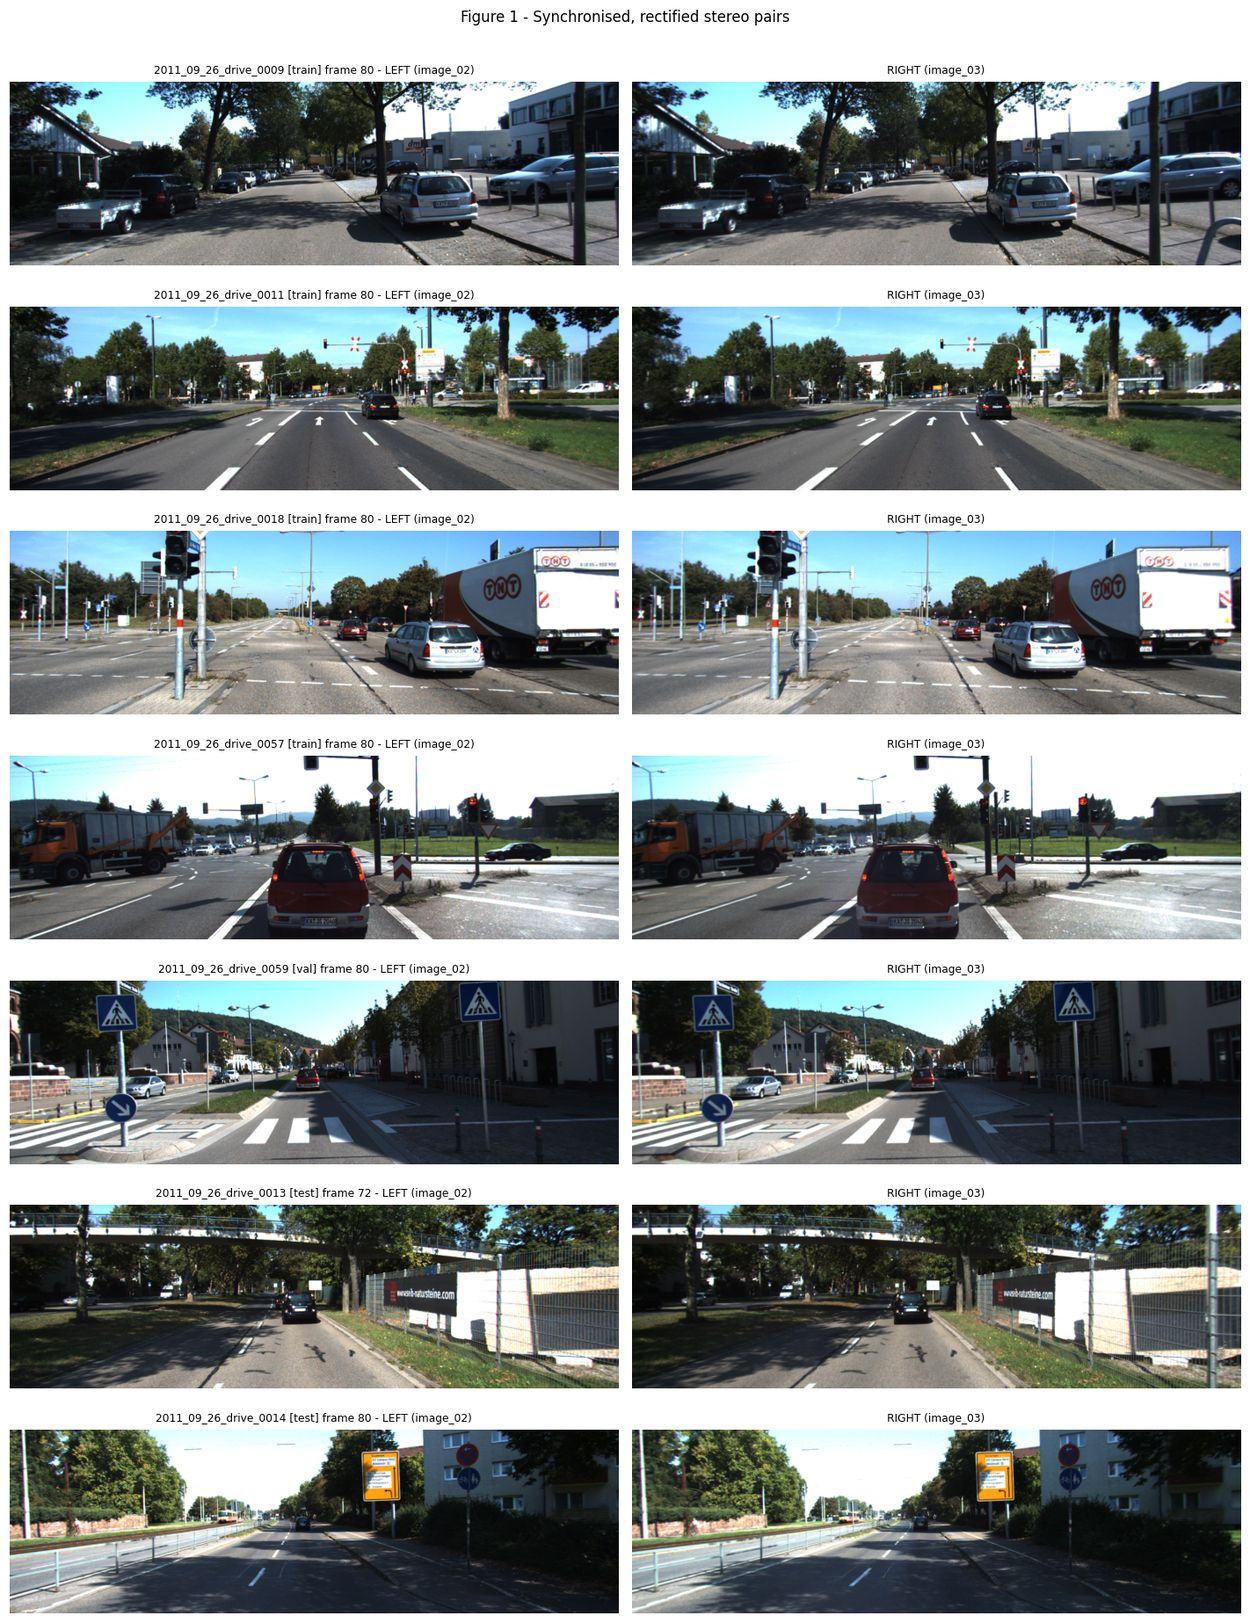

In [5]:
# ---------------------------------------------------------------------------
# Section 7 - Dataset access + exploration
# ---------------------------------------------------------------------------
from datetime import datetime

OXTS_FIELDS = [
    "lat", "lon", "alt", "roll", "pitch", "yaw", "vn", "ve", "vf", "vl", "vu",
    "ax", "ay", "az", "af", "al", "au", "wx", "wy", "wz", "wf", "wl", "wu",
    "pos_accuracy", "vel_accuracy", "navstat", "numsats", "posmode", "velmode", "orimode",
]


class KittiRawDrive:
    """Lazy reader for one synchronised + rectified KITTI raw drive."""

    def __init__(self, data_dir: Path, drive: str, max_frames: int, stride: int = 1):
        self.drive = drive
        self.date = drive[:10]
        self.root = data_dir / self.date / f"{drive}_sync"
        assert self.root.is_dir(), f"drive not found: {self.root}"
        self.left_files = sorted((self.root / "image_02" / "data").glob("*.png"))
        self.right_files = sorted((self.root / "image_03" / "data").glob("*.png"))
        n = min(len(self.left_files), len(self.right_files), max_frames)
        self.frames: List[int] = list(range(0, n, stride))
        self.oxts_files = sorted((self.root / "oxts" / "data").glob("*.txt"))
        self.velo_files = sorted((self.root / "velodyne_points" / "data").glob("*.bin"))
        self.timestamps = self._read_timestamps(self.root / "image_02" / "timestamps.txt")
        self.tracklet_path = self.root / "tracklet_labels.xml"

    # -- basics ------------------------------------------------------------
    def __len__(self) -> int:
        return len(self.frames)

    @staticmethod
    def _read_timestamps(path: Path) -> List[float]:
        """KITTI timestamps -> seconds since the first frame of the drive."""
        if not path.exists():
            return []
        out = []
        for line in path.read_text().strip().splitlines():
            line = line.strip()[:26]  # 'YYYY-MM-DD HH:MM:SS.ffffff'
            try:
                out.append(datetime.strptime(line, "%Y-%m-%d %H:%M:%S.%f").timestamp())
            except ValueError:
                continue
        return [t - out[0] for t in out] if out else []

    def time_of(self, frame: int) -> float:
        """Seconds since drive start; falls back to a nominal 10 Hz clock."""
        if frame < len(self.timestamps):
            return self.timestamps[frame]
        return frame * 0.1

    # -- sensors -----------------------------------------------------------
    def load_left(self, frame: int) -> np.ndarray:
        img = cv2.imread(str(self.left_files[frame]), cv2.IMREAD_COLOR)
        assert img is not None, f"failed to read {self.left_files[frame]}"
        return img

    def load_right(self, frame: int) -> np.ndarray:
        img = cv2.imread(str(self.right_files[frame]), cv2.IMREAD_COLOR)
        assert img is not None, f"failed to read {self.right_files[frame]}"
        return img

    def load_stereo(self, frame: int) -> Tuple[np.ndarray, np.ndarray]:
        return self.load_left(frame), self.load_right(frame)

    def load_oxts(self, frame: int) -> Optional[Dict[str, float]]:
        if frame >= len(self.oxts_files):
            return None
        vals = [float(v) for v in self.oxts_files[frame].read_text().split()]
        return dict(zip(OXTS_FIELDS, vals))

    def load_velo(self, frame: int) -> Optional[np.ndarray]:
        """(N,4) array of x, y, z, reflectance in the Velodyne frame."""
        if frame >= len(self.velo_files):
            return None
        return np.fromfile(str(self.velo_files[frame]), dtype=np.float32).reshape(-1, 4)

    @property
    def has_oxts(self) -> bool:
        return len(self.oxts_files) > 0

    @property
    def has_velo(self) -> bool:
        return len(self.velo_files) > 0


DRIVE_OBJ: Dict[str, KittiRawDrive] = {
    d: KittiRawDrive(READ_DIR, d, MAX_FRAMES, CONFIG["frame_stride"]) for d in DRIVES
}

rows = []
for d, ds in DRIVE_OBJ.items():
    ts = [ds.time_of(f) for f in ds.frames]
    dts = np.diff(ts) if len(ts) > 1 else np.array([0.1])
    ox = ds.load_oxts(ds.frames[0]) if ds.has_oxts else None
    rows.append({
        "drive": d, "split": SPLIT_OF_DRIVE[d], "frames": len(ds),
        "duration_s": round(ts[-1] - ts[0], 2) if len(ts) > 1 else 0.0,
        "mean_dt_s": round(float(dts.mean()), 4),
        "fps": round(1.0 / float(dts.mean()), 2) if dts.mean() > 0 else np.nan,
        "oxts": ds.has_oxts, "velodyne": ds.has_velo,
        "tracklets": ds.tracklet_path.exists(),
        "ego_speed0_kmh": round(ox["vf"] * 3.6, 1) if ox else np.nan,
    })
EXPLORE_DF = pd.DataFrame(rows)
display(EXPLORE_DF)
NOTES["frame_rate"] = f"mean inter-frame interval {EXPLORE_DF['mean_dt_s'].mean():.4f} s (~10 Hz)"
log(NOTES["frame_rate"])

# Sample stereo pairs from each split
fig, axes = plt.subplots(len(DRIVE_OBJ), 2, figsize=(13, 2.4 * len(DRIVE_OBJ)))
axes = np.atleast_2d(axes)
for i, (d, ds) in enumerate(DRIVE_OBJ.items()):
    f0 = ds.frames[len(ds) // 2]
    l, r = ds.load_stereo(f0)
    axes[i, 0].imshow(cv2.cvtColor(l, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"{d} [{SPLIT_OF_DRIVE[d]}] frame {f0} - LEFT (image_02)", fontsize=8)
    axes[i, 1].imshow(cv2.cvtColor(r, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title("RIGHT (image_03)", fontsize=8)
    for ax in axes[i]:
        ax.axis("off")
plt.suptitle("Figure 1 - Synchronised, rectified stereo pairs", y=1.005)
plt.tight_layout()
plt.show()
del l, r

## 8. Camera Calibration — and 9. The Camera Model

### Intrinsics

A pinhole camera maps a 3D point in **camera coordinates** to pixels through

$$
K=\begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1\end{bmatrix}
$$

* $f_x, f_y$ are the focal length **expressed in pixels**: the physical focal length divided
  by the physical pixel pitch. They convert an angle into a pixel offset. A large $f_x$ means
  a narrow field of view — objects subtend more pixels, so depth from disparity is more precise.
* $c_x, c_y$ are the **principal point**: where the optical axis pierces the sensor. It is
  near, but not exactly at, the image centre because the sensor is never perfectly aligned
  with the lens. For KITTI's cropped/rectified images $c_x \approx 609$ on a 1242-wide image.

### Extrinsics

A point in a world frame is brought into the camera frame by a rigid transform

$$
P_c = R\,P_w + t
$$

$R$ is a $3\times3$ rotation (orientation of the world axes seen from the camera) and $t$ a
translation (position of the world origin in camera coordinates). Six degrees of freedom, no
change of shape or scale — this is *where the camera is*, whereas $K$ is *what the camera is*.

### Full projection

$$
p \sim K\,[R\mid t]\,P_w
$$

The $\sim$ matters: the result is a **homogeneous** 3-vector $(\tilde u,\tilde v,\tilde w)$, and the
pixel is $(\tilde u/\tilde w,\; \tilde v/\tilde w)$. That division by depth is the projection itself
— and it is exactly the information a single image destroys. One image gives a *ray*, not a point.
Recovering the missing scalar is what the second camera is for.

### KITTI's calibration files

* `calib_cam_to_cam.txt` — for each camera `i`: `K_0i`, `D_0i` (raw intrinsics/distortion),
  `R_rect_0i`, and `P_rect_0i`, the $3\times4$ projection matrix **of the rectified camera**.
* `calib_velo_to_cam.txt` — rigid transform Velodyne → camera 0.
* `calib_imu_to_velo.txt` — rigid transform IMU/GPS → Velodyne.

The `_sync` images we use are already **undistorted and rectified**, so `P_rect_02` is the
operative camera matrix and the distortion coefficients do not apply to them. `P_rect_0i` has
the form

$$
P_{\text{rect}}^{(i)}=\begin{bmatrix} f_x & 0 & c_x & -f_x b_i \\ 0 & f_y & c_y & 0 \\ 0&0&1&0\end{bmatrix}
$$

so the physical x-position of camera $i$ relative to the rectified reference camera is
$b_i = -P^{(i)}_{03}/f_x$, and the **stereo baseline** is $B=|b_3-b_2|$.
Nothing is hard-coded below: $f$, $c$ and $B$ all come out of the file.

In [6]:
# ---------------------------------------------------------------------------
# Sections 8-9 - Calibration parsing and the camera model
# ---------------------------------------------------------------------------
@dataclass
class KittiCalib:
    """Parsed calibration for one recording date (shared by all its drives)."""
    K2: np.ndarray            # 3x3 intrinsics of the RECTIFIED left colour camera
    P2: np.ndarray            # 3x4 projection, rectified left colour (cam2)
    P3: np.ndarray            # 3x4 projection, rectified right colour (cam3)
    R_rect_00: np.ndarray     # 3x3 rectifying rotation of the reference camera
    T_cam0rect_velo: np.ndarray   # 4x4 Velodyne -> rectified cam0
    T_cam2_velo: np.ndarray       # 4x4 Velodyne -> rectified cam2 frame
    T_velo_imu: np.ndarray        # 4x4 IMU -> Velodyne
    T_cam2_imu: np.ndarray        # 4x4 IMU -> rectified cam2 frame
    img_size: Tuple[int, int]     # (width, height) of the rectified images

    @property
    def fx(self) -> float: return float(self.P2[0, 0])
    @property
    def fy(self) -> float: return float(self.P2[1, 1])
    @property
    def cx(self) -> float: return float(self.P2[0, 2])
    @property
    def cy(self) -> float: return float(self.P2[1, 2])
    @property
    def baseline(self) -> float:
        b2 = -self.P2[0, 3] / self.P2[0, 0]
        b3 = -self.P3[0, 3] / self.P3[0, 0]
        return float(abs(b3 - b2))


def _read_calib_file(path: Path) -> Dict[str, np.ndarray]:
    """KITTI calibration files are 'key: v1 v2 v3 ...' lines."""
    out: Dict[str, np.ndarray] = {}
    for line in path.read_text().splitlines():
        if ":" not in line:
            continue
        key, val = line.split(":", 1)
        try:
            out[key.strip()] = np.array([float(x) for x in val.split()])
        except ValueError:
            pass  # calib_time and similar text fields
    return out


def _rt_to_T(R: np.ndarray, t: np.ndarray) -> np.ndarray:
    T = np.eye(4)
    T[:3, :3] = R.reshape(3, 3)
    T[:3, 3] = t.reshape(3)
    return T


def load_calibration(data_dir: Path, date: str) -> KittiCalib:
    """Parse the three KITTI calibration files and build every transform we need."""
    cdir = data_dir / date
    c2c = _read_calib_file(cdir / "calib_cam_to_cam.txt")
    v2c = _read_calib_file(cdir / "calib_velo_to_cam.txt")
    i2v = _read_calib_file(cdir / "calib_imu_to_velo.txt")

    P2 = c2c["P_rect_02"].reshape(3, 4)
    P3 = c2c["P_rect_03"].reshape(3, 4)
    R_rect_00 = c2c["R_rect_00"].reshape(3, 3)
    size = c2c["S_rect_02"] if "S_rect_02" in c2c else np.array([1242.0, 375.0])

    # Velodyne -> unrectified cam0 -> rectified cam0
    T_cam0_velo = _rt_to_T(v2c["R"], v2c["T"])
    R_rect_4 = np.eye(4); R_rect_4[:3, :3] = R_rect_00
    T_cam0rect_velo = R_rect_4 @ T_cam0_velo

    # rectified cam0 -> rectified cam2 is a pure x-shift of -P2[0,3]/fx
    T_shift = np.eye(4)
    T_shift[0, 3] = P2[0, 3] / P2[0, 0]
    T_cam2_velo = T_shift @ T_cam0rect_velo

    T_velo_imu = _rt_to_T(i2v["R"], i2v["T"])
    T_cam2_imu = T_cam2_velo @ T_velo_imu

    return KittiCalib(
        K2=P2[:3, :3].copy(), P2=P2, P3=P3, R_rect_00=R_rect_00,
        T_cam0rect_velo=T_cam0rect_velo, T_cam2_velo=T_cam2_velo,
        T_velo_imu=T_velo_imu, T_cam2_imu=T_cam2_imu,
        img_size=(int(size[0]), int(size[1])),
    )


CALIB = load_calibration(READ_DIR, DATE)
FX, FY, CX, CY, BASELINE = CALIB.fx, CALIB.fy, CALIB.cx, CALIB.cy, CALIB.baseline

print("Intrinsic matrix K (rectified left colour camera, cam2):")
print(np.array2string(CALIB.K2, precision=3, suppress_small=True))
print(f"\n  f_x = {FX:.2f} px      f_y = {FY:.2f} px")
print(f"  c_x = {CX:.2f} px      c_y = {CY:.2f} px")
print(f"  stereo baseline B = {BASELINE:.4f} m   (derived from P_rect_02 / P_rect_03, not hard-coded)")
print(f"  calibrated image size = {CALIB.img_size[0]} x {CALIB.img_size[1]}")
print(f"  horizontal field of view = {2 * np.degrees(np.arctan(CALIB.img_size[0] / (2 * FX))):.1f} deg")

# ---- sanity checks on the calibration ---------------------------------------
_probe = DRIVE_OBJ[DRIVES[0]].load_left(0)
H_IMG, W_IMG = _probe.shape[:2]
del _probe

# The 4th column of P_rect encodes the camera's offset from the rectified reference camera,
# scaled by the focal length. It is NOT exactly zero in the vertical entry - KITTI ships
# P_rect_02[1,3] = 0.2164 and P_rect_03[1,3] = 2.1999. What matters physically is the implied
# vertical offset t_y = P[1,3] / f_y, which must be sub-centimetre for the epipolar lines to
# be horizontal. For KITTI that works out to 0.3 mm and 3.0 mm respectively.
TY2 = abs(CALIB.P2[1, 3] / CALIB.P2[1, 1])
TY3 = abs(CALIB.P3[1, 3] / CALIB.P3[1, 1])

CALIB_CHECKS = [
    ("focal length plausible", 200 < FX < 2000, f"f_x = {FX:.1f} px", True),
    ("square pixels (f_x ~ f_y)", abs(FX - FY) / FX < 0.05, f"|f_x-f_y|/f_x = {abs(FX - FY) / FX:.1e}", True),
    ("principal point near centre", 0.3 * W_IMG < CX < 0.7 * W_IMG, f"c_x = {CX:.1f} of {W_IMG} px", True),
    ("baseline plausible", 0.2 < BASELINE < 1.0, f"B = {BASELINE:.4f} m", True),
    ("cameras vertically aligned", max(TY2, TY3) < 0.02, f"max |t_y| = {1000 * max(TY2, TY3):.2f} mm", False),
    ("image size matches S_rect_02", (W_IMG, H_IMG) == CALIB.img_size,
     f"loaded {W_IMG}x{H_IMG}, calib {CALIB.img_size[0]}x{CALIB.img_size[1]}", False),
]
print("\n  calibration sanity checks:")
_fatal = []
for _name, _ok, _detail, _required in CALIB_CHECKS:
    print(f"    [{'PASS' if _ok else 'WARN'}] {_name:30s} {_detail}")
    if not _ok and _required:
        _fatal.append(_name)
assert not _fatal, f"calibration failed a required check: {_fatal}"

# Depth resolution implied by this geometry: dZ/dd = Z^2/(fB)
for _z in (5, 10, 20, 40, 80):
    _dz = _z ** 2 / (FX * BASELINE)
    print(f"  at Z={_z:3d} m, one pixel of disparity error = {_dz:6.3f} m of depth error")

Intrinsic matrix K (rectified left colour camera, cam2):
[[     721.54           0      609.56]
 [          0      721.54      172.85]
 [          0           0           1]]

  f_x = 721.54 px      f_y = 721.54 px
  c_x = 609.56 px      c_y = 172.85 px
  stereo baseline B = 0.5327 m   (derived from P_rect_02 / P_rect_03, not hard-coded)
  calibrated image size = 1242 x 375
  horizontal field of view = 81.4 deg

  calibration sanity checks:
    [PASS] focal length plausible         f_x = 721.5 px
    [PASS] square pixels (f_x ~ f_y)      |f_x-f_y|/f_x = 0.0e+00
    [PASS] principal point near centre    c_x = 609.6 of 1242 px
    [PASS] baseline plausible             B = 0.5327 m
    [PASS] cameras vertically aligned     max |t_y| = 3.05 mm
    [PASS] image size matches S_rect_02   loaded 1242x375, calib 1242x375
  at Z=  5 m, one pixel of disparity error =  0.065 m of depth error
  at Z= 10 m, one pixel of disparity error =  0.260 m of depth error
  at Z= 20 m, one pixel of disparity e

## 10. Stereo Geometry & Epipolar Geometry

Two cameras separated by a baseline $B$ see the same world point at different image
positions. The geometry that links them:

* **Epipolar constraint.** For a point $p_L$ in the left image, its match in the right image
  must lie on a single line — the epipolar line. This is what makes stereo matching a 1D
  search instead of a 2D one. Algebraically $p_R^\top F\, p_L = 0$ with $F$ the fundamental matrix.
* **Rectification.** If we warp both images so the epipolar lines become *horizontal and
  aligned across the two images*, then a point at row $v$ in the left image matches at the
  **same row** $v$ in the right image. The search collapses to a scan along one row.
* **Disparity.** $d = u_L - u_R$, in pixels. Nearby things shift a lot between the two views;
  far things barely shift at all. Hold a finger up and blink one eye then the other — that
  shift is disparity.
* **Depth.** By similar triangles on the rectified pair,

$$
Z = \frac{f\,B}{d}
$$

Read it physically: depth is *inversely* proportional to disparity. Doubling the distance
halves the pixel shift. Differentiating gives $|\partial Z/\partial d| = Z^2/(fB)$ — depth error
grows with the **square** of distance. With KITTI's numbers (printed above) half a pixel of
matching error is centimetres at 5 m and metres at 60 m. Every downstream number in this
notebook — 3D position, speed, TTC — inherits that quadratic degradation, which is why depth
accuracy is reported by distance band rather than as a single average.

Full 3D reconstruction from disparity, in the rectified left-camera frame:

$$
Z=\frac{fB}{d},\qquad X=\frac{(u-c_x)Z}{f_x},\qquad Y=\frac{(v-c_y)Z}{f_y}
$$

## 11. Stereo Rectification (verification, not re-derivation)

KITTI's `_sync` images are **already rectified** by the dataset authors using the full
calibration. Re-rectifying them would degrade the data. Instead the cell below *verifies* the
rectification empirically: it matches ORB features between left and right and measures the
vertical disparity $|v_L - v_R|$, which should be ~0 px for a correctly rectified pair. It
also shows the horizontal disparity, which should be positive (the right camera sees things
shifted left).

ORB correspondences: 300
  median |v_L - v_R|          : 0.00 px  (0 = perfectly rectified)
  90th percentile |v_L - v_R| : 0.00 px
  median horizontal disparity : 13.8 px
  fraction with d > 0         : 99.7%

  => vertical disparity is sub-pixel: the pair is rectified, so a horizontal 1D search is valid.


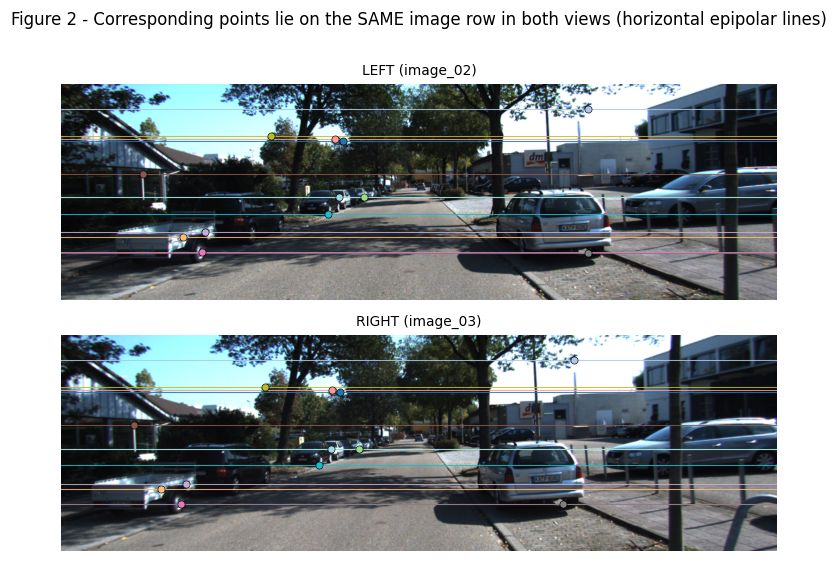

In [7]:
# ---------------------------------------------------------------------------
# Sections 10-11 - Epipolar geometry check on the (already rectified) KITTI pair
# ---------------------------------------------------------------------------
def check_rectification(imgL: np.ndarray, imgR: np.ndarray, max_matches: int = 300) -> Dict[str, float]:
    """Empirically verify horizontal-epipolar geometry using ORB correspondences."""
    gL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    gR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create(nfeatures=3000)
    kL, dL = orb.detectAndCompute(gL, None)
    kR, dR = orb.detectAndCompute(gR, None)
    if dL is None or dR is None or len(kL) < 10 or len(kR) < 10:
        return {}
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = sorted(bf.match(dL, dR), key=lambda m: m.distance)[:max_matches]
    if not matches:
        return {}
    pL = np.array([kL[m.queryIdx].pt for m in matches])
    pR = np.array([kR[m.trainIdx].pt for m in matches])
    dv = np.abs(pL[:, 1] - pR[:, 1])
    du = pL[:, 0] - pR[:, 0]
    keep = du > 0                       # physically valid horizontal disparity
    return {
        "n_matches": int(len(matches)),
        "vertical_disp_median_px": float(np.median(dv)),
        "vertical_disp_p90_px": float(np.percentile(dv, 90)),
        "frac_positive_horizontal_disp": float(keep.mean()),
        "horizontal_disp_median_px": float(np.median(du[keep])) if keep.any() else float("nan"),
        "_pL": pL, "_pR": pR, "_dv": dv,
    }


_ds = DRIVE_OBJ[DRIVES[0]]
_f = _ds.frames[len(_ds) // 2]
imgL_demo, imgR_demo = _ds.load_stereo(_f)
try:
    rect_check = check_rectification(imgL_demo, imgR_demo)
except Exception as e:            # feature detector unavailable in some OpenCV builds
    log(f"rectification check skipped ({type(e).__name__}: {e}) - this section is diagnostic only", "WARN")
    rect_check = {}

if rect_check:
    print(f"ORB correspondences: {rect_check['n_matches']}")
    print(f"  median |v_L - v_R|          : {rect_check['vertical_disp_median_px']:.2f} px  (0 = perfectly rectified)")
    print(f"  90th percentile |v_L - v_R| : {rect_check['vertical_disp_p90_px']:.2f} px")
    print(f"  median horizontal disparity : {rect_check['horizontal_disp_median_px']:.1f} px")
    print(f"  fraction with d > 0         : {rect_check['frac_positive_horizontal_disp']:.1%}")
    METRICS["rectification_vertical_disparity_median_px"] = round(rect_check["vertical_disp_median_px"], 3)
    if rect_check["vertical_disp_median_px"] < 1.5:
        print("\n  => vertical disparity is sub-pixel: the pair is rectified, "
              "so a horizontal 1D search is valid.")
    else:
        log("vertical disparity larger than expected - check the data", "WARN")

    # visualise epipolar alignment
    fig, axes = plt.subplots(2, 1, figsize=(13, 5))
    for ax, img, pts, ttl in [(axes[0], imgL_demo, rect_check["_pL"], "LEFT (image_02)"),
                              (axes[1], imgR_demo, rect_check["_pR"], "RIGHT (image_03)")]:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        sel = np.linspace(0, len(pts) - 1, min(12, len(pts))).astype(int)
        for i, c in zip(sel, plt.cm.tab20(np.linspace(0, 1, len(sel)))):
            ax.axhline(pts[i, 1], color=c, lw=0.7, alpha=0.85)
            ax.scatter(*pts[i], s=22, color=c, edgecolor="k", linewidth=0.4, zorder=3)
        ax.set_title(ttl, fontsize=9); ax.axis("off")
    plt.suptitle("Figure 2 - Corresponding points lie on the SAME image row in both views "
                 "(horizontal epipolar lines)", y=1.01)
    plt.tight_layout(); plt.show()
else:
    log("rectification check skipped (insufficient features)", "WARN")

## 12. Classical Stereo Depth (baseline)

**StereoSGBM** is the classical baseline: semi-global matching aggregates a pixel-wise
matching cost along 8 image paths with a smoothness penalty, approximating a 2D global
optimisation with 1D dynamic programming. It is entirely hand-designed — there is nothing
learned in it.

Two additions to the plain call:

* **Left–right consistency check.** Disparity is computed a second time from the right
  image's point of view and pixels whose two estimates disagree by more than 1 px are
  invalidated. This is the standard way to remove occlusion artefacts, where a surface is
  visible to one camera only and no correct match exists.
* **Explicit invalid mask.** SGBM marks failures with a negative value; we keep an explicit
  boolean mask rather than letting `-1` propagate into depth as a huge negative distance.

### Known failure cases of window-based stereo

| Failure | Why it happens |
|---|---|
| Textureless regions (road surface, plain walls, sky) | The matching cost is flat along the row, so the minimum is arbitrary |
| Reflective / transparent surfaces (windscreens, wet road) | The apparent texture moves with the viewpoint, so it violates the brightness-constancy assumption |
| Occlusion boundaries | The matching pixel simply does not exist in the other view |
| Distant objects | Disparity approaches zero, quantisation dominates, error grows as $Z^2$ |
| Thin structures (poles, sign posts) | Smaller than the aggregation window, so they are smoothed away |
| Repetitive texture (railings, fences) | Multiple equally good matches along the epipolar line |

SGBM: 0.52 s/frame | valid pixels 68.0% | disparity range 0.6-99.5 px | depth range 3.9-99.2 m


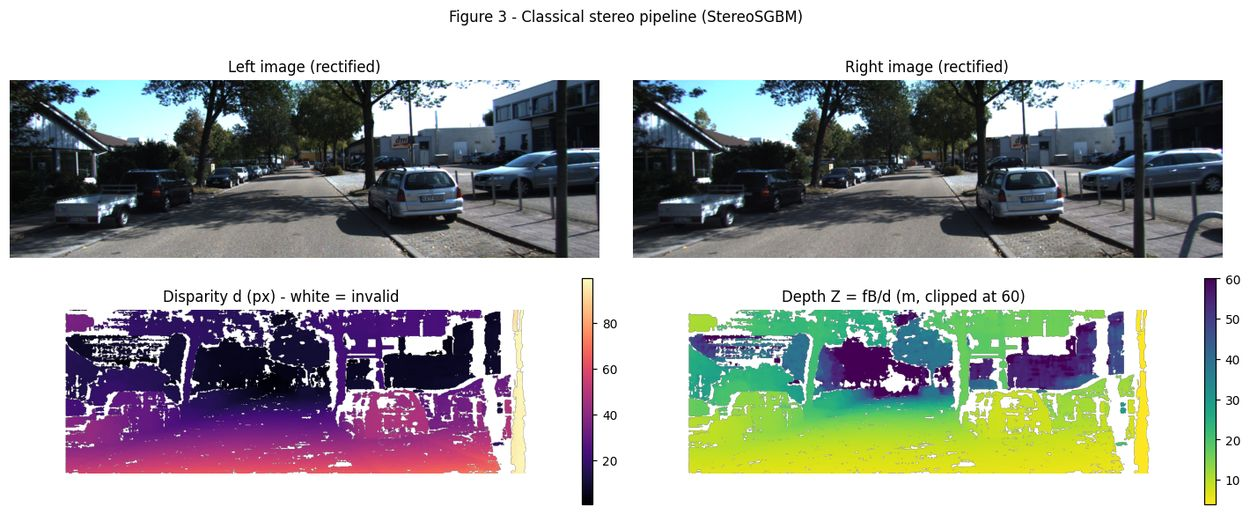


Invalid-disparity rate by local texture energy (failure-mode evidence):
  low texture  : 45.8% invalid
  medium       : 27.9% invalid
  high texture : 22.5% invalid
  left 128px border (no search range): 100.0% invalid


In [8]:
# ---------------------------------------------------------------------------
# Section 12 - Classical stereo: SGBM -> disparity -> depth -> point cloud
# ---------------------------------------------------------------------------
class SGBMStereo:
    """StereoSGBM with an optional left-right consistency check."""

    def __init__(self, num_disp: int = 128, block: int = 5, lr_check: bool = True):
        assert num_disp % 16 == 0, "numDisparities must be divisible by 16"
        self.num_disp, self.lr_check = num_disp, lr_check
        ch = 3
        common = dict(
            minDisparity=0, numDisparities=num_disp, blockSize=block,
            P1=8 * ch * block ** 2, P2=32 * ch * block ** 2,
            disp12MaxDiff=1, uniquenessRatio=10,
            speckleWindowSize=100, speckleRange=2, preFilterCap=63,
            mode=getattr(cv2, "STEREO_SGBM_MODE_SGBM_3WAY", 2),
        )
        self.left = cv2.StereoSGBM_create(**common)
        self.right = cv2.StereoSGBM_create(**common)

    def compute(self, imgL: np.ndarray, imgR: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Return (disparity_float32, valid_mask). Invalid pixels are NaN in disparity."""
        dl = self.left.compute(imgL, imgR).astype(np.float32) / 16.0
        valid = dl > 0.5
        if self.lr_check:
            # Right-view disparity via the flip trick, then cross-check.
            dr = self.right.compute(np.ascontiguousarray(imgR[:, ::-1]),
                                    np.ascontiguousarray(imgL[:, ::-1])).astype(np.float32) / 16.0
            dr = dr[:, ::-1]
            h, w = dl.shape
            uu, _ = np.meshgrid(np.arange(w), np.arange(h))
            src = np.clip((uu - dl).astype(np.int32), 0, w - 1)
            consistent = np.abs(dl - dr[np.arange(h)[:, None], src]) <= 1.0
            valid &= consistent
        out = np.where(valid, dl, np.nan).astype(np.float32)
        return out, valid


def disparity_to_depth(disp: np.ndarray, fx: float, baseline: float,
                       max_depth: float = 100.0) -> np.ndarray:
    """Z = f*B/d, with invalid and out-of-range pixels set to NaN."""
    with np.errstate(divide="ignore", invalid="ignore"):
        z = (fx * baseline) / disp
    z[~np.isfinite(z)] = np.nan
    z[(z <= 0) | (z > max_depth)] = np.nan
    return z.astype(np.float32)


def backproject(u: np.ndarray, v: np.ndarray, z: np.ndarray, calib: KittiCalib) -> np.ndarray:
    """Pixels + depth -> (N,3) points in the rectified cam2 frame."""
    x = (u - calib.cx) * z / calib.fx
    y = (v - calib.cy) * z / calib.fy
    return np.stack([x, y, z], axis=-1)


STEREO = SGBMStereo(CONFIG["sgbm_num_disparities"], CONFIG["sgbm_block_size"])

t0 = time.time()
disp_demo, valid_demo = STEREO.compute(imgL_demo, imgR_demo)
depth_demo = disparity_to_depth(disp_demo, FX, BASELINE, CONFIG["max_object_depth_m"] + 30)
t_sgbm = time.time() - t0

cov = float(np.isfinite(disp_demo).mean())
finite = disp_demo[np.isfinite(disp_demo)]
assert finite.size > 0, "StereoSGBM produced no valid disparity at all - check the image pair"
print(f"SGBM: {t_sgbm:.2f} s/frame | valid pixels {cov:.1%} | "
      f"disparity range {finite.min():.1f}-{finite.max():.1f} px | "
      f"depth range {np.nanmin(depth_demo):.1f}-{np.nanmax(depth_demo):.1f} m")
assert cov > 0.10, f"only {cov:.1%} valid disparities - check that image_02/image_03 are not swapped"
assert finite.max() <= CONFIG["sgbm_num_disparities"], "disparity exceeds the search range"
METRICS["sgbm_valid_pixel_fraction"] = round(cov, 4)
METRICS["sgbm_seconds_per_frame"] = round(t_sgbm, 3)

fig, axes = plt.subplots(2, 2, figsize=(13, 5.2))
axes[0, 0].imshow(cv2.cvtColor(imgL_demo, cv2.COLOR_BGR2RGB)); axes[0, 0].set_title("Left image (rectified)")
axes[0, 1].imshow(cv2.cvtColor(imgR_demo, cv2.COLOR_BGR2RGB)); axes[0, 1].set_title("Right image (rectified)")
im2 = axes[1, 0].imshow(disp_demo, cmap="magma"); axes[1, 0].set_title("Disparity d (px) - white = invalid")
plt.colorbar(im2, ax=axes[1, 0], fraction=0.03)
im3 = axes[1, 1].imshow(np.clip(depth_demo, 0, 60), cmap="viridis_r"); axes[1, 1].set_title("Depth Z = fB/d (m, clipped at 60)")
plt.colorbar(im3, ax=axes[1, 1], fraction=0.03)
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("Figure 3 - Classical stereo pipeline (StereoSGBM)", y=1.01)
plt.tight_layout(); plt.show()

# --- where does stereo fail? -------------------------------------------------
inv = (~np.isfinite(disp_demo)).astype(np.float32)
gray = cv2.cvtColor(imgL_demo, cv2.COLOR_BGR2GRAY)
texture = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
tex_energy = cv2.boxFilter(np.abs(texture), -1, (9, 9))
lo, hi = np.percentile(tex_energy, [33, 67])
print("\nInvalid-disparity rate by local texture energy (failure-mode evidence):")
for name, m in [("low texture", tex_energy <= lo), ("medium", (tex_energy > lo) & (tex_energy < hi)), ("high texture", tex_energy >= hi)]:
    print(f"  {name:13s}: {inv[m].mean():5.1%} invalid")
print(f"  left {CONFIG['sgbm_num_disparities']}px border (no search range): "
      f"{inv[:, :CONFIG['sgbm_num_disparities']].mean():.1%} invalid")

point cloud: 16,219 points | X -27.5..31.5 m, Y -9.8..4.0 m, Z 3.9..44.9 m


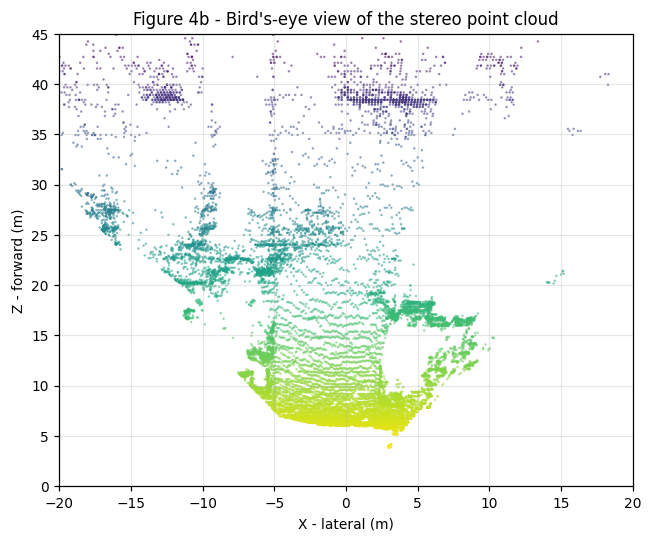

In [9]:
# ---------------------------------------------------------------------------
# Section 12b - 3D point cloud from the stereo pair
# ---------------------------------------------------------------------------
def disparity_to_pointcloud(disp: np.ndarray, img: np.ndarray, calib: KittiCalib,
                            max_depth: float = 50.0, stride: int = 4
                            ) -> Tuple[np.ndarray, np.ndarray]:
    """Subsampled coloured point cloud in the rectified cam2 frame."""
    h, w = disp.shape
    vv, uu = np.mgrid[0:h:stride, 0:w:stride]
    d = disp[::stride, ::stride]
    m = np.isfinite(d) & (d > 0.5)
    z = (calib.fx * calib.baseline) / np.where(m, d, np.nan)
    m &= np.isfinite(z) & (z > 0) & (z < max_depth)
    pts = backproject(uu[m].astype(np.float32), vv[m].astype(np.float32), z[m], calib)
    cols = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[::stride, ::stride][m]
    return pts, cols


pc_pts, pc_cols = disparity_to_pointcloud(disp_demo, imgL_demo, CALIB, max_depth=45.0, stride=4)
assert len(pc_pts) > 0, "empty point cloud - no pixel had a valid in-range disparity"
print(f"point cloud: {len(pc_pts):,} points | "
      f"X {pc_pts[:,0].min():.1f}..{pc_pts[:,0].max():.1f} m, "
      f"Y {pc_pts[:,1].min():.1f}..{pc_pts[:,1].max():.1f} m, "
      f"Z {pc_pts[:,2].min():.1f}..{pc_pts[:,2].max():.1f} m")

if HAVE.get("plotly") and len(pc_pts) > 0:
    import plotly.graph_objects as go
    k = min(30000, len(pc_pts))
    sel = np.random.default_rng(SEED).choice(len(pc_pts), k, replace=False)
    p, c = pc_pts[sel], pc_cols[sel]
    fig = go.Figure(go.Scatter3d(
        x=p[:, 0], y=p[:, 2], z=-p[:, 1], mode="markers",
        marker=dict(size=1.4, color=[f"rgb({r},{g},{b})" for r, g, b in c], opacity=0.85)))
    fig.update_layout(
        title="Figure 4 - Stereo 3D reconstruction (rectified cam2 frame; X right, Z forward, up = -Y)",
        scene=dict(xaxis_title="X right (m)", yaxis_title="Z forward (m)", zaxis_title="height (m)",
                   aspectmode="data"),
        height=560, margin=dict(l=0, r=0, t=40, b=0))
    fig.show()

# Bird's-eye view of the same cloud (robust to plotly being unavailable)
plt.figure(figsize=(6, 5))
plt.scatter(pc_pts[:, 0], pc_pts[:, 2], s=0.4, c=pc_pts[:, 2], cmap="viridis_r", alpha=0.5)
plt.xlabel("X - lateral (m)"); plt.ylabel("Z - forward (m)")
plt.title("Figure 4b - Bird's-eye view of the stereo point cloud")
plt.xlim(-20, 20); plt.ylim(0, 45); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
del pc_pts, pc_cols

### Quantitative stereo evaluation against LiDAR

KITTI raw provides no dense depth ground truth, but each `_sync` archive contains the
**Velodyne HDL-64E** point cloud, which is exactly what the official KITTI stereo benchmark
uses to build its ground truth. Projecting those returns into the rectified left camera gives
a sparse but accurate reference depth (LiDAR range accuracy ~2 cm, far better than stereo).

Protocol, stated so the numbers can be interpreted correctly:

* Velodyne → cam2 via the calibrated transform chain; keep points in front of the camera that
  land inside the image.
* Compare only where **both** LiDAR and stereo have a value; report coverage separately, so a
  method cannot look good by predicting almost nothing.
* Metrics: depth MAE / RMSE (m), disparity MAE (px), and **bad-3px** — the KITTI convention,
  the fraction of pixels whose disparity error exceeds 3 px *and* 5% of the true disparity.
* Reported per distance band, because stereo error grows as $Z^2$.

Two caveats stated up front: LiDAR and camera are ~30 cm apart, so a small number of
comparison pixels are visible to one sensor only, and the sensors are time-synchronised but
not perfectly simultaneous. Both inflate the error slightly for moving objects.

[  520.4s][INFO] evaluating SGBM depth against LiDAR on 12 frames of 2011_09_26_drive_0009
SGBM vs LiDAR over 12 frames  (ground truth = Velodyne)
  depth MAE   : 1.569 m
  depth RMSE  : 4.772 m
  AbsRel      : 0.0631
  disp MAE    : 1.444 px
  bad-3px     : 6.09 %
  delta<1.25  : 0.944
  coverage    : 68.2% of LiDAR pixels also had a stereo estimate

  depth MAE by distance band (the Z^2 error growth, measured):
       0-10m:  0.215 m   (n~4,192 px/frame)
      10-20m:  0.906 m   (n~4,641 px/frame)
      20-40m:  2.614 m   (n~2,354 px/frame)
      40-80m:  7.102 m   (n~1,158 px/frame)


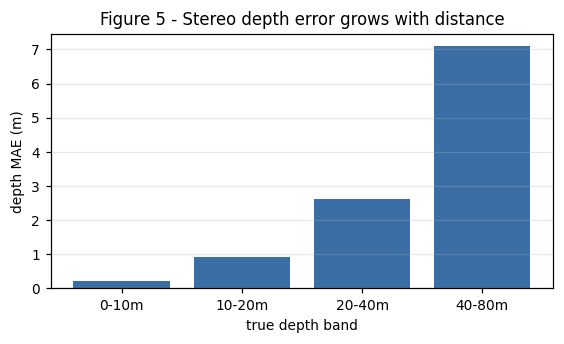

In [10]:
# ---------------------------------------------------------------------------
# Section 12c - Stereo depth evaluation against projected Velodyne returns
# ---------------------------------------------------------------------------
def project_velo_to_image(pts_velo: np.ndarray, calib: KittiCalib, img_shape: Tuple[int, int],
                          min_z: float = 1.0, max_z: float = 90.0
                          ) -> Tuple[np.ndarray, np.ndarray]:
    """Velodyne points -> (uv Nx2 int, depth N) in the rectified cam2 image."""
    h, w = img_shape[:2]
    xyz1 = np.concatenate([pts_velo[:, :3], np.ones((len(pts_velo), 1), np.float32)], axis=1)
    cam = (calib.T_cam2_velo @ xyz1.T).T[:, :3]
    front = (cam[:, 2] > min_z) & (cam[:, 2] < max_z)
    cam = cam[front]
    uv = (calib.K2 @ cam.T).T
    uv = uv[:, :2] / uv[:, 2:3]
    inside = (uv[:, 0] >= 0) & (uv[:, 0] < w) & (uv[:, 1] >= 0) & (uv[:, 1] < h)
    return uv[inside].astype(np.int32), cam[inside, 2]


def sparse_depth_map(pts_velo: np.ndarray, calib: KittiCalib, shape: Tuple[int, int]) -> np.ndarray:
    """Rasterise LiDAR depth, keeping the nearest return per pixel."""
    h, w = shape[:2]
    dm = np.full((h, w), np.inf, np.float32)
    uv, z = project_velo_to_image(pts_velo, calib, shape)
    np.minimum.at(dm, (uv[:, 1], uv[:, 0]), z)
    dm[~np.isfinite(dm)] = np.nan
    return dm


def eval_depth_vs_lidar(pred_depth: np.ndarray, gt_depth: np.ndarray, calib: KittiCalib,
                        bands: Sequence[Tuple[float, float]] = ((0, 10), (10, 20), (20, 40), (40, 80))
                        ) -> Dict[str, Any]:
    """Depth/disparity error metrics on pixels where both sources are valid."""
    m = np.isfinite(pred_depth) & np.isfinite(gt_depth)
    if m.sum() < 50:
        return {}
    p, g = pred_depth[m], gt_depth[m]
    fb = calib.fx * calib.baseline
    dp, dg = fb / p, fb / g
    bad = (np.abs(dp - dg) > 3.0) & (np.abs(dp - dg) / dg > 0.05)   # KITTI bad-3px
    out = {
        "n_pixels": int(m.sum()),
        "coverage_vs_lidar": float(m.sum() / max(1, np.isfinite(gt_depth).sum())),
        "depth_MAE_m": float(np.mean(np.abs(p - g))),
        "depth_RMSE_m": float(np.sqrt(np.mean((p - g) ** 2))),
        "depth_AbsRel": float(np.mean(np.abs(p - g) / g)),
        "disp_MAE_px": float(np.mean(np.abs(dp - dg))),
        "bad3px_pct": float(100 * bad.mean()),
        "delta1_25": float(np.mean(np.maximum(p / g, g / p) < 1.25)),
    }
    for lo, hi in bands:
        b = (g >= lo) & (g < hi)
        if b.sum() > 30:
            out[f"MAE_{lo}-{hi}m"] = float(np.mean(np.abs(p[b] - g[b])))
            out[f"n_{lo}-{hi}m"] = int(b.sum())
    return out


STEREO_EVAL_ROWS: List[Dict[str, Any]] = []
_eval_ds = DRIVE_OBJ[DRIVES[0]]
if _eval_ds.has_velo:
    # LiDAR is downloaded only for the first frames, so evaluate within that range
    n_velo = len(_eval_ds.velo_files)
    n_eval = min(CONFIG["stereo_eval_frames"], len(_eval_ds), n_velo)
    eval_frames = list(np.linspace(0, min(len(_eval_ds), n_velo) - 1, n_eval).astype(int))
    log(f"evaluating SGBM depth against LiDAR on {n_eval} frames of {_eval_ds.drive}")
    for fi in eval_frames:
        f = _eval_ds.frames[fi]
        L, R = _eval_ds.load_stereo(f)
        d, _ = STEREO.compute(L, R)
        z = disparity_to_depth(d, FX, BASELINE, max_depth=90.0)
        velo = _eval_ds.load_velo(f)
        if velo is None:
            continue
        gt = sparse_depth_map(velo, CALIB, L.shape)
        r = eval_depth_vs_lidar(z, gt, CALIB)
        if r:
            r["frame"] = f
            STEREO_EVAL_ROWS.append(r)
        del L, R, d, z, velo, gt

if STEREO_EVAL_ROWS:
    SE = pd.DataFrame(STEREO_EVAL_ROWS)
    agg = SE.drop(columns=["frame"]).mean(numeric_only=True)
    METRICS["stereo_depth_MAE_m"] = round(float(agg["depth_MAE_m"]), 3)
    METRICS["stereo_depth_RMSE_m"] = round(float(agg["depth_RMSE_m"]), 3)
    METRICS["stereo_disp_MAE_px"] = round(float(agg["disp_MAE_px"]), 3)
    METRICS["stereo_bad3px_pct"] = round(float(agg["bad3px_pct"]), 2)
    METRICS["stereo_lidar_coverage"] = round(float(agg["coverage_vs_lidar"]), 3)
    print(f"SGBM vs LiDAR over {len(SE)} frames  (ground truth = Velodyne)")
    print(f"  depth MAE   : {agg['depth_MAE_m']:.3f} m")
    print(f"  depth RMSE  : {agg['depth_RMSE_m']:.3f} m")
    print(f"  AbsRel      : {agg['depth_AbsRel']:.4f}")
    print(f"  disp MAE    : {agg['disp_MAE_px']:.3f} px")
    print(f"  bad-3px     : {agg['bad3px_pct']:.2f} %")
    print(f"  delta<1.25  : {agg['delta1_25']:.3f}")
    print(f"  coverage    : {agg['coverage_vs_lidar']:.1%} of LiDAR pixels also had a stereo estimate")
    band_cols = [c for c in SE.columns if c.startswith("MAE_")]
    if band_cols:
        print("\n  depth MAE by distance band (the Z^2 error growth, measured):")
        for c in band_cols:
            n_c = "n_" + c[4:]
            print(f"    {c[4:]:>8s}: {SE[c].mean():6.3f} m   (n~{int(SE[n_c].mean()):,} px/frame)")
        plt.figure(figsize=(5.2, 3.2))
        plt.bar([c[4:] for c in band_cols], [SE[c].mean() for c in band_cols], color="#3b6ea5")
        plt.ylabel("depth MAE (m)"); plt.xlabel("true depth band")
        plt.title("Figure 5 - Stereo depth error grows with distance"); plt.grid(alpha=0.3, axis="y")
        plt.tight_layout(); plt.show()
else:
    log("no Velodyne data - stereo depth accuracy reported as NOT AVAILABLE", "WARN")
    NOTES["stereo_eval"] = "NOT AVAILABLE - Velodyne scans were not downloaded for this run"

## 13. Learned Stereo / Depth (optional comparison)

The baseline stays classical. For comparison this section runs a **pretrained deep model**:
`torchvision`'s **RAFT** optical-flow network. RAFT builds an all-pairs correlation volume and
iteratively refines a flow field with a GRU update operator. On a *rectified* pair the true
correspondence is purely horizontal, so the flow's x-component is the negative disparity:
$d=-\text{flow}_x$, and $|\text{flow}_y|$ becomes a free confidence signal — it should be ~0,
so large values flag unreliable matches.

**Honest framing:** RAFT is trained for general optical flow, not stereo, and not on KITTI
stereo ground truth here. This is a *cross-task transfer* comparison, so it is not a fair proxy
for a dedicated stereo network (RAFT-Stereo, GwcNet, LEAStereo). It is used because its weights
come bundled with `torchvision` and download reliably in Colab. Both methods are scored with
the identical LiDAR protocol on the identical frames; whichever wins, wins on measured numbers.

If anything in this section fails, it self-disables and the notebook continues.

[  529.4s][INFO] running pretrained RAFT on 4 frames (cuda)
Identical frames (4), identical LiDAR protocol:


,metric,StereoSGBM (classical),"RAFT-small (pretrained, cross-task)"
0,depth MAE (m),1.5633,2.1934
1,depth RMSE (m),4.7799,5.3077
2,disparity MAE (px),1.5015,2.6153
3,bad-3px (%),6.2480,16.3411
4,coverage vs LiDAR,0.6903,0.9834


  -> StereoSGBM had the lower depth MAE on 4 evaluated frames


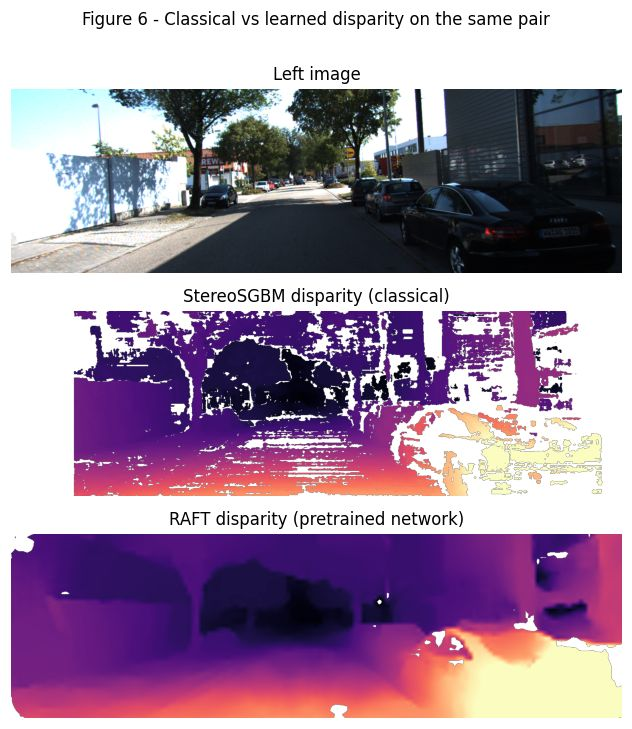

In [11]:
# ---------------------------------------------------------------------------
# Section 13 - Optional learned stereo (pretrained RAFT applied to a rectified pair)
# ---------------------------------------------------------------------------
LEARNED_STEREO_OK = False
LEARNED_EVAL_ROWS: List[Dict[str, Any]] = []
CLASSICAL_PAIRED_ROWS: List[Dict[str, Any]] = []
disp_learned_demo = None

if CONFIG["run_learned_stereo"] and HAVE.get("torchvision") and STEREO_EVAL_ROWS:
    try:
        from torchvision.models.optical_flow import Raft_Small_Weights, raft_small
        _w = Raft_Small_Weights.DEFAULT
        raft = raft_small(weights=_w, progress=True).to(DEVICE).eval()

        @torch.inference_mode()
        def raft_disparity(imgL: np.ndarray, imgR: np.ndarray, max_flow_y: float = 2.0) -> np.ndarray:
            """Disparity from RAFT flow (left->right) on a rectified pair. NaN where unreliable."""
            h, w = imgL.shape[:2]
            ph, pw = (8 - h % 8) % 8, (8 - w % 8) % 8

            def prep(img):
                t = torch.from_numpy(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).permute(2, 0, 1).float() / 255.0
                t = torch.nn.functional.pad(t.unsqueeze(0), (0, pw, 0, ph), mode="replicate")
                return (t * 2.0 - 1.0).to(DEVICE)

            flow = raft(prep(imgL), prep(imgR))[-1][0].cpu().numpy()   # (2,H,W)
            fx_, fy_ = flow[0, :h, :w], flow[1, :h, :w]
            d = -fx_
            ok = (d > 0.5) & (d < CONFIG["sgbm_num_disparities"] * 1.5) & (np.abs(fy_) < max_flow_y)
            return np.where(ok, d, np.nan).astype(np.float32)

        n_l = min(CONFIG["learned_stereo_frames"], len(STEREO_EVAL_ROWS))
        sel_frames = [STEREO_EVAL_ROWS[i]["frame"] for i in np.linspace(0, len(STEREO_EVAL_ROWS) - 1, n_l).astype(int)]
        log(f"running pretrained RAFT on {n_l} frames ({DEVICE})")
        for f in sel_frames:
            L, R = _eval_ds.load_stereo(f)
            velo = _eval_ds.load_velo(f)
            if velo is None:
                continue
            gt = sparse_depth_map(velo, CALIB, L.shape)
            dl = raft_disparity(L, R)
            zl = disparity_to_depth(dl, FX, BASELINE, max_depth=90.0)
            rl = eval_depth_vs_lidar(zl, gt, CALIB)
            dc, _ = STEREO.compute(L, R)
            zc = disparity_to_depth(dc, FX, BASELINE, max_depth=90.0)
            rc = eval_depth_vs_lidar(zc, gt, CALIB)
            if rl and rc:
                rl["frame"] = rc["frame"] = f
                LEARNED_EVAL_ROWS.append(rl); CLASSICAL_PAIRED_ROWS.append(rc)
            if disp_learned_demo is None:
                disp_learned_demo, imgL_learned_demo = dl.copy(), L.copy()
            del L, R, velo, gt, dl, zl, dc, zc
        LEARNED_STEREO_OK = len(LEARNED_EVAL_ROWS) > 0
        if DEVICE.type == "cuda":
            del raft; torch.cuda.empty_cache()
    except Exception as e:
        log(f"learned stereo section disabled: {type(e).__name__}: {e}", "WARN")
        NOTES["learned_stereo"] = f"disabled ({type(e).__name__})"
else:
    NOTES["learned_stereo"] = "skipped (disabled in CONFIG, or no LiDAR reference available)"

if LEARNED_STEREO_OK:
    A, B_ = pd.DataFrame(CLASSICAL_PAIRED_ROWS), pd.DataFrame(LEARNED_EVAL_ROWS)
    cmp = pd.DataFrame({
        "metric": ["depth MAE (m)", "depth RMSE (m)", "disparity MAE (px)", "bad-3px (%)", "coverage vs LiDAR"],
        "StereoSGBM (classical)": [A["depth_MAE_m"].mean(), A["depth_RMSE_m"].mean(),
                                   A["disp_MAE_px"].mean(), A["bad3px_pct"].mean(), A["coverage_vs_lidar"].mean()],
        "RAFT-small (pretrained, cross-task)": [B_["depth_MAE_m"].mean(), B_["depth_RMSE_m"].mean(),
                                                B_["disp_MAE_px"].mean(), B_["bad3px_pct"].mean(), B_["coverage_vs_lidar"].mean()],
    }).round(4)
    print(f"Identical frames ({len(A)}), identical LiDAR protocol:")
    display(cmp)
    METRICS["learned_stereo_depth_MAE_m"] = round(float(B_["depth_MAE_m"].mean()), 3)
    METRICS["learned_stereo_bad3px_pct"] = round(float(B_["bad3px_pct"].mean()), 2)
    better = "RAFT" if B_["depth_MAE_m"].mean() < A["depth_MAE_m"].mean() else "StereoSGBM"
    NOTES["learned_vs_classical"] = f"{better} had the lower depth MAE on {len(A)} evaluated frames"
    print(f"  -> {NOTES['learned_vs_classical']}")
    if disp_learned_demo is not None:
        dc_demo, _ = STEREO.compute(imgL_learned_demo, _eval_ds.load_right(LEARNED_EVAL_ROWS[0]["frame"]))
        fig, ax = plt.subplots(3, 1, figsize=(12, 6.5))
        ax[0].imshow(cv2.cvtColor(imgL_learned_demo, cv2.COLOR_BGR2RGB)); ax[0].set_title("Left image")
        ax[1].imshow(dc_demo, cmap="magma", vmin=0, vmax=80); ax[1].set_title("StereoSGBM disparity (classical)")
        ax[2].imshow(disp_learned_demo, cmap="magma", vmin=0, vmax=80); ax[2].set_title("RAFT disparity (pretrained network)")
        for a in ax: a.axis("off")
        plt.suptitle("Figure 6 - Classical vs learned disparity on the same pair", y=1.01)
        plt.tight_layout(); plt.show()
        del dc_demo
else:
    print(f"Learned stereo comparison: NOT AVAILABLE - {NOTES.get('learned_stereo', 'unavailable')}")
    print("The classical StereoSGBM baseline is used everywhere downstream.")

## 14. Vehicle / Road-User Detection

A **pretrained** YOLO detector (COCO weights) is used. To be explicit: **no detector training
happens in this notebook** — these are off-the-shelf weights, and any detection metric below
measures pretrained-COCO-model transfer to KITTI, not a model we fitted.

COCO's label set does not match KITTI's, so labels are mapped onto standardised categories:

| COCO | KITTI-style class |
|---|---|
| `car` | Car |
| `truck`, `bus` | Truck |
| `person` | Pedestrian |
| `bicycle`, `motorcycle` | Cyclist |

COCO has no `van` class — vans are usually predicted as `car` or `truck`, so a separate *Van*
category cannot be recovered and is folded into the vehicle group. That is a limitation of the
pretrained label space, and it is why the evaluation below merges Car/Van/Truck into a single
**vehicle** class rather than pretending to a distinction the model cannot make.

If `ultralytics` is unavailable, the code falls back to `torchvision`'s Faster R-CNN, which
ships with the same COCO label space.

[  534.0s][INFO] detector: ultralytics yolov8n.pt (pretrained COCO weights)
[  534.6s][INFO] detection on one frame: 0.60 s, 16 road users
class counts: {'Car': 14, 'Truck': 2}


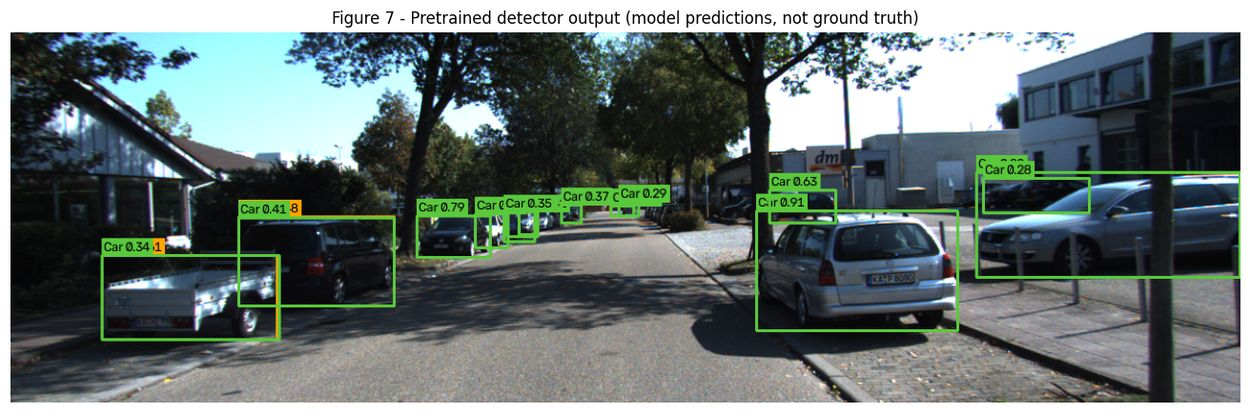

In [12]:
# ---------------------------------------------------------------------------
# Section 14 - Pretrained object detection
# ---------------------------------------------------------------------------
COCO_TO_KITTI = {
    "car": "Car", "truck": "Truck", "bus": "Truck",
    "person": "Pedestrian", "bicycle": "Cyclist", "motorcycle": "Cyclist",
}
VEHICLE_CLASSES = {"Car", "Truck", "Van"}
CLASS_COLORS = {"Car": (60, 200, 90), "Truck": (0, 165, 255), "Van": (200, 160, 40),
                "Pedestrian": (60, 90, 240), "Cyclist": (220, 60, 220)}


@dataclass
class Detection:
    bbox: Tuple[float, float, float, float]   # x1, y1, x2, y2
    score: float
    cls: str


class PretrainedDetector:
    """Thin wrapper over a pretrained detector, normalising labels to KITTI-style classes."""

    def __init__(self, weights: str, device: torch.device, conf: float, imgsz: int):
        self.conf, self.imgsz, self.device = conf, imgsz, device
        self.backend = None
        if HAVE.get("ultralytics"):
            try:
                from ultralytics import YOLO
                self.model = YOLO(weights)
                self.names = self.model.names
                self.backend = "ultralytics"
                log(f"detector: ultralytics {weights} (pretrained COCO weights)")
            except Exception as e:
                log(f"ultralytics failed ({e}); falling back to torchvision", "WARN")
        if self.backend is None:
            from torchvision.models.detection import (FasterRCNN_ResNet50_FPN_Weights,
                                                      fasterrcnn_resnet50_fpn)
            w = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
            self.model = fasterrcnn_resnet50_fpn(weights=w).to(device).eval()
            self.names = {i: n for i, n in enumerate(w.meta["categories"])}
            self.backend = "torchvision"
            log("detector: torchvision Faster R-CNN (pretrained COCO weights)")

    @torch.inference_mode()
    def detect(self, img_bgr: np.ndarray) -> List[Detection]:
        out: List[Detection] = []
        if self.backend == "ultralytics":
            res = self.model.predict(img_bgr, conf=self.conf, imgsz=self.imgsz,
                                     device=0 if self.device.type == "cuda" else "cpu",
                                     verbose=False)[0]
            if res.boxes is None or len(res.boxes) == 0:
                return out
            boxes = res.boxes.xyxy.cpu().numpy()
            scores = res.boxes.conf.cpu().numpy()
            clsi = res.boxes.cls.cpu().numpy().astype(int)
            names = res.names
            for b, s, c in zip(boxes, scores, clsi):
                k = COCO_TO_KITTI.get(str(names[int(c)]).lower())
                if k:
                    out.append(Detection(tuple(map(float, b)), float(s), k))
        else:
            t = torch.from_numpy(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)).permute(2, 0, 1).float() / 255.0
            r = self.model([t.to(self.device)])[0]
            for b, s, c in zip(r["boxes"].cpu().numpy(), r["scores"].cpu().numpy(),
                               r["labels"].cpu().numpy()):
                if s < self.conf:
                    continue
                k = COCO_TO_KITTI.get(str(self.names.get(int(c), "")).lower())
                if k:
                    out.append(Detection(tuple(map(float, b)), float(s), k))
        return out


DETECTOR = PretrainedDetector(CONFIG["detector_weights"], DEVICE,
                              CONFIG["detector_conf"], CONFIG["detector_imgsz"])
DETECTOR_NAME = f"{CONFIG['detector_weights']} ({DETECTOR.backend}, pretrained COCO - NOT trained here)"


def draw_detections(img: np.ndarray, dets: Sequence[Detection]) -> np.ndarray:
    vis = img.copy()
    for d in dets:
        x1, y1, x2, y2 = map(int, d.bbox)
        c = CLASS_COLORS.get(d.cls, (200, 200, 200))
        cv2.rectangle(vis, (x1, y1), (x2, y2), c, 2)
        lab = f"{d.cls} {d.score:.2f}"
        (tw, th), _ = cv2.getTextSize(lab, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(vis, (x1, max(0, y1 - th - 5)), (x1 + tw + 4, y1), c, -1)
        cv2.putText(vis, lab, (x1 + 2, max(10, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1)
    return vis


t0 = time.time()
dets_demo = DETECTOR.detect(imgL_demo)
log(f"detection on one frame: {time.time() - t0:.2f} s, {len(dets_demo)} road users")
print("class counts:", pd.Series([d.cls for d in dets_demo]).value_counts().to_dict() if dets_demo else "{}")
METRICS["detector"] = DETECTOR_NAME

plt.figure(figsize=(13, 4))
plt.imshow(cv2.cvtColor(draw_detections(imgL_demo, dets_demo), cv2.COLOR_BGR2RGB))
plt.title("Figure 7 - Pretrained detector output (model predictions, not ground truth)")
plt.axis("off"); plt.tight_layout(); plt.show()

### KITTI tracklet ground truth and detection evaluation

`tracklet_labels.xml` holds human-annotated **3D boxes** in Velodyne coordinates for each
labelled object, with per-frame poses, plus occlusion and truncation states. Projecting the
eight corners of each 3D box into the rectified left image and taking the axis-aligned hull
gives ground-truth 2D boxes.

The evaluation protocol is deliberately stated, because it is *not* the official KITTI
benchmark protocol and should not be compared to leaderboard numbers:

* Ground-truth boxes are kept only if they are in front of the camera, within 60 m, at least
  25 px tall, not fully occluded, and inside the image.
* Predictions and ground truth are both collapsed to `vehicle` / `Pedestrian` / `Cyclist`.
* Greedy score-ordered matching at IoU ≥ 0.5, then precision, recall and all-point average
  precision. There is no KITTI easy/moderate/hard stratification and no 3D IoU.

In [13]:
# ---------------------------------------------------------------------------
# Section 14b - KITTI tracklet ground truth + detection evaluation
# ---------------------------------------------------------------------------
import xml.etree.ElementTree as ET

TRACKLET_TO_STD = {"Car": "vehicle", "Van": "vehicle", "Truck": "vehicle",
                   "Pedestrian": "Pedestrian", "Person (sitting)": "Pedestrian", "Cyclist": "Cyclist"}


def _f(node, tag, default=0.0) -> float:
    el = node.find(tag)
    return float(el.text) if el is not None and el.text is not None else default


def parse_tracklets(xml_path: Path) -> List[Dict[str, Any]]:
    """Parse tracklet_labels.xml -> per-frame 3D boxes in the Velodyne frame."""
    root = ET.parse(str(xml_path)).getroot()
    tl = root.find("tracklets")
    if tl is None:
        return []
    out: List[Dict[str, Any]] = []
    for tid, item in enumerate(tl.findall("item")):
        obj = item.findtext("objectType", default="").strip()
        h, w, l = _f(item, "h"), _f(item, "w"), _f(item, "l")
        first = int(_f(item, "first_frame"))
        poses = item.find("poses")
        if poses is None:
            continue
        for k, p in enumerate(poses.findall("item")):
            state, occ, trunc = _f(p, "state", 2), _f(p, "occlusion", 0), _f(p, "truncation", 0)
            out.append({
                "gt_id": tid, "type": obj, "frame": first + k,
                "h": h, "w": w, "l": l,
                "tx": _f(p, "tx"), "ty": _f(p, "ty"), "tz": _f(p, "tz"), "rz": _f(p, "rz"),
                "state": state, "occlusion": occ, "truncation": trunc,
            })
    return out


def tracklet_to_camera(rec: Dict[str, Any], calib: KittiCalib) -> Dict[str, Any]:
    """3D box (Velodyne) -> 3D centre + projected 2D box in the rectified cam2 frame."""
    l, w, h = rec["l"], rec["w"], rec["h"]
    x = l / 2 * np.array([1, 1, -1, -1, 1, 1, -1, -1], np.float64)
    y = w / 2 * np.array([1, -1, -1, 1, 1, -1, -1, 1], np.float64)
    z = np.array([0, 0, 0, 0, h, h, h, h], np.float64)      # box origin is at its base
    c, s = np.cos(rec["rz"]), np.sin(rec["rz"])
    Rz = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    corners = (Rz @ np.stack([x, y, z])) + np.array([[rec["tx"]], [rec["ty"]], [rec["tz"]]])
    ch = np.concatenate([corners, np.ones((1, 8))], axis=0)
    cam = (calib.T_cam2_velo @ ch)[:3]                       # 3x8 in cam2
    centre_velo = np.array([rec["tx"], rec["ty"], rec["tz"] + h / 2, 1.0])
    centre_cam = (calib.T_cam2_velo @ centre_velo)[:3]
    if np.any(cam[2] <= 0.5):
        return {}
    uv = calib.K2 @ cam
    uv = uv[:2] / uv[2]
    return {
        "bbox": (float(uv[0].min()), float(uv[1].min()), float(uv[0].max()), float(uv[1].max())),
        "X": float(centre_cam[0]), "Y": float(centre_cam[1]), "Z": float(centre_cam[2]),
        "type": rec["type"], "gt_id": rec["gt_id"], "frame": rec["frame"],
        "occlusion": rec["occlusion"], "truncation": rec["truncation"],
    }


def gt_boxes_for_frame(records: List[Dict[str, Any]], frame: int, calib: KittiCalib,
                       shape: Tuple[int, int], max_z: float = 60.0, min_h_px: float = 25.0
                       ) -> List[Dict[str, Any]]:
    """Visible, standardised ground-truth boxes for one frame."""
    H, W = shape[:2]
    out = []
    for r in records:
        if r["frame"] != frame or r["type"] not in TRACKLET_TO_STD:
            continue
        if r["occlusion"] >= 2 or r["truncation"] >= 2:
            continue
        b = tracklet_to_camera(r, calib)
        if not b or b["Z"] > max_z or b["Z"] <= 0:
            continue
        x1, y1, x2, y2 = b["bbox"]
        x1, y1, x2, y2 = max(0, x1), max(0, y1), min(W - 1, x2), min(H - 1, y2)
        if x2 - x1 < 8 or y2 - y1 < min_h_px:
            continue
        b["bbox"] = (x1, y1, x2, y2)
        b["std_cls"] = TRACKLET_TO_STD[r["type"]]
        out.append(b)
    return out


def iou_xyxy(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Pairwise IoU between (N,4) and (M,4) boxes."""
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), np.float32)
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    ar_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    ar_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return (inter / np.maximum(ar_a[:, None] + ar_b[None, :] - inter, 1e-9)).astype(np.float32)


def std_class(k: str) -> str:
    return "vehicle" if k in VEHICLE_CLASSES else k


def average_precision(matched: np.ndarray, scores: np.ndarray, n_gt: int) -> float:
    """All-point-interpolation AP from per-detection TP flags."""
    if n_gt == 0 or len(scores) == 0:
        return float("nan")
    order = np.argsort(-scores)
    tp = matched[order].astype(np.float64)
    fp = 1.0 - tp
    ctp, cfp = np.cumsum(tp), np.cumsum(fp)
    rec = ctp / n_gt
    prec = ctp / np.maximum(ctp + cfp, 1e-9)
    mrec = np.concatenate([[0.0], rec, [1.0]])
    mpre = np.concatenate([[0.0], prec, [0.0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))


TRACKLETS: Dict[str, List[Dict[str, Any]]] = {}
for d in DRIVES:
    p = DRIVE_OBJ[d].tracklet_path
    if p.exists():
        try:
            TRACKLETS[d] = parse_tracklets(p)
            log(f"{d}: parsed {len({r['gt_id'] for r in TRACKLETS[d]})} ground-truth tracklets "
                f"({len(TRACKLETS[d])} object-frames)")
        except Exception as e:
            log(f"{d}: tracklet parsing failed ({e})", "WARN")
HAS_GT = len(TRACKLETS) > 0
if not HAS_GT:
    log("no tracklet annotations available - detection/3D-localisation metrics will be NOT AVAILABLE", "WARN")

[  535.2s][INFO] 2011_09_26_drive_0009: parsed 98 ground-truth tracklets (3205 object-frames)
[  535.2s][INFO] 2011_09_26_drive_0011: parsed 20 ground-truth tracklets (1504 object-frames)
[  535.2s][INFO] 2011_09_26_drive_0018: parsed 15 ground-truth tracklets (768 object-frames)
[  535.3s][INFO] 2011_09_26_drive_0057: parsed 27 ground-truth tracklets (2269 object-frames)
[  535.4s][INFO] 2011_09_26_drive_0059: parsed 60 ground-truth tracklets (4055 object-frames)
[  535.4s][INFO] 2011_09_26_drive_0013: parsed 9 ground-truth tracklets (396 object-frames)
[  535.4s][INFO] 2011_09_26_drive_0014: parsed 41 ground-truth tracklets (1142 object-frames)


,class,n_gt,n_pred,precision@0.5,recall@0.5,AP@0.5,F1
0,vehicle,99,280,0.343,0.97,0.807,0.507
1,Pedestrian,2,8,0.250,1.00,1.000,0.400



mAP@0.5 (mean over evaluated classes): 0.903
Protocol: 24 frames of 2011_09_26_drive_0009, GT = KITTI tracklets (<=60 m, >=25 px tall, occlusion<2, truncation<2), COCO-pretrained detector, no fine-tuning.
These numbers measure zero-shot COCO->KITTI transfer, not the official KITTI benchmark.


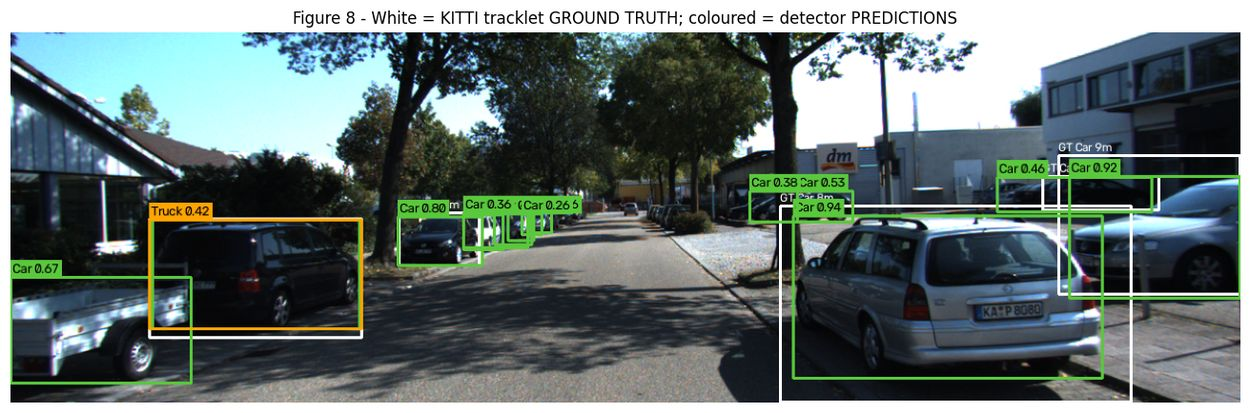

In [14]:
# ---------------------------------------------------------------------------
# Section 14c - Detection evaluation against tracklet ground truth
# ---------------------------------------------------------------------------
DET_EVAL: Dict[str, Any] = {}
if HAS_GT:
    eval_drive = next(iter(TRACKLETS))
    ds_e = DRIVE_OBJ[eval_drive]
    recs = TRACKLETS[eval_drive]
    n_ev = min(CONFIG["stereo_eval_frames"] * 2 if not DEBUG_MODE else 6, len(ds_e))
    frames_ev = [ds_e.frames[i] for i in np.linspace(0, len(ds_e) - 1, n_ev).astype(int)]

    per_class = {c: {"scores": [], "tp": [], "n_gt": 0} for c in ["vehicle", "Pedestrian", "Cyclist"]}
    for f in frames_ev:
        img = ds_e.load_left(f)
        gts = gt_boxes_for_frame(recs, f, CALIB, img.shape)
        dets = DETECTOR.detect(img)
        for c in per_class:
            g = [x for x in gts if x["std_cls"] == c]
            p = [x for x in dets if std_class(x.cls) == c]
            per_class[c]["n_gt"] += len(g)
            if not p:
                continue
            pb = np.array([x.bbox for x in p], np.float32)
            ps = np.array([x.score for x in p], np.float32)
            order = np.argsort(-ps)
            gb = np.array([x["bbox"] for x in g], np.float32) if g else np.zeros((0, 4), np.float32)
            M = iou_xyxy(pb[order], gb)
            used = set()
            for i in range(len(order)):
                j = int(np.argmax(M[i])) if M.shape[1] else -1
                hit = j >= 0 and M[i, j] >= 0.5 and j not in used
                if hit:
                    used.add(j)
                per_class[c]["tp"].append(1.0 if hit else 0.0)
                per_class[c]["scores"].append(float(ps[order][i]))
        del img

    rows = []
    for c, v in per_class.items():
        if v["n_gt"] == 0 and not v["tp"]:
            continue
        tp = np.array(v["tp"]); sc = np.array(v["scores"])
        prec = float(tp.sum() / max(1, len(tp)))
        rec = float(tp.sum() / max(1, v["n_gt"]))
        ap = average_precision(tp, sc, v["n_gt"])
        rows.append({"class": c, "n_gt": v["n_gt"], "n_pred": len(tp),
                     "precision@0.5": round(prec, 3), "recall@0.5": round(rec, 3),
                     "AP@0.5": round(ap, 3) if np.isfinite(ap) else np.nan,
                     "F1": round(2 * prec * rec / max(prec + rec, 1e-9), 3)})
    if rows:
        DET_DF = pd.DataFrame(rows)
        display(DET_DF)
        valid_ap = DET_DF["AP@0.5"].dropna()
        DET_EVAL = {"table": DET_DF, "mAP50": float(valid_ap.mean()) if len(valid_ap) else float("nan")}
        veh = DET_DF[DET_DF["class"] == "vehicle"]
        if len(veh):
            METRICS["detection_vehicle_AP50"] = float(veh["AP@0.5"].iloc[0])
            METRICS["detection_vehicle_precision"] = float(veh["precision@0.5"].iloc[0])
            METRICS["detection_vehicle_recall"] = float(veh["recall@0.5"].iloc[0])
        METRICS["detection_mAP50"] = round(DET_EVAL["mAP50"], 3)
        print(f"\nmAP@0.5 (mean over evaluated classes): {DET_EVAL['mAP50']:.3f}")
        print(f"Protocol: {n_ev} frames of {eval_drive}, GT = KITTI tracklets "
              f"(<=60 m, >=25 px tall, occlusion<2, truncation<2), COCO-pretrained detector, no fine-tuning.")
        print("These numbers measure zero-shot COCO->KITTI transfer, not the official KITTI benchmark.")

    # qualitative: GT vs prediction on one frame
    f_show = frames_ev[len(frames_ev) // 2]
    img = ds_e.load_left(f_show)
    vis = img.copy()
    for g in gt_boxes_for_frame(recs, f_show, CALIB, img.shape):
        x1, y1, x2, y2 = map(int, g["bbox"])
        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 255, 255), 2)
        cv2.putText(vis, f"GT {g['type']} {g['Z']:.0f}m", (x1, max(12, y1 - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, (255, 255, 255), 1)
    vis = draw_detections(vis, DETECTOR.detect(img))
    plt.figure(figsize=(13, 4))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Figure 8 - White = KITTI tracklet GROUND TRUTH; coloured = detector PREDICTIONS")
    plt.axis("off"); plt.tight_layout(); plt.show()
    del img, vis
else:
    print("Detection evaluation: NOT AVAILABLE (no tracklet annotations for the selected drives).")
    NOTES["detection_eval"] = "NOT AVAILABLE - no tracklet ground truth"

## 15. Multi-Object Tracking

Detection gives boxes; trajectories need **identity across frames**. The tracker here is a
**ByteTrack-style SORT**, implemented directly (≈150 lines, no extra dependency, so nothing
can break at install time):

* **Motion model** — one constant-velocity Kalman filter per track on the state
  $[u, v, s, r, \dot u, \dot v, \dot s]$ (box centre, area, aspect ratio and their rates). It
  predicts where each track should be in the next frame, which is what lets a track survive a
  frame or two of missed detection.
* **Association** — IoU cost between predictions and detections solved optimally with the
  Hungarian algorithm (`scipy.optimize.linear_sum_assignment`), not greedy nearest-neighbour.
* **The ByteTrack idea** — two association passes. High-confidence detections are matched
  first; then the *low*-confidence detections that would normally be thrown away are matched
  against the still-unmatched tracks. A partly occluded car often drops to a low score, and
  this second pass is what keeps its ID instead of fragmenting the track.
* **Lifecycle** — a track is only reported after `min_hits` consecutive hits (suppresses
  flicker) and is deleted after `max_age` frames without a match (~1.2 s at 10 Hz).

Track IDs are the backbone of everything downstream: without stable identity there is no
trajectory, and therefore no speed, no TTC and no prediction.

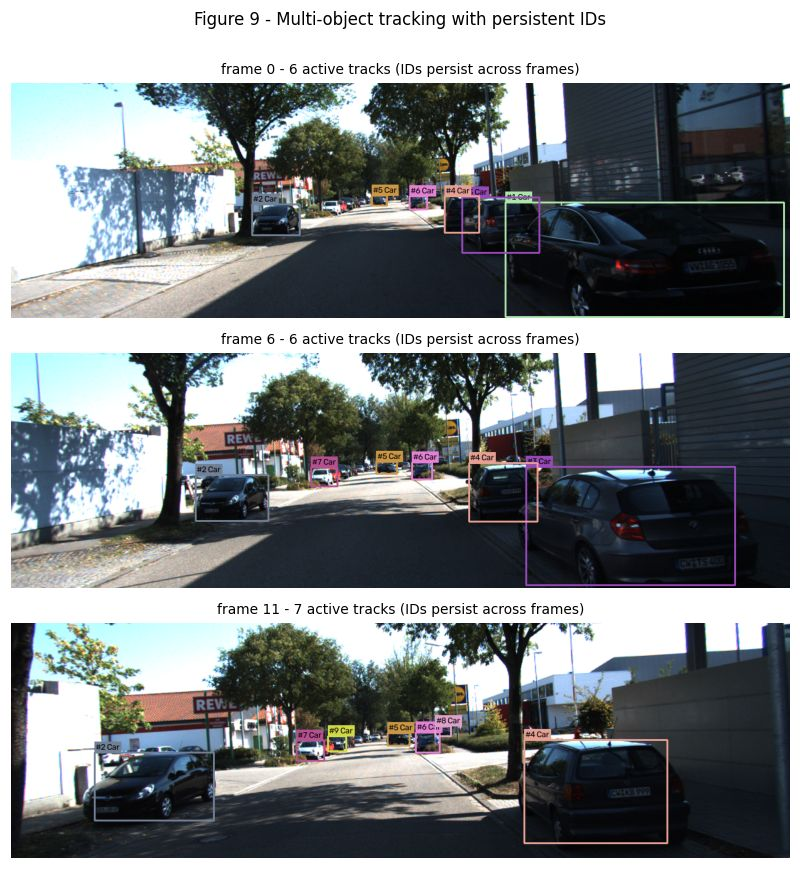

In [15]:
# ---------------------------------------------------------------------------
# Section 15 - ByteTrack-style SORT (Kalman + Hungarian, two-stage association)
# ---------------------------------------------------------------------------
from scipy.optimize import linear_sum_assignment


def _xyxy_to_z(b: Sequence[float]) -> np.ndarray:
    """Box -> [centre_u, centre_v, area, aspect]."""
    w, h = b[2] - b[0], b[3] - b[1]
    return np.array([b[0] + w / 2, b[1] + h / 2, w * h, w / max(h, 1e-6)], np.float64).reshape(4, 1)


def _z_to_xyxy(z: np.ndarray) -> Tuple[float, float, float, float]:
    z = np.asarray(z, dtype=np.float64).reshape(-1)
    s, r = max(float(z[2]), 1.0), max(float(z[3]), 1e-3)
    w = math.sqrt(s * r); h = s / max(w, 1e-6)
    return (float(z[0] - w / 2), float(z[1] - h / 2), float(z[0] + w / 2), float(z[1] + h / 2))


class KalmanBoxTracker:
    """Constant-velocity Kalman filter on box centre / area / aspect ratio."""
    _next_id = 1

    def __init__(self, det: Detection):
        self.F = np.eye(7)
        for i in range(3):
            self.F[i, i + 4] = 1.0
        self.H = np.zeros((4, 7)); self.H[:4, :4] = np.eye(4)
        self.P = np.eye(7) * 10.0
        self.P[4:, 4:] *= 1000.0                 # velocities start highly uncertain
        self.Q = np.eye(7); self.Q[4:, 4:] *= 0.01; self.Q[-1, -1] *= 0.01
        self.R = np.diag([1.0, 1.0, 10.0, 10.0])  # area/aspect are the noisiest observations
        self.x = np.zeros((7, 1)); self.x[:4] = _xyxy_to_z(det.bbox)
        self.id = KalmanBoxTracker._next_id; KalmanBoxTracker._next_id += 1
        self.cls, self.score = det.cls, det.score
        self.time_since_update = 0
        self.hits = 1
        self.age = 0

    def predict(self) -> Tuple[float, float, float, float]:
        if self.x[6] + self.x[2] <= 0:
            self.x[6] *= 0.0
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        self.age += 1
        self.time_since_update += 1
        return _z_to_xyxy(self.x)

    def update(self, det: Detection) -> None:
        z = _xyxy_to_z(det.bbox)
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(7) - K @ self.H) @ self.P
        self.time_since_update = 0
        self.hits += 1
        self.score = det.score
        if det.score > 0.4:
            self.cls = det.cls

    @property
    def bbox(self) -> Tuple[float, float, float, float]:
        return _z_to_xyxy(self.x)


def _associate(track_boxes: np.ndarray, det_boxes: np.ndarray, thr: float
               ) -> Tuple[List[Tuple[int, int]], List[int], List[int]]:
    """Optimal IoU assignment; returns (matches, unmatched_tracks, unmatched_dets)."""
    if len(track_boxes) == 0 or len(det_boxes) == 0:
        return [], list(range(len(track_boxes))), list(range(len(det_boxes)))
    M = iou_xyxy(track_boxes, det_boxes)
    ti, di = linear_sum_assignment(-M)
    matches = [(int(t), int(d)) for t, d in zip(ti, di) if M[t, d] >= thr]
    mt = {t for t, _ in matches}; mdd = {d for _, d in matches}
    return matches, [i for i in range(len(track_boxes)) if i not in mt], \
                    [j for j in range(len(det_boxes)) if j not in mdd]


class ByteTrackLite:
    """Two-stage IoU tracker with Kalman motion prediction."""

    def __init__(self, iou_thr: float = 0.3, max_age: int = 12, min_hits: int = 3,
                 high_thr: float = 0.5, low_thr: float = 0.1):
        self.iou_thr, self.max_age, self.min_hits = iou_thr, max_age, min_hits
        self.high_thr, self.low_thr = high_thr, low_thr
        self.tracks: List[KalmanBoxTracker] = []
        self.frame_count = 0

    def update(self, dets: Sequence[Detection]) -> List[Dict[str, Any]]:
        self.frame_count += 1
        pred = np.array([t.predict() for t in self.tracks], np.float32).reshape(-1, 4)
        high = [d for d in dets if d.score >= self.high_thr]
        low = [d for d in dets if self.low_thr <= d.score < self.high_thr]

        # stage 1: confident detections
        hb = np.array([d.bbox for d in high], np.float32).reshape(-1, 4)
        m1, ut, ud = _associate(pred, hb, self.iou_thr)
        for t, d in m1:
            self.tracks[t].update(high[d])

        # stage 2: rescue occluded tracks with weak detections
        if low and ut:
            lb = np.array([d.bbox for d in low], np.float32)
            m2, ut2, _ = _associate(pred[ut], lb, max(0.2, self.iou_thr - 0.1))
            for t, d in m2:
                self.tracks[ut[t]].update(low[d])
            ut = [ut[i] for i in ut2]

        for j in ud:
            self.tracks.append(KalmanBoxTracker(high[j]))
        self.tracks = [t for t in self.tracks if t.time_since_update <= self.max_age]

        return [{"track_id": t.id, "cls": t.cls, "score": t.score, "bbox": t.bbox,
                 "age": t.age, "hits": t.hits, "predicted_only": t.time_since_update > 0}
                for t in self.tracks
                if t.time_since_update <= 1
                and (t.hits >= self.min_hits or self.frame_count <= self.min_hits)]


def color_for_id(tid: int) -> Tuple[int, int, int]:
    rng = np.random.default_rng(tid * 9781 + 13)
    return tuple(int(x) for x in rng.integers(60, 235, 3))


def draw_tracks(img: np.ndarray, tracks: Sequence[Dict[str, Any]],
                extra: Optional[Dict[int, str]] = None) -> np.ndarray:
    vis = img.copy()
    for t in tracks:
        x1, y1, x2, y2 = map(int, t["bbox"])
        c = color_for_id(t["track_id"])
        cv2.rectangle(vis, (x1, y1), (x2, y2), c, 2)
        lab = f"#{t['track_id']} {t['cls']}"
        if extra and t["track_id"] in extra:
            lab += " " + extra[t["track_id"]]
        (tw, th), _ = cv2.getTextSize(lab, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(vis, (x1, max(0, y1 - th - 5)), (x1 + tw + 4, y1), c, -1)
        cv2.putText(vis, lab, (x1 + 2, max(10, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1)
    return vis


# quick visual check on a short burst of frames
_tk = ByteTrackLite(CONFIG["track_iou_threshold"], CONFIG["track_max_age"], CONFIG["track_min_hits"])
_demo_frames = _ds.frames[: min(12, len(_ds))]
_snaps = []
for f in _demo_frames:
    im = _ds.load_left(f)
    tr = _tk.update(DETECTOR.detect(im))
    _snaps.append((f, draw_tracks(im, tr), len(tr)))
    del im
sel = [0, len(_snaps) // 2, len(_snaps) - 1]
fig, axes = plt.subplots(len(sel), 1, figsize=(12, 2.6 * len(sel)))
for ax, i in zip(np.atleast_1d(axes), sel):
    f, vis, n = _snaps[i]
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {f} - {n} active tracks (IDs persist across frames)", fontsize=9)
    ax.axis("off")
plt.suptitle("Figure 9 - Multi-object tracking with persistent IDs", y=1.005)
plt.tight_layout(); plt.show()
del _snaps, _tk

## 16. 3D Vehicle Localisation

Each tracked box must become a 3D point. Three details matter more than they look:

**1. Which pixel represents the vehicle?**
Not the box centre. The centre of a car's 2D box floats somewhere inside the body, and as the
car turns or is truncated by the image edge that point slides around the object. The
**bottom-centre** of the box is used instead: it approximates the contact point between the
vehicle and the road, which is the physically meaningful location for a bird's-eye trajectory
and is stable under changes of viewpoint and box height.

**2. Which depth?**
A single pixel's disparity is noisy and often invalid. Depth is taken as a **robust statistic
over a patch**: the central 60% of the box width and the lower 45% of its height — the region
most likely to be on the vehicle body and least likely to include background sky or the road
in front. Within that patch, disparities outside the 20th–80th percentile band are discarded
(removes background bleed-through at the silhouette, which would otherwise pull depth
outwards) and the **median** of the rest is used. Detections with fewer than
`min_valid_disp_pixels` valid pixels get no 3D position rather than a fabricated one.

**3. Depth in the *median-disparity* sense, not median depth.**
Because $Z=fB/d$ is non-linear, averaging depths and averaging disparities give different
answers. The median is taken in **disparity** space where the matching noise is roughly
symmetric, then converted once.

Back-projection then gives the position in the rectified cam2 frame
($X$ right, $Y$ down, $Z$ forward):

$$
X=\frac{(u-c_x)Z}{f_x},\qquad Y=\frac{(v-c_y)Z}{f_y},\qquad Z=\frac{fB}{d}
$$

3D localisation vs KITTI tracklet ground truth (GT boxes, so detection errors excluded):
  n                     : 55.000
  recall                : 0.902
  Z_bias_m              : -2.012
  Z_MAE_m               : 2.361
  Z_RMSE_m              : 5.018
  Z_MAE_debiased_m      : 1.933
  X_MAE_m               : 0.737
  (Z_bias is expected to be negative: GT marks the box centre, the stereo
   estimate marks the visible near surface ~half a vehicle length closer.)


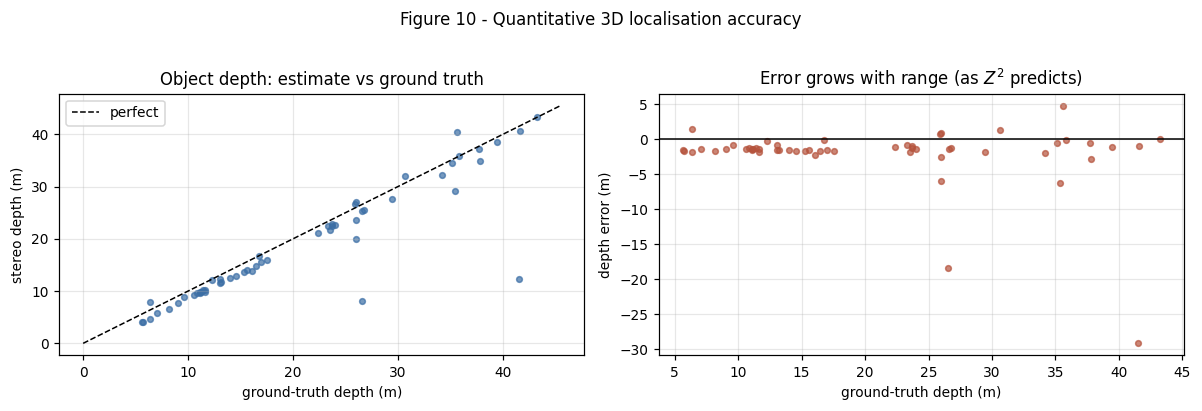

In [16]:
# ---------------------------------------------------------------------------
# Section 16 - 3D localisation of a tracked box from the disparity map
# ---------------------------------------------------------------------------
def localize_box(bbox: Sequence[float], disp: np.ndarray, calib: KittiCalib,
                 min_pixels: int = 40, max_depth: float = 70.0
                 ) -> Optional[Dict[str, float]]:
    """Robust 3D position (rectified cam2 frame) for one detection box."""
    h, w = disp.shape
    x1, y1, x2, y2 = bbox
    bw, bh = x2 - x1, y2 - y1
    if bw < 8 or bh < 8:
        return None
    # sampling patch: central 60% width, lower 45% height (vehicle body, above the wheels)
    px1 = int(max(0, x1 + 0.20 * bw)); px2 = int(min(w, x2 - 0.20 * bw))
    py1 = int(max(0, y1 + 0.55 * bh)); py2 = int(min(h, y2 - 0.05 * bh))
    if px2 - px1 < 3 or py2 - py1 < 3:
        return None
    patch = disp[py1:py2, px1:px2]
    vals = patch[np.isfinite(patch)]
    if vals.size < min_pixels:
        return None
    lo, hi = np.percentile(vals, [20, 80])
    core = vals[(vals >= lo) & (vals <= hi)]
    if core.size < max(8, min_pixels // 4):
        return None
    d_med = float(np.median(core))
    if d_med <= 0.5:
        return None
    Z = calib.fx * calib.baseline / d_med
    if not np.isfinite(Z) or Z <= 0 or Z > max_depth:
        return None
    u = float((x1 + x2) / 2.0)                 # bottom-centre of the box = road contact point
    v = float(min(y2, h - 1))
    X = (u - calib.cx) * Z / calib.fx
    Y = (v - calib.cy) * Z / calib.fy
    return {"u": u, "v": v, "disp": d_med, "Xc": float(X), "Yc": float(Y), "Zc": float(Z),
            "n_disp_px": int(core.size), "disp_iqr": float(hi - lo)}


# --- validate the localiser against tracklet ground truth ---------------------
LOC_EVAL: Dict[str, Any] = {}
if HAS_GT:
    eval_drive = next(iter(TRACKLETS))
    ds_e = DRIVE_OBJ[eval_drive]; recs = TRACKLETS[eval_drive]
    n_ev = min(8 if DEBUG_MODE else 15, len(ds_e))
    rows = []
    for fi in np.linspace(0, len(ds_e) - 1, n_ev).astype(int):
        f = ds_e.frames[fi]
        L, R = ds_e.load_stereo(f)
        d, _ = STEREO.compute(L, R)
        gts = [g for g in gt_boxes_for_frame(recs, f, CALIB, L.shape) if g["std_cls"] == "vehicle"]
        for g in gts:
            est = localize_box(g["bbox"], d, CALIB, CONFIG["min_valid_disp_pixels"],
                               CONFIG["max_object_depth_m"])
            if est is None:
                rows.append({"gt_Z": g["Z"], "est_Z": np.nan, "gt_X": g["X"], "est_X": np.nan})
                continue
            rows.append({"gt_Z": g["Z"], "est_Z": est["Zc"], "gt_X": g["X"], "est_X": est["Xc"]})
        del L, R, d
    LOC = pd.DataFrame(rows)
    ok = LOC.dropna()
    if len(ok) >= 5:
        # GT is the 3D box CENTRE; our estimate is the visible-surface contact point, so a
        # systematic near-side bias of roughly half a vehicle length is expected. Report both.
        errZ = ok["est_Z"] - ok["gt_Z"]
        errX = ok["est_X"] - ok["gt_X"]
        LOC_EVAL = {
            "n": int(len(ok)),
            "recall": float(len(ok) / max(1, len(LOC))),
            "Z_bias_m": float(errZ.mean()),
            "Z_MAE_m": float(errZ.abs().mean()),
            "Z_RMSE_m": float(np.sqrt((errZ ** 2).mean())),
            "Z_MAE_debiased_m": float((errZ - errZ.mean()).abs().mean()),
            "X_MAE_m": float(errX.abs().mean()),
        }
        METRICS["object_depth_MAE_m"] = round(LOC_EVAL["Z_MAE_m"], 3)
        METRICS["object_depth_RMSE_m"] = round(LOC_EVAL["Z_RMSE_m"], 3)
        METRICS["object_lateral_MAE_m"] = round(LOC_EVAL["X_MAE_m"], 3)
        METRICS["localisation_success_rate"] = round(LOC_EVAL["recall"], 3)
        print("3D localisation vs KITTI tracklet ground truth (GT boxes, so detection errors excluded):")
        for k, v in LOC_EVAL.items():
            print(f"  {k:22s}: {v:.3f}")
        print("  (Z_bias is expected to be negative: GT marks the box centre, the stereo")
        print("   estimate marks the visible near surface ~half a vehicle length closer.)")

        fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
        ax[0].scatter(ok["gt_Z"], ok["est_Z"], s=14, alpha=0.7, color="#3b6ea5")
        lim = [0, max(ok["gt_Z"].max(), ok["est_Z"].max()) * 1.05]
        ax[0].plot(lim, lim, "k--", lw=1, label="perfect")
        ax[0].set_xlabel("ground-truth depth (m)"); ax[0].set_ylabel("stereo depth (m)")
        ax[0].set_title("Object depth: estimate vs ground truth"); ax[0].legend(); ax[0].grid(alpha=0.3)
        ax[1].scatter(ok["gt_Z"], errZ, s=14, alpha=0.7, color="#b5533c")
        ax[1].axhline(0, color="k", lw=1)
        ax[1].set_xlabel("ground-truth depth (m)"); ax[1].set_ylabel("depth error (m)")
        ax[1].set_title("Error grows with range (as $Z^2$ predicts)"); ax[1].grid(alpha=0.3)
        plt.suptitle("Figure 10 - Quantitative 3D localisation accuracy", y=1.02)
        plt.tight_layout(); plt.show()
    else:
        log("too few matched objects for a localisation metric", "WARN")
else:
    print("3D localisation accuracy: NOT AVAILABLE (no tracklet ground truth).")
    NOTES["localisation_eval"] = "NOT AVAILABLE - no tracklet ground truth"

## 17. Ego-Motion Compensation

> **A moving camera makes stationary objects appear to move.**

This is the single most important correction in the whole pipeline. If the ego-vehicle drives
forward at 10 m/s, a *parked* car's depth $Z$ shrinks by 1 m per frame. Take the naive finite
difference of its camera-frame position and you conclude the parked car is travelling at
36 km/h — towards you. Every speed, every trajectory and every behaviour label would be wrong.

**The fix.** KITTI records an OXTS RT3003 GPS/IMU packet with every frame: latitude,
longitude, altitude, roll/pitch/yaw and velocities. Converting lat/lon through a Mercator
projection (scaled at the drive's first latitude) and stacking the Euler angles gives the
IMU pose in a local metric world frame, $T_{w\leftarrow\text{imu}}(t)$. Chaining the
calibration transforms gives the camera pose:

$$
T_{w\leftarrow\text{cam2}}(t)=T_{w\leftarrow\text{imu}}(t)\,T_{\text{imu}\leftarrow\text{velo}}\,T_{\text{velo}\leftarrow\text{cam2}}
$$

and a detection's world position is $P_w = T_{w\leftarrow\text{cam2}}(t)\,P_{\text{cam2}}$.
The world frame is anchored at the **first frame of each drive**, so coordinates stay small
and interpretable (metres from the start of the recording).

Two quantities are then kept for every object, and never confused:

| Quantity | Frame | Meaning | Correct use |
|---|---|---|---|
| `Xc, Yc, Zc` | camera (moving) | position **relative to the ego-vehicle** | TTC, collision risk |
| `Xw, Yw, Zw` | world (fixed) | position **on the ground** | speed, trajectory, behaviour, prediction |

Both are physically meaningful — for time-to-collision the *relative* motion is exactly what
you want. The error is using camera-frame differences as if they were world speeds.

**Ground-truth check available here:** OXTS gives true ego velocity, so for objects that are
stationary in the world frame the camera-relative speed must equal the ego speed. Section 19
measures exactly that.

[  546.3s][INFO] ego-motion available for 7/7 drives


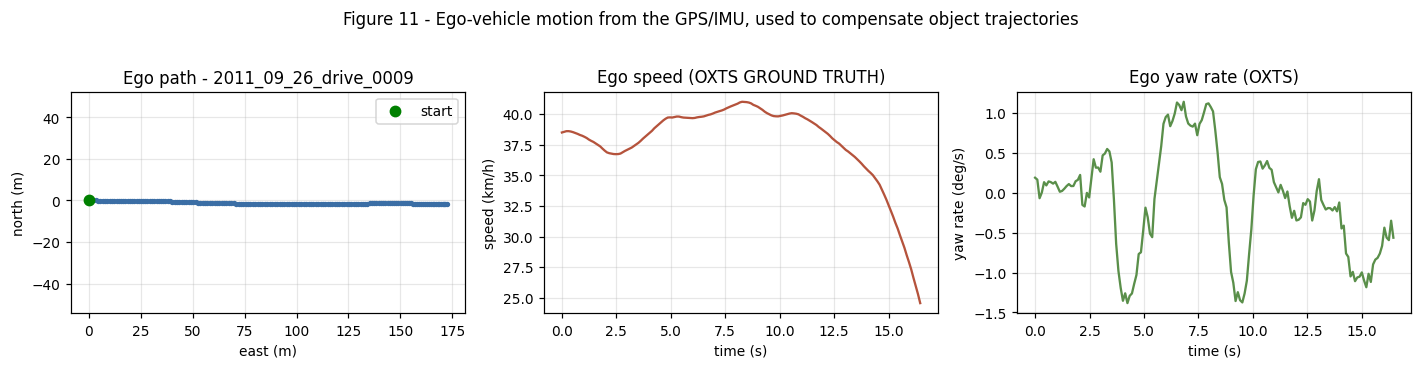

2011_09_26_drive_0009: ego travelled 172.5 m in 16.5 s (mean 37.7 km/h)
Any object appearing to move at roughly this speed in the CAMERA frame is in fact stationary.


In [17]:
# ---------------------------------------------------------------------------
# Section 17 - Ego-motion from OXTS GPS/IMU
# ---------------------------------------------------------------------------
EARTH_RADIUS = 6378137.0


def latlon_to_mercator(lat: float, lon: float, scale: float) -> Tuple[float, float]:
    """Local metric Mercator coordinates (east, north) in metres."""
    mx = scale * lon * math.pi * EARTH_RADIUS / 180.0
    my = scale * EARTH_RADIUS * math.log(math.tan((90.0 + lat) * math.pi / 360.0))
    return mx, my


def pose_from_oxts(packet: Dict[str, float], scale: float) -> np.ndarray:
    """OXTS packet -> 4x4 IMU pose in the local world frame."""
    mx, my = latlon_to_mercator(packet["lat"], packet["lon"], scale)
    t = np.array([mx, my, packet["alt"]])
    rx, ry, rz = packet["roll"], packet["pitch"], packet["yaw"]
    Rx = np.array([[1, 0, 0], [0, math.cos(rx), -math.sin(rx)], [0, math.sin(rx), math.cos(rx)]])
    Ry = np.array([[math.cos(ry), 0, math.sin(ry)], [0, 1, 0], [-math.sin(ry), 0, math.cos(ry)]])
    Rz = np.array([[math.cos(rz), -math.sin(rz), 0], [math.sin(rz), math.cos(rz), 0], [0, 0, 1]])
    return _rt_to_T(Rz @ Ry @ Rx, t)


def build_ego_poses(ds: KittiRawDrive, calib: KittiCalib) -> Optional[Dict[str, Any]]:
    """Per-frame camera poses in a world frame anchored at the drive's first frame."""
    if not ds.has_oxts:
        return None
    p0 = ds.load_oxts(ds.frames[0])
    if p0 is None:
        return None
    scale = math.cos(p0["lat"] * math.pi / 180.0)
    T_w_imu0 = pose_from_oxts(p0, scale)
    T_w_imu0_inv = np.linalg.inv(T_w_imu0)
    T_imu_cam2 = np.linalg.inv(calib.T_cam2_imu)   # cam2 -> imu

    poses: Dict[int, np.ndarray] = {}
    ego: Dict[int, Dict[str, float]] = {}
    for f in ds.frames:
        pk = ds.load_oxts(f)
        if pk is None:
            continue
        T_ref_imu = T_w_imu0_inv @ pose_from_oxts(pk, scale)
        poses[f] = T_ref_imu @ T_imu_cam2           # cam2 -> world(ref)
        ego[f] = {
            "ego_x": float(T_ref_imu[0, 3]), "ego_y": float(T_ref_imu[1, 3]),
            "ego_z": float(T_ref_imu[2, 3]),
            "ego_yaw": float(math.atan2(T_ref_imu[1, 0], T_ref_imu[0, 0])),
            "ego_speed_gt": float(math.hypot(pk["vf"], pk["vl"])),   # OXTS ground truth (m/s)
            "ego_vf": float(pk["vf"]), "ego_yawrate": float(pk["wz"]),
        }
    return {"poses": poses, "ego": ego, "scale": scale}


def cam_to_world(P_cam: np.ndarray, T_w_cam: np.ndarray) -> np.ndarray:
    """(3,) or (N,3) camera-frame points -> world frame."""
    P = np.atleast_2d(P_cam)
    Ph = np.concatenate([P, np.ones((len(P), 1))], axis=1)
    W = (T_w_cam @ Ph.T).T[:, :3]
    return W[0] if P_cam.ndim == 1 else W


EGO: Dict[str, Optional[Dict[str, Any]]] = {d: build_ego_poses(DRIVE_OBJ[d], CALIB) for d in DRIVES}
HAS_EGO = {d: EGO[d] is not None for d in DRIVES}
log(f"ego-motion available for {sum(HAS_EGO.values())}/{len(DRIVES)} drives")

# visualise the ego path and ground-truth speed for one drive
_d0 = next((d for d in DRIVES if HAS_EGO[d]), None)
if _d0:
    e = EGO[_d0]["ego"]
    fr = sorted(e)
    ts = [DRIVE_OBJ[_d0].time_of(f) for f in fr]
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
    ax[0].plot([e[f]["ego_x"] for f in fr], [e[f]["ego_y"] for f in fr], "-o", ms=2.5, color="#3b6ea5")
    ax[0].scatter([e[fr[0]]["ego_x"]], [e[fr[0]]["ego_y"]], c="green", s=45, zorder=5, label="start")
    ax[0].set_xlabel("east (m)"); ax[0].set_ylabel("north (m)"); ax[0].axis("equal")
    ax[0].set_title(f"Ego path - {_d0}"); ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(ts, [e[f]["ego_speed_gt"] * 3.6 for f in fr], color="#b5533c")
    ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("speed (km/h)")
    ax[1].set_title("Ego speed (OXTS GROUND TRUTH)"); ax[1].grid(alpha=0.3)
    ax[2].plot(ts, [np.degrees(e[f]["ego_yawrate"]) for f in fr], color="#5a8f4a")
    ax[2].set_xlabel("time (s)"); ax[2].set_ylabel("yaw rate (deg/s)")
    ax[2].set_title("Ego yaw rate (OXTS)"); ax[2].grid(alpha=0.3)
    plt.suptitle("Figure 11 - Ego-vehicle motion from the GPS/IMU, used to compensate object trajectories", y=1.03)
    plt.tight_layout(); plt.show()
    total = sum(math.dist((e[a]["ego_x"], e[a]["ego_y"]), (e[b]["ego_x"], e[b]["ego_y"]))
                for a, b in zip(fr[:-1], fr[1:]))
    print(f"{_d0}: ego travelled {total:.1f} m in {ts[-1] - ts[0]:.1f} s "
          f"(mean {3.6 * total / max(ts[-1] - ts[0], 1e-6):.1f} km/h)")
    print("Any object appearing to move at roughly this speed in the CAMERA frame is in fact stationary.")

## 18. The Per-Drive Pipeline

Everything above is now composed into one function, `process_drive()`, which walks a drive
frame by frame and produces a tidy table — one row per (frame, track):

```
drive frame t track_id cls score bbox u v disp Xc Yc Zc Xw Yw Zw ego_*
```

Design notes:

* **Memory.** Images, disparity and depth are released at the end of each frame; nothing
  accumulates except the small row dictionaries. This is what lets a long drive run inside
  Colab's RAM.
* **Caching.** The result is written to Drive keyed by a hash of the settings that affect it,
  so re-running the notebook re-uses the tables instead of re-detecting.
* **A smoke test runs first** on a handful of frames, with assertions on every invariant, so a
  broken component is caught in seconds rather than after twenty minutes of processing.

In [18]:
# ---------------------------------------------------------------------------
# Section 18a - The per-drive processing pipeline
# ---------------------------------------------------------------------------
import hashlib

TRACK_COLUMNS = ["drive", "split", "frame", "t", "track_id", "cls", "score",
                 "x1", "y1", "x2", "y2", "u", "v", "disp", "n_disp_px",
                 "Xc", "Yc", "Zc", "Xw", "Yw", "Zw",
                 "ego_x", "ego_y", "ego_yaw", "ego_speed_gt"]


def pipeline_signature() -> str:
    keys = ["detector_weights", "detector_conf", "detector_imgsz", "sgbm_num_disparities",
            "sgbm_block_size", "track_iou_threshold", "track_max_age", "track_min_hits",
            "min_valid_disp_pixels", "max_object_depth_m", "frame_stride"]
    payload = json.dumps({k: CONFIG[k] for k in keys}, sort_keys=True) + f"|{MAX_FRAMES}"
    return hashlib.md5(payload.encode()).hexdigest()[:10]


SIG = pipeline_signature()


def process_drive(drive: str, n_frames: Optional[int] = None, verbose: bool = True) -> pd.DataFrame:
    """Detection + tracking + stereo depth + 3D localisation + ego compensation for one drive."""
    ds = DRIVE_OBJ[drive]
    frames = ds.frames if n_frames is None else ds.frames[:n_frames]
    ego = EGO.get(drive)
    tracker = ByteTrackLite(CONFIG["track_iou_threshold"], CONFIG["track_max_age"], CONFIG["track_min_hits"])
    KalmanBoxTracker._next_id = 1          # ids restart per drive; (drive, track_id) is the key
    rows: List[Dict[str, Any]] = []
    t_start = time.time()

    for i, f in enumerate(frames):
        imgL, imgR = ds.load_stereo(f)
        disp, _ = STEREO.compute(imgL, imgR)
        tracks = tracker.update(DETECTOR.detect(imgL))
        T_w_cam = ego["poses"].get(f) if ego else None
        e = ego["ego"].get(f, {}) if ego else {}

        for tr in tracks:
            row: Dict[str, Any] = {
                "drive": drive, "split": SPLIT_OF_DRIVE.get(drive, "?"), "frame": f,
                "t": ds.time_of(f), "track_id": tr["track_id"], "cls": tr["cls"],
                "score": tr["score"],
                "x1": tr["bbox"][0], "y1": tr["bbox"][1], "x2": tr["bbox"][2], "y2": tr["bbox"][3],
                "ego_x": e.get("ego_x", np.nan), "ego_y": e.get("ego_y", np.nan),
                "ego_yaw": e.get("ego_yaw", np.nan), "ego_speed_gt": e.get("ego_speed_gt", np.nan),
            }
            loc = localize_box(tr["bbox"], disp, CALIB, CONFIG["min_valid_disp_pixels"],
                               CONFIG["max_object_depth_m"])
            if loc:
                row.update({k: loc[k] for k in ("u", "v", "disp", "n_disp_px", "Xc", "Yc", "Zc")})
                if T_w_cam is not None:
                    Xw, Yw, Zw = cam_to_world(np.array([loc["Xc"], loc["Yc"], loc["Zc"]]), T_w_cam)
                    row.update({"Xw": float(Xw), "Yw": float(Yw), "Zw": float(Zw)})
            rows.append(row)

        del imgL, imgR, disp
        if verbose and (i + 1) % 40 == 0:
            log(f"  {drive}: {i + 1}/{len(frames)} frames, {len(rows)} observations")

    df = pd.DataFrame(rows)
    for c in TRACK_COLUMNS:
        if c not in df.columns:
            df[c] = np.nan
    df = df[TRACK_COLUMNS]
    if verbose:
        log(f"{drive}: {len(frames)} frames in {time.time() - t_start:.1f}s -> "
            f"{len(df)} observations, {df['track_id'].nunique()} tracks, "
            f"{df['Zc'].notna().mean():.0%} with 3D position")
    return df

In [19]:
# ---------------------------------------------------------------------------
# Section 18b - SMOKE TEST: verify every component on a handful of frames
# ---------------------------------------------------------------------------
log("=== SMOKE TEST ===")
_sd = DRIVES[0]
_smoke = process_drive(_sd, n_frames=min(8, len(DRIVE_OBJ[_sd])), verbose=False)

checks: List[Tuple[str, bool, str]] = []
checks.append(("environment", True, f"{DEVICE} | torch {torch.__version__}"))
checks.append(("dataset access", len(DRIVE_OBJ[_sd]) > 0, f"{len(DRIVE_OBJ[_sd])} frames"))
checks.append(("calibration", 0.3 < BASELINE < 1.0, f"B={BASELINE:.3f} m, f={FX:.1f} px"))
checks.append(("stereo", METRICS.get("sgbm_valid_pixel_fraction", 0) > 0.1,
               f"{METRICS.get('sgbm_valid_pixel_fraction', 0):.1%} valid disparity"))
checks.append(("detection", len(_smoke) > 0, f"{len(_smoke)} detections in 8 frames"))
checks.append(("tracking", _smoke["track_id"].nunique() > 0, f"{_smoke['track_id'].nunique()} track ids"))
checks.append(("3D localisation", _smoke["Zc"].notna().sum() > 0,
               f"{_smoke['Zc'].notna().sum()} positions, "
               f"median Z={_smoke['Zc'].median():.1f} m" if _smoke["Zc"].notna().any() else "none"))
checks.append(("ego-motion", _smoke["Xw"].notna().sum() > 0 or not HAS_EGO.get(_sd, False),
               f"{_smoke['Xw'].notna().sum()} world positions"))
checks.append(("schema", list(_smoke.columns) == TRACK_COLUMNS, f"{len(_smoke.columns)} columns"))

for name, ok, info in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name:18s} {info}")

_hard = [n for n, ok, _ in checks if not ok and n in
         {"dataset access", "calibration", "stereo", "detection", "tracking", "schema"}]
assert not _hard, f"smoke test failed on required components: {_hard}"
if _smoke["Zc"].notna().any():
    assert _smoke["Zc"].dropna().between(0, CONFIG["max_object_depth_m"]).all(), "depth out of range"
    assert _smoke["disp"].dropna().gt(0).all(), "non-positive disparity leaked through"
log("=== SMOKE TEST PASSED - running the full pipeline ===")
del _smoke

[  546.8s][INFO] === SMOKE TEST ===
  [PASS] environment        cuda | torch 2.11.0+cu128
  [PASS] dataset access     160 frames
  [PASS] calibration        B=0.533 m, f=721.5 px
  [PASS] stereo             68.0% valid disparity
  [PASS] detection          48 detections in 8 frames
  [PASS] tracking           7 track ids
  [PASS] 3D localisation    41 positions, median Z=14.7 m
  [PASS] ego-motion         41 world positions
  [PASS] schema             25 columns
[  550.4s][INFO] === SMOKE TEST PASSED - running the full pipeline ===


In [20]:
# ---------------------------------------------------------------------------
# Section 18c - Full run over every drive (cached in Drive)
# ---------------------------------------------------------------------------
TRACK_TABLES: Dict[str, pd.DataFrame] = {}
for d in DRIVES:
    cache = CACHE_DIR / f"tracks_{d}_{SIG}.csv"
    if CONFIG["cache_dataset"] and cache.exists():
        TRACK_TABLES[d] = pd.read_csv(cache)
        log(f"{d}: loaded {len(TRACK_TABLES[d])} cached observations")
    else:
        TRACK_TABLES[d] = process_drive(d)
        if CONFIG["cache_dataset"]:
            TRACK_TABLES[d].to_csv(cache, index=False)

TRACKS_RAW = pd.concat(TRACK_TABLES.values(), ignore_index=True)
TRACKS_RAW["split"] = TRACKS_RAW["drive"].map(SPLIT_OF_DRIVE)
TRACKS_RAW = TRACKS_RAW[TRACKS_RAW["track_id"].notna()].reset_index(drop=True)
TRACKS_RAW["uid"] = TRACKS_RAW["drive"] + "#" + TRACKS_RAW["track_id"].astype(int).astype(str)
assert len(TRACKS_RAW) > 0, "no objects were detected in any drive - check the detector and the data"

print(f"\ntotal observations : {len(TRACKS_RAW):,}")
print(f"unique tracks      : {TRACKS_RAW['uid'].nunique():,}")
print(f"with 3D position   : {TRACKS_RAW['Zc'].notna().mean():.1%}")
print(f"with world position: {TRACKS_RAW['Xw'].notna().mean():.1%}")
display(TRACKS_RAW.groupby(["split", "drive"]).agg(
    observations=("uid", "size"), tracks=("uid", "nunique"),
    with_3d=("Zc", lambda s: round(float(s.notna().mean()), 3)),
    median_Z=("Zc", lambda s: round(float(s.median()), 1) if s.notna().any() else np.nan),
).reset_index())
print("\nclass distribution:")
print(TRACKS_RAW["cls"].value_counts().to_string())
METRICS["total_track_observations"] = int(len(TRACKS_RAW))
METRICS["unique_tracks"] = int(TRACKS_RAW["uid"].nunique())
METRICS["frac_observations_with_3d"] = round(float(TRACKS_RAW["Zc"].notna().mean()), 3)

[  572.6s][INFO]   2011_09_26_drive_0009: 40/160 frames, 326 observations
[  593.0s][INFO]   2011_09_26_drive_0009: 80/160 frames, 625 observations
[  615.1s][INFO]   2011_09_26_drive_0009: 120/160 frames, 1055 observations
[  635.4s][INFO]   2011_09_26_drive_0009: 160/160 frames, 1313 observations
[  635.4s][INFO] 2011_09_26_drive_0009: 160 frames in 85.0s -> 1313 observations, 76 tracks, 88% with 3D position
[  657.4s][INFO]   2011_09_26_drive_0011: 40/160 frames, 25 observations
[  677.2s][INFO]   2011_09_26_drive_0011: 80/160 frames, 117 observations
[  698.3s][INFO]   2011_09_26_drive_0011: 120/160 frames, 413 observations
[  719.2s][INFO]   2011_09_26_drive_0011: 160/160 frames, 726 observations
[  719.2s][INFO] 2011_09_26_drive_0011: 160 frames in 83.6s -> 726 observations, 29 tracks, 84% with 3D position
[  739.0s][INFO]   2011_09_26_drive_0018: 40/160 frames, 35 observations
[  761.4s][INFO]   2011_09_26_drive_0018: 80/160 frames, 184 observations
[  781.8s][INFO]   2011_09_26

,split,drive,observations,tracks,with_3d,median_Z
0,test,2011_09_26_drive_0013,366,15,0.852,27.6
1,test,2011_09_26_drive_0014,495,41,0.834,27.1
2,train,2011_09_26_drive_0009,1313,76,0.876,18.7
3,train,2011_09_26_drive_0011,726,29,0.839,29.6
4,train,2011_09_26_drive_0018,552,28,0.902,27.2
5,train,2011_09_26_drive_0057,885,22,0.913,29.4
6,val,2011_09_26_drive_0059,995,45,0.857,20.2



class distribution:
cls
Car           4737
Truck          284
Pedestrian     272
Cyclist         39


## 18 (cont). 3D Trajectory Construction & Filtering

A trajectory is one track's positions ordered in time:
$t_0\to(X_0,Y_0,Z_0),\;t_1\to(X_1,Y_1,Z_1),\dots$

Raw stereo positions are noisy — recall that a half-pixel disparity error is tens of
centimetres at 20 m — and differentiating noise amplifies it. Filtering is therefore
necessary, but over-filtering is a way of manufacturing good-looking results, so the choices
are constrained deliberately:

* **Short gaps only are interpolated** (up to 3 frames, 0.3 s). Longer gaps split the track;
  no long stretch of invented data is ever created.
* **Savitzky-Golay filter**, window 7 frames (0.7 s), polynomial order 2. Unlike a moving
  average, a Savitzky-Golay filter fits a low-order polynomial in a sliding window, so it
  suppresses high-frequency noise while preserving the *shape* of real accelerations. A plain
  moving average flattens genuine braking events, which would systematically bias the
  behaviour labels towards "cruising".
* **The window stays short.** 0.7 s cannot hide a real manoeuvre — vehicle dynamics at these
  speeds act on 1–3 s timescales.
* **Both raw and smoothed values are kept**, so the effect of filtering is visible rather than
  assumed.

A Kalman filter is already doing work upstream — in the tracker, on the *image-plane* box
state, where it enables occlusion handling. A second Kalman filter on the 3D position would be
the natural production choice; Savitzky-Golay is used here because it is non-recursive
(no tuned process-noise matrix quietly imposing a motion model on the output) and its
smoothing bandwidth is explicit.

tracks surviving the length/3D requirements: 165 (155 vehicles)
observations with world-frame kinematics    : 4,465


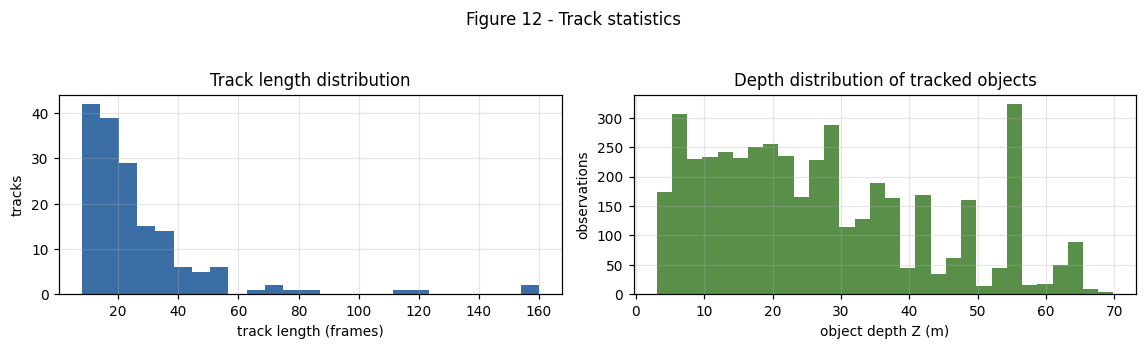

In [21]:
# ---------------------------------------------------------------------------
# Section 18d - Trajectory assembly, smoothing and kinematics
# ---------------------------------------------------------------------------
from scipy.signal import savgol_filter

SMOOTH_WIN, SMOOTH_POLY, MAX_GAP = 7, 2, 3


def _smooth(x: np.ndarray, win: int = SMOOTH_WIN, poly: int = SMOOTH_POLY) -> np.ndarray:
    """Savitzky-Golay with automatic window shrinking for short tracks."""
    n = len(x)
    if n < 5:
        return x.astype(float)
    w = min(win, n if n % 2 == 1 else n - 1)
    if w <= poly:
        return x.astype(float)
    return savgol_filter(x.astype(float), w, poly)


def build_kinematics(df: pd.DataFrame, min_len: int = 8) -> pd.DataFrame:
    """Per-track smoothing + velocity/acceleration/heading in BOTH frames.

    World frame  (Xw east, Yw north): true motion over the ground -> speed, behaviour, prediction.
    Camera frame (Xc right, Zc forward): motion relative to the ego-vehicle -> TTC.
    """
    out: List[pd.DataFrame] = []
    for uid, g in df.groupby("uid", sort=False):
        g = g.sort_values("frame").copy()
        if len(g) < min_len:
            continue
        # interpolate only short gaps in the 3D measurements
        for c in ["Xc", "Yc", "Zc", "Xw", "Yw", "Zw"]:
            g[c] = g[c].interpolate(limit=MAX_GAP, limit_area="inside")
        g = g[g[["Xc", "Zc"]].notna().all(axis=1)]
        if len(g) < min_len:
            continue
        # World coordinates need OXTS for every retained frame. Previously a SINGLE missing
        # frame voided the whole track's world kinematics; instead drop just those frames,
        # provided most of the track survives. np.gradient uses the real timestamps, so the
        # resulting non-uniform time grid is handled correctly.
        w_ok = g[["Xw", "Yw", "Zw"]].notna().all(axis=1)
        if w_ok.mean() >= 0.6:
            g = g[w_ok]
            if len(g) < min_len:
                continue
        t = g["t"].to_numpy(float)
        dt = np.gradient(t)
        if np.any(dt <= 0):
            continue

        # --- camera-relative (ego-centred) -----------------------------------
        Xc, Zc = _smooth(g["Xc"].to_numpy()), _smooth(g["Zc"].to_numpy())
        g["Xc_s"], g["Zc_s"] = Xc, Zc
        vXc, vZc = np.gradient(Xc, t), np.gradient(Zc, t)
        g["vXc"], g["vZc"] = vXc, vZc
        g["speed_rel"] = np.hypot(vXc, vZc)
        g["closing_rate"] = -vZc                      # >0 means approaching the ego-vehicle

        # --- world frame (ego-motion compensated) ----------------------------
        has_w = bool(g[["Xw", "Yw"]].notna().all(axis=1).all())
        if has_w:
            Xw, Yw = _smooth(g["Xw"].to_numpy()), _smooth(g["Yw"].to_numpy())
            Zw = _smooth(g["Zw"].to_numpy()) if g["Zw"].notna().all() else np.zeros(len(g))
            g["Xw_s"], g["Yw_s"], g["Zw_s"] = Xw, Yw, Zw
            vx, vy = np.gradient(Xw, t), np.gradient(Yw, t)
            speed = np.hypot(vx, vy)
            acc = np.gradient(_smooth(speed, 5, 2), t)
            g["vx"], g["vy"] = vx, vy
            g["speed"] = speed
            g["speed_kmh"] = speed * 3.6
            g["accel"] = acc
            g["jerk"] = np.gradient(_smooth(acc, 5, 2), t)
            heading = np.unwrap(np.arctan2(vy, vx))
            g["heading"] = heading
            g["heading_rate"] = np.gradient(_smooth(heading, 5, 2), t)
            # curvature kappa = |x'y'' - y'x''| / (x'^2+y'^2)^{3/2}
            ax_, ay_ = np.gradient(vx, t), np.gradient(vy, t)
            denom = np.power(vx ** 2 + vy ** 2, 1.5)
            g["curvature"] = np.where(denom > 1e-3, np.abs(vx * ay_ - vy * ax_) / np.maximum(denom, 1e-9), 0.0)
            # decompose into along-track / cross-track components
            ux, uy = np.cos(heading), np.sin(heading)
            g["v_long"] = vx * ux + vy * uy
            g["v_lat"] = -vx * uy + vy * ux
        else:
            for c in ["Xw_s", "Yw_s", "Zw_s", "vx", "vy", "speed", "speed_kmh", "accel",
                      "jerk", "heading", "heading_rate", "curvature", "v_long", "v_lat"]:
                g[c] = np.nan
        g["n_obs"] = len(g)
        out.append(g)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame(columns=df.columns)


TRACKS = build_kinematics(TRACKS_RAW, min_len=8)
DERIVED_COLS = ["Xc_s", "Zc_s", "vXc", "vZc", "speed_rel", "closing_rate",
                "Xw_s", "Yw_s", "Zw_s", "vx", "vy", "speed", "speed_kmh", "accel", "jerk",
                "heading", "heading_rate", "curvature", "v_long", "v_lat", "n_obs"]
for _c in DERIVED_COLS:
    if _c not in TRACKS.columns:
        TRACKS[_c] = np.nan
TRACKS["is_vehicle"] = TRACKS["cls"].isin(VEHICLE_CLASSES) if len(TRACKS) else pd.Series(dtype=bool)
assert len(TRACKS) > 0, ("no track survived the length/3D requirements - increase max_frames "
                         "or lower CONFIG['min_valid_disp_pixels']")
print(f"tracks surviving the length/3D requirements: {TRACKS['uid'].nunique()} "
      f"({TRACKS[TRACKS['is_vehicle']]['uid'].nunique()} vehicles)")
print(f"observations with world-frame kinematics    : {TRACKS['speed'].notna().sum():,}")

_len = TRACKS.groupby("uid").size()
plt.figure(figsize=(10.5, 3))
plt.subplot(1, 2, 1)
plt.hist(_len, bins=25, color="#3b6ea5"); plt.xlabel("track length (frames)"); plt.ylabel("tracks")
plt.title("Track length distribution"); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.hist(TRACKS["Zc"].dropna(), bins=30, color="#5a8f4a")
plt.xlabel("object depth Z (m)"); plt.ylabel("observations")
plt.title("Depth distribution of tracked objects"); plt.grid(alpha=0.3)
plt.suptitle("Figure 12 - Track statistics", y=1.04); plt.tight_layout(); plt.show()

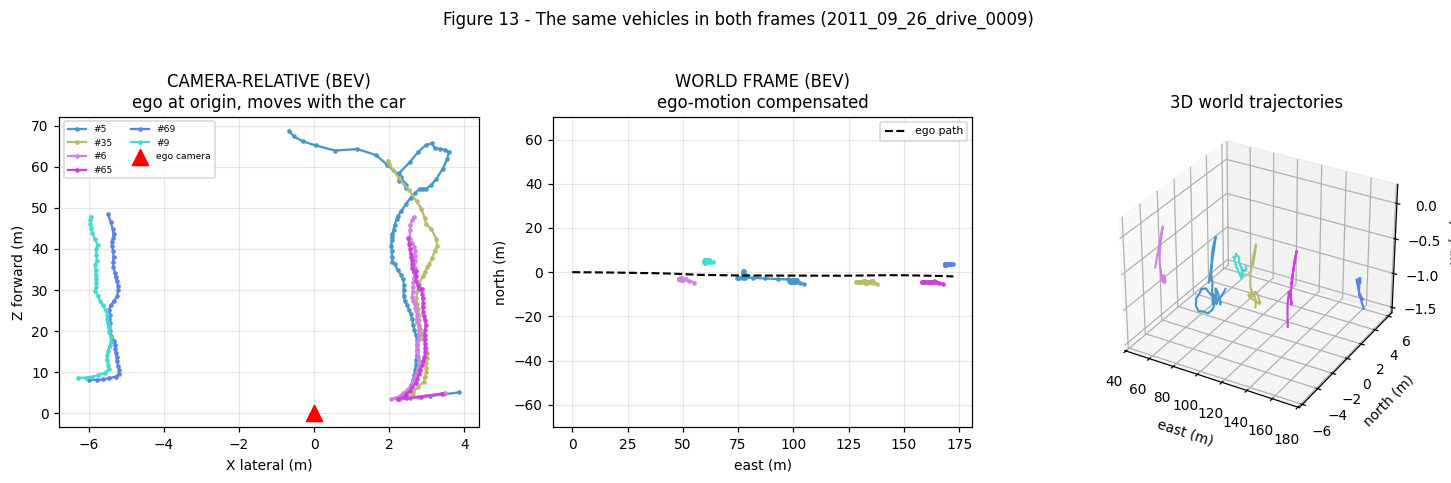

Left and centre are the SAME vehicles. In the camera frame parked cars sweep past the
ego-vehicle; in the world frame they sit still. That difference is ego-motion compensation.


In [22]:
# ---------------------------------------------------------------------------
# Section 18e - Trajectory visualisations (2D, 3D, bird's-eye)
# ---------------------------------------------------------------------------
def longest_tracks(df: pd.DataFrame, n: int = 8, vehicles_only: bool = True,
                   drive: Optional[str] = None, require_world: bool = True) -> List[str]:
    d = df[df["is_vehicle"]] if vehicles_only else df
    if drive:
        d = d[d["drive"] == drive]
    if require_world:
        d = d[d["speed"].notna()]
    if d.empty:
        return []
    return d.groupby("uid").size().sort_values(ascending=False).head(n).index.tolist()


VIZ_DRIVE = next((d for d in DRIVES if HAS_EGO.get(d) and (TRACKS["drive"] == d).any()), DRIVES[0])
top = longest_tracks(TRACKS, 6, drive=VIZ_DRIVE, require_world=HAS_EGO.get(VIZ_DRIVE, False))

if top:
    fig = plt.figure(figsize=(13.5, 4.2))
    ax1 = fig.add_subplot(1, 3, 1)
    ax2 = fig.add_subplot(1, 3, 2)
    ax3 = fig.add_subplot(1, 3, 3, projection="3d")
    for uid in top:
        g = TRACKS[TRACKS["uid"] == uid].sort_values("frame")
        c = np.array(color_for_id(int(uid.split("#")[1]))) / 255.0
        ax1.plot(g["Xc_s"], g["Zc_s"], "-o", ms=2, color=c, label=f"#{uid.split('#')[1]}")
        if g["Xw_s"].notna().all():
            ax2.plot(g["Xw_s"], g["Yw_s"], "-o", ms=2, color=c)
            ax3.plot(g["Xw_s"], g["Yw_s"], g["Zw_s"], color=c, lw=1.4)
    ax1.scatter([0], [0], marker="^", s=110, c="red", zorder=6, label="ego camera")
    ax1.set_xlabel("X lateral (m)"); ax1.set_ylabel("Z forward (m)")
    ax1.set_title("CAMERA-RELATIVE (BEV)\nego at origin, moves with the car"); ax1.grid(alpha=0.3)
    ax1.legend(fontsize=6, ncol=2)
    if HAS_EGO.get(VIZ_DRIVE):
        e = EGO[VIZ_DRIVE]["ego"]; fr = sorted(e)
        ax2.plot([e[f]["ego_x"] for f in fr], [e[f]["ego_y"] for f in fr], "k--", lw=1.4, label="ego path")
        ax2.legend(fontsize=7)
    ax2.set_xlabel("east (m)"); ax2.set_ylabel("north (m)")
    ax2.set_title("WORLD FRAME (BEV)\nego-motion compensated"); ax2.grid(alpha=0.3); ax2.axis("equal")
    ax3.set_xlabel("east (m)"); ax3.set_ylabel("north (m)"); ax3.set_zlabel("up (m)")
    ax3.set_title("3D world trajectories")
    plt.suptitle(f"Figure 13 - The same vehicles in both frames ({VIZ_DRIVE})", y=1.03)
    plt.tight_layout(); plt.show()
    print("Left and centre are the SAME vehicles. In the camera frame parked cars sweep past the")
    print("ego-vehicle; in the world frame they sit still. That difference is ego-motion compensation.")
else:
    log("no sufficiently long tracks to visualise", "WARN")

## 19–20. Speed and Acceleration Estimation

From consecutive 3D positions,

$$
v=\frac{\Delta s}{\Delta t},\qquad v_{km/h}=3.6\,v_{m/s},\qquad a=\frac{\Delta v}{\Delta t}
$$

with $\Delta t$ taken from the **actual KITTI timestamps** (≈0.103 s, not exactly 0.1 s) and
derivatives computed with a central difference (`np.gradient`), which is second-order accurate
and does not introduce the half-frame lag of a backward difference.

### Validating speed without per-vehicle ground truth

KITTI raw provides no ground-truth speed for *other* vehicles. Inventing one is not an option.
But there is a rigorous consistency test available:

> For an object that is **stationary in the world frame**, its measured
> **camera-relative** speed must equal the **OXTS ground-truth ego speed**.

Parked cars are abundant in KITTI city drives. Selecting tracks whose world-frame speed stays
below 0.6 m/s (i.e. the pipeline says they are parked) and comparing their camera-relative
speed against the GPS/IMU velocity gives a genuine, ground-truth-anchored error measurement of
the whole chain: disparity → depth → 3D position → differentiation.

This validates the *measurement* pipeline on static objects. It does not directly measure
error on moving vehicles, which have an additional error source (their own tracking noise), so
the numbers below should be read as a **lower bound** on moving-vehicle speed error. That
limitation is stated rather than papered over.

Speed validation on STATIC objects (ground truth = OXTS ego velocity):
  n_observations              : 88.000
  n_static_tracks             : 4.000
  MAE_mps                     : 1.350
  RMSE_mps                    : 2.570
  bias_mps                    : -0.920
  MAE_kmh                     : 4.859
  mean_ego_speed_mps          : 9.014
  rel_error_pct               : 14.974
  naive_world_speed_error_mps : 1.560

  Ego-motion compensation reduces the apparent speed of these parked vehicles
  from 32.5 km/h (uncompensated) to 5.6 km/h (compensated, true value 0).


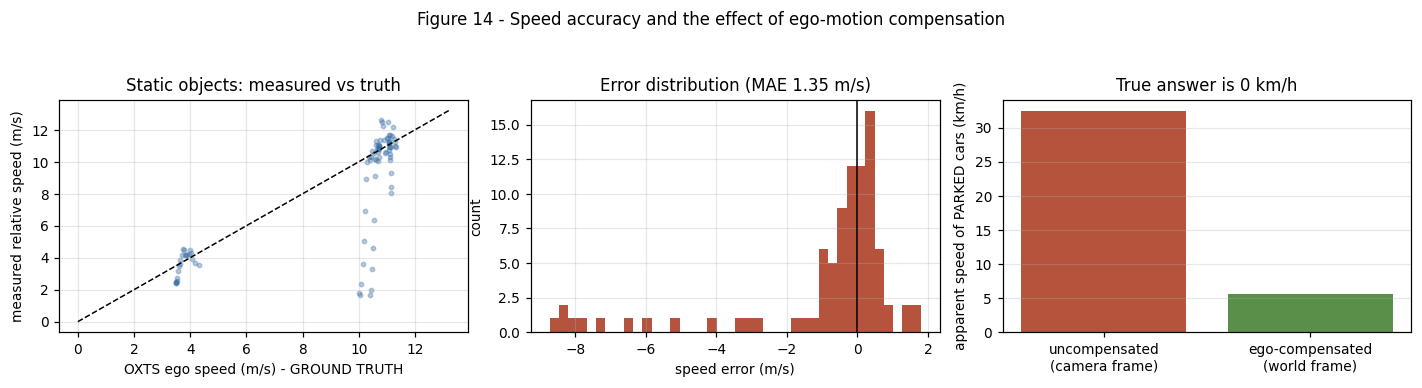

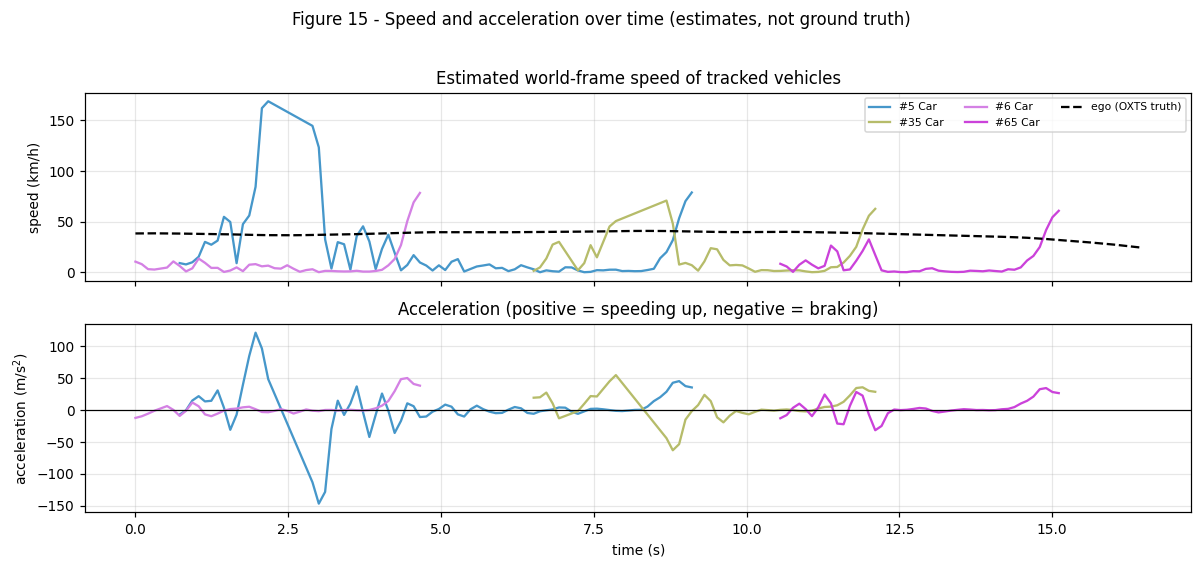

In [23]:
# ---------------------------------------------------------------------------
# Sections 19-20 - Speed / acceleration, and validation against OXTS ground truth
# ---------------------------------------------------------------------------
SPEED_EVAL: Dict[str, Any] = {}
kin = TRACKS[TRACKS["speed"].notna() & TRACKS["is_vehicle"]]

if len(kin) > 50:
    tstat = kin.groupby("uid").agg(world_speed=("speed", "median"), n=("speed", "size"),
                                   drive=("drive", "first"))
    static_uids = tstat[(tstat["world_speed"] < CONFIG["beh_stopped_speed"]) & (tstat["n"] >= 10)].index
    st = kin[kin["uid"].isin(static_uids) & kin["ego_speed_gt"].notna()]
    st = st[st["ego_speed_gt"] > 1.0]        # only while the ego-vehicle is actually moving
    if len(st) >= 30:
        err = st["speed_rel"].to_numpy() - st["ego_speed_gt"].to_numpy()
        SPEED_EVAL = {
            "n_observations": int(len(st)), "n_static_tracks": int(st["uid"].nunique()),
            "MAE_mps": float(np.abs(err).mean()), "RMSE_mps": float(np.sqrt((err ** 2).mean())),
            "bias_mps": float(err.mean()),
            "MAE_kmh": float(np.abs(err).mean() * 3.6),
            "mean_ego_speed_mps": float(st["ego_speed_gt"].mean()),
            "rel_error_pct": float(100 * np.abs(err).mean() / max(st["ego_speed_gt"].mean(), 1e-6)),
            "naive_world_speed_error_mps": float(st["speed"].abs().mean()),
        }
        METRICS["speed_MAE_mps"] = round(SPEED_EVAL["MAE_mps"], 3)
        METRICS["speed_RMSE_mps"] = round(SPEED_EVAL["RMSE_mps"], 3)
        METRICS["speed_MAE_kmh"] = round(SPEED_EVAL["MAE_kmh"], 2)
        print("Speed validation on STATIC objects (ground truth = OXTS ego velocity):")
        for k, v in SPEED_EVAL.items():
            print(f"  {k:28s}: {v:.3f}")
        print(f"\n  Ego-motion compensation reduces the apparent speed of these parked vehicles")
        print(f"  from {SPEED_EVAL['mean_ego_speed_mps'] * 3.6:.1f} km/h (uncompensated) to "
              f"{SPEED_EVAL['naive_world_speed_error_mps'] * 3.6:.1f} km/h (compensated, true value 0).")
        METRICS["egomotion_apparent_speed_before_kmh"] = round(SPEED_EVAL["mean_ego_speed_mps"] * 3.6, 2)
        METRICS["egomotion_apparent_speed_after_kmh"] = round(SPEED_EVAL["naive_world_speed_error_mps"] * 3.6, 2)

        fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))
        ax[0].scatter(st["ego_speed_gt"], st["speed_rel"], s=8, alpha=0.35, color="#3b6ea5")
        lim = [0, max(st["ego_speed_gt"].max(), st["speed_rel"].max()) * 1.05]
        ax[0].plot(lim, lim, "k--", lw=1)
        ax[0].set_xlabel("OXTS ego speed (m/s) - GROUND TRUTH")
        ax[0].set_ylabel("measured relative speed (m/s)")
        ax[0].set_title("Static objects: measured vs truth"); ax[0].grid(alpha=0.3)
        ax[1].hist(err, bins=40, color="#b5533c"); ax[1].axvline(0, color="k", lw=1)
        ax[1].set_xlabel("speed error (m/s)"); ax[1].set_ylabel("count")
        ax[1].set_title(f"Error distribution (MAE {SPEED_EVAL['MAE_mps']:.2f} m/s)"); ax[1].grid(alpha=0.3)
        ax[2].bar(["uncompensated\n(camera frame)", "ego-compensated\n(world frame)"],
                  [SPEED_EVAL["mean_ego_speed_mps"] * 3.6, SPEED_EVAL["naive_world_speed_error_mps"] * 3.6],
                  color=["#b5533c", "#5a8f4a"])
        ax[2].set_ylabel("apparent speed of PARKED cars (km/h)")
        ax[2].set_title("True answer is 0 km/h"); ax[2].grid(alpha=0.3, axis="y")
        plt.suptitle("Figure 14 - Speed accuracy and the effect of ego-motion compensation", y=1.05)
        plt.tight_layout(); plt.show()
    else:
        log("too few static-object observations for speed validation", "WARN")
        NOTES["speed_eval"] = "NOT AVAILABLE - insufficient static tracks with OXTS coverage"
else:
    NOTES["speed_eval"] = "NOT AVAILABLE - no world-frame kinematics (OXTS missing)"
    print("Speed validation:", NOTES["speed_eval"])

# --- speed / acceleration profiles of individual vehicles --------------------
prof = longest_tracks(TRACKS, 4, drive=VIZ_DRIVE, require_world=True)
if prof:
    fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    for uid in prof:
        g = TRACKS[TRACKS["uid"] == uid].sort_values("t")
        c = np.array(color_for_id(int(uid.split("#")[1]))) / 255.0
        ax[0].plot(g["t"], g["speed_kmh"], color=c, lw=1.5, label=f"#{uid.split('#')[1]} {g['cls'].iloc[0]}")
        ax[1].plot(g["t"], g["accel"], color=c, lw=1.5)
    if HAS_EGO.get(VIZ_DRIVE):
        e = EGO[VIZ_DRIVE]["ego"]; fr = sorted(e)
        ax[0].plot([DRIVE_OBJ[VIZ_DRIVE].time_of(f) for f in fr],
                   [e[f]["ego_speed_gt"] * 3.6 for f in fr], "k--", lw=1.5, label="ego (OXTS truth)")
    ax[0].set_ylabel("speed (km/h)"); ax[0].legend(fontsize=7, ncol=3); ax[0].grid(alpha=0.3)
    ax[0].set_title("Estimated world-frame speed of tracked vehicles")
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].set_ylabel("acceleration (m/s$^2$)"); ax[1].set_xlabel("time (s)"); ax[1].grid(alpha=0.3)
    ax[1].set_title("Acceleration (positive = speeding up, negative = braking)")
    plt.suptitle("Figure 15 - Speed and acceleration over time (estimates, not ground truth)", y=1.02)
    plt.tight_layout(); plt.show()

## 21. Time-to-Collision

$$
TTC=\frac{d}{v_{\text{closing}}}
$$

with $d$ the longitudinal separation and $v_{\text{closing}}$ the rate at which it shrinks.
This is one of the few places where the **camera-relative** frame is the correct one: what
matters for a collision is motion relative to the ego-vehicle, which is exactly what
$Z_c$ and $\dot Z_c$ encode.

**TTC is not computed for every object.** A blind $Z/\dot Z$ for all pairs produces nonsense —
oncoming traffic in the opposite lane, parked cars beside the road, and objects whose depth
noise happens to tick downwards all yield alarming numbers. Gating conditions:

1. **Positive closing rate** above `ttc_min_closing_mps` (0.7 m/s) — the gap must genuinely be
   shrinking by more than the measurement noise.
2. **Lateral alignment**: $|X_c| <$ 4 m — roughly the ego-vehicle's lane plus its neighbours.
   An object in the next street over is not on a collision course.
3. **Valid, in-range depth**: $0 < Z_c <$ 60 m, with an actual stereo measurement.
4. **Sustained over ≥ 3 consecutive frames**, so a single noisy depth cannot trigger it.

**What this is not.** A constant-closing-rate extrapolation from a single monocular-baseline
stereo rig, with no lane geometry, no intent model and no sensor redundancy. It is an
**estimated perception metric** useful for ranking which object deserves attention. It is not
a safety-certified collision-prediction system and must not be used as one.

TTC computed for 844 of 4,465 observations (18.9%) - the gating rejects the rest by design.
  TTC range: 0.1 - 29.3 s (median 1.9 s)
  observations below 4 s: 708


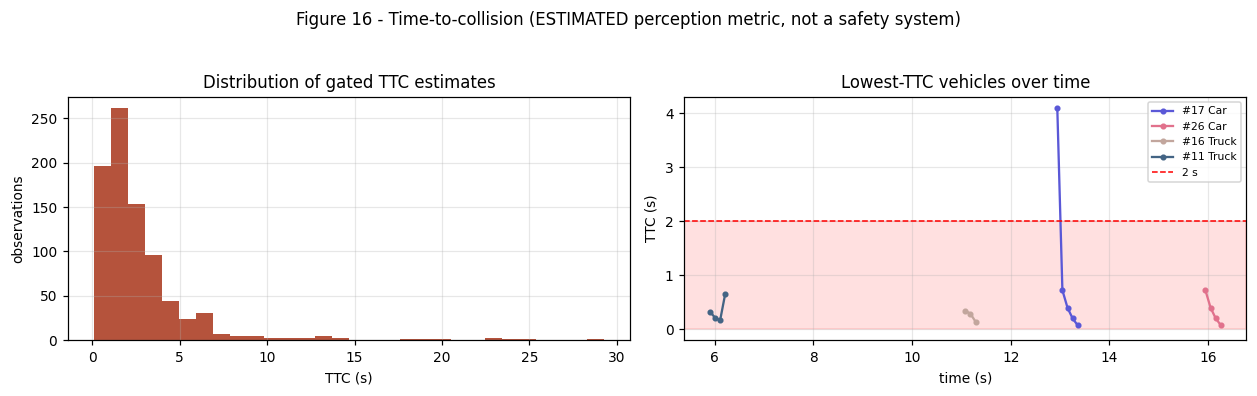


Worked example - 2011_09_26_drive_0057#17 at t=13.36s: Z=4.2 m, closing rate=59.52 m/s -> TTC = 4.2/59.52 = 0.07 s


In [24]:
# ---------------------------------------------------------------------------
# Section 21 - Time-to-collision (gated, camera-relative)
# ---------------------------------------------------------------------------
def compute_ttc(df: pd.DataFrame, cfg: Dict[str, Any], min_consecutive: int = 3) -> pd.DataFrame:
    """Gated TTC per observation. Returns the input with ttc / ttc_valid columns added."""
    d = df.copy()
    ok_depth = d["Zc_s"].between(0.5, cfg["ttc_max_range_m"])
    ok_lat = d["Xc_s"].abs() < cfg["ttc_max_lateral_m"]
    ok_close = d["closing_rate"] > cfg["ttc_min_closing_mps"]
    gate = ok_depth & ok_lat & ok_close
    d["ttc"] = np.where(gate, d["Zc_s"] / d["closing_rate"].replace(0, np.nan), np.nan)
    d["ttc"] = d["ttc"].where(d["ttc"].between(0, 30))
    # require the condition to persist for min_consecutive frames
    keep = np.zeros(len(d), bool)
    for _, g in d.groupby("uid", sort=False):
        v = g["ttc"].notna().to_numpy()
        run = np.zeros(len(v), int)
        c = 0
        for i, x in enumerate(v):
            c = c + 1 if x else 0
            run[i] = c
        idx = g.index.to_numpy()
        for i in range(len(v)):
            if run[i] >= min_consecutive:
                keep[d.index.get_indexer(idx[max(0, i - min_consecutive + 1): i + 1])] = True
    d["ttc_valid"] = d["ttc"].notna() & keep
    d.loc[~d["ttc_valid"], "ttc"] = np.nan
    return d


TRACKS = compute_ttc(TRACKS, CONFIG)
n_ttc = int(TRACKS["ttc_valid"].sum())
print(f"TTC computed for {n_ttc:,} of {len(TRACKS):,} observations "
      f"({n_ttc / max(len(TRACKS), 1):.1%}) - the gating rejects the rest by design.")
METRICS["ttc_observations"] = n_ttc

if n_ttc > 0:
    tt = TRACKS[TRACKS["ttc_valid"]]
    print(f"  TTC range: {tt['ttc'].min():.1f} - {tt['ttc'].max():.1f} s (median {tt['ttc'].median():.1f} s)")
    print(f"  observations below 4 s: {(tt['ttc'] < 4).sum()}")
    fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.4))
    ax[0].hist(tt["ttc"], bins=30, color="#b5533c")
    ax[0].set_xlabel("TTC (s)"); ax[0].set_ylabel("observations")
    ax[0].set_title("Distribution of gated TTC estimates"); ax[0].grid(alpha=0.3)
    crit = tt.groupby("uid")["ttc"].min().sort_values().head(4).index
    for uid in crit:
        g = TRACKS[(TRACKS["uid"] == uid)].sort_values("t")
        c = np.array(color_for_id(int(uid.split("#")[1]))) / 255.0
        ax[1].plot(g["t"], g["ttc"], "-o", ms=3, color=c, label=f"#{uid.split('#')[1]} {g['cls'].iloc[0]}")
    ax[1].axhspan(0, 2, color="red", alpha=0.12)
    ax[1].axhline(2, color="red", ls="--", lw=1, label="2 s")
    ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("TTC (s)")
    ax[1].set_title("Lowest-TTC vehicles over time"); ax[1].legend(fontsize=7); ax[1].grid(alpha=0.3)
    plt.suptitle("Figure 16 - Time-to-collision (ESTIMATED perception metric, not a safety system)", y=1.04)
    plt.tight_layout(); plt.show()

    ex = tt.sort_values("ttc").iloc[0]
    print(f"\nWorked example - {ex['uid']} at t={ex['t']:.2f}s: "
          f"Z={ex['Zc_s']:.1f} m, closing rate={ex['closing_rate']:.2f} m/s "
          f"-> TTC = {ex['Zc_s']:.1f}/{ex['closing_rate']:.2f} = {ex['ttc']:.2f} s")
else:
    print("No object met the TTC gating conditions in this run (common on short debug clips).")

## 22. Vehicle Behaviour Classification

### These are derived labels, not annotations — read this before the metrics

KITTI does not annotate driving behaviour. The classes below are computed from the
ego-compensated kinematics with the thresholds in `CONFIG`, applied in this priority order:

| Class | Rule (world frame, smoothed) |
|---|---|
| `stopped` | speed < 0.6 m/s |
| `turning` | \|heading rate\| > 10 °/s **and** speed > 1.5 m/s |
| `braking` | acceleration < −0.8 m/s² |
| `accelerating` | acceleration > +0.8 m/s² |
| `cruising` | none of the above |

They are **pseudo-labels derived from the model's own measurements**, so this task is
partially circular: a classifier given speed and acceleration could in principle re-derive the
thresholds. Two things are done so the experiment still says something real:

1. **Labels are non-causal, features are causal.** The label at time $t$ uses a *centred*
   window (past and future), while the classifier sees only the preceding 10 frames of *raw,
   unsmoothed* features. So the model must anticipate a state defined partly by the future
   from noisy history — a genuine prediction problem, not a lookup.
2. **Evaluation is on held-out drives**, never on frames from a training drive.

What this measures honestly: whether short windows of noisy stereo-derived motion features are
*sufficiently informative* to recover a kinematic state, end-to-end through the whole
perception chain. What it does not measure: agreement with human judgements of driving
behaviour, which would need annotations that do not exist for this dataset.

behaviour windows: 2801  (shape (2801, 10, 13))
label distribution (DERIVED pseudo-labels):
turning         1163
accelerating     539
stopped          539
braking          368
cruising         192


,model,accuracy,macro_precision,macro_recall,macro_F1
1,Random forest,0.6577,0.5494,0.5818,0.5450
2,GRU (temporal),0.5599,0.4237,0.3963,0.3802
0,Logistic regression (baseline),0.1932,0.0894,0.1217,0.0781



train windows 1892 (drives ['2011_09_26_drive_0009', '2011_09_26_drive_0011', '2011_09_26_drive_0018', '2011_09_26_drive_0057']), test windows 409 (drives ['2011_09_26_drive_0013', '2011_09_26_drive_0014'])
Labels are DERIVED from kinematic thresholds, not human annotations.
              precision    recall  f1-score   support

accelerating       0.62      0.62      0.62       112
     braking       1.00      0.70      0.82        94
    cruising       0.00      0.00      0.00        70
     turning       0.58      1.00      0.73       133

    accuracy                           0.66       409
   macro avg       0.55      0.58      0.55       409
weighted avg       0.59      0.66      0.60       409



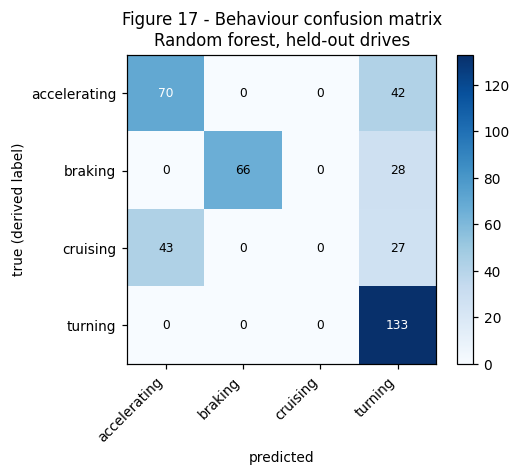

In [25]:
# ---------------------------------------------------------------------------
# Section 22 - Behaviour classification from derived (pseudo) labels
# ---------------------------------------------------------------------------
BEHAVIOURS = ["stopped", "turning", "braking", "accelerating", "cruising"]


def derive_behaviour_labels(df: pd.DataFrame, cfg: Dict[str, Any]) -> pd.DataFrame:
    """Apply the documented kinematic rules. DERIVED PSEUDO-LABELS, not annotations."""
    d = df.copy()
    lab = pd.Series("cruising", index=d.index, dtype=object)
    sp, ac = d["speed"], d["accel"]
    hr = np.degrees(d["heading_rate"].abs())
    lab[ac > cfg["beh_accel_thresh"]] = "accelerating"
    lab[ac < -cfg["beh_accel_thresh"]] = "braking"
    lab[(hr > cfg["beh_turn_rate_deg"]) & (sp > cfg["beh_turn_min_speed"])] = "turning"
    lab[sp < cfg["beh_stopped_speed"]] = "stopped"
    d["behaviour"] = np.where(sp.notna() & ac.notna(), lab, None)
    return d


TRACKS = derive_behaviour_labels(TRACKS, CONFIG)
BEH_FEATURES = ["speed_rel", "closing_rate", "Zc_s", "Xc_s", "vXc", "vZc",
                "speed", "accel", "jerk", "v_long", "v_lat", "heading_rate", "curvature"]
BEH_OBS = CONFIG["obs_len"]


def build_behaviour_windows(df: pd.DataFrame, obs: int = BEH_OBS
                            ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Causal windows of raw features -> label at the last timestep. Returns X, y, split, uid."""
    Xs, ys, sp, ui = [], [], [], []
    for uid, g in df[df["is_vehicle"]].groupby("uid", sort=False):
        g = g.sort_values("frame")
        if len(g) < obs or g["behaviour"].isna().all():
            continue
        F = g[BEH_FEATURES].to_numpy(np.float32)
        if not np.isfinite(F).all():
            continue
        labs = g["behaviour"].to_numpy()
        for i in range(obs, len(g) + 1):
            lab = labs[i - 1]
            if lab is None or (isinstance(lab, float) and not np.isfinite(lab)):
                continue
            Xs.append(F[i - obs:i]); ys.append(lab)
            sp.append(g["split"].iloc[0]); ui.append(uid)
    if not Xs:
        return (np.zeros((0, obs, len(BEH_FEATURES)), np.float32), np.array([]),
                np.array([]), np.array([]))
    return np.stack(Xs), np.array(ys), np.array(sp), np.array(ui)


BEH_RESULTS: Dict[str, Any] = {}
Xb, yb, sb, ub = build_behaviour_windows(TRACKS)
print(f"behaviour windows: {len(Xb)}  (shape {Xb.shape})")
if len(Xb):
    print("label distribution (DERIVED pseudo-labels):")
    print(pd.Series(yb).value_counts().to_string())

if len(Xb) >= 60 and HAS_SUPERVISED_SPLIT and len({*sb}) >= 2:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score,
                                 precision_score, recall_score)
    from sklearn.preprocessing import StandardScaler

    tr_m, va_m, te_m = sb == "train", sb == "val", sb == "test"
    if te_m.sum() < 10:
        log("test split has too few behaviour windows; merging val into test is NOT done - reporting on val", "WARN")
    Xtr_f, Xte_f = Xb[tr_m].reshape(tr_m.sum(), -1), Xb[te_m].reshape(te_m.sum(), -1)
    scaler_b = StandardScaler().fit(Xtr_f)          # fit on TRAIN only
    Xtr_s, Xte_s = scaler_b.transform(Xtr_f), scaler_b.transform(Xte_f)
    ytr, yte = yb[tr_m], yb[te_m]

    if len(Xtr_s) >= 30 and len(Xte_s) >= 10 and len(set(ytr)) >= 2:
        models = {
            "Logistic regression (baseline)": LogisticRegression(max_iter=800, multi_class="auto",
                                                                 class_weight="balanced", random_state=SEED),
            "Random forest": RandomForestClassifier(n_estimators=250, min_samples_leaf=2,
                                                    class_weight="balanced_subsample",
                                                    random_state=SEED, n_jobs=-1),
        }
        rows = []
        preds = {}
        for name, m in models.items():
            m.fit(Xtr_s, ytr)
            p = m.predict(Xte_s)
            preds[name] = p
            rows.append({"model": name, "accuracy": accuracy_score(yte, p),
                         "macro_precision": precision_score(yte, p, average="macro", zero_division=0),
                         "macro_recall": recall_score(yte, p, average="macro", zero_division=0),
                         "macro_F1": f1_score(yte, p, average="macro", zero_division=0)})

        # stronger temporal model: small GRU over the raw sequence
        try:
            import torch.nn as nn
            classes = sorted(set(ytr) | set(yte))
            c2i = {c: i for i, c in enumerate(classes)}
            mu = Xb[tr_m].reshape(-1, len(BEH_FEATURES)).mean(0)
            sd = Xb[tr_m].reshape(-1, len(BEH_FEATURES)).std(0) + 1e-6

            def prep(X): return torch.tensor((X - mu) / sd, dtype=torch.float32)

            class BehGRU(nn.Module):
                def __init__(self, nf, nc, h=64):
                    super().__init__()
                    self.gru = nn.GRU(nf, h, batch_first=True)
                    self.head = nn.Sequential(nn.Linear(h, 48), nn.ReLU(), nn.Dropout(0.2), nn.Linear(48, nc))

                def forward(self, x):
                    return self.head(self.gru(x)[0][:, -1])

            set_seed(SEED)
            gm = BehGRU(len(BEH_FEATURES), len(classes)).to(DEVICE)
            opt = torch.optim.Adam(gm.parameters(), lr=2e-3)
            cnt = pd.Series(ytr).value_counts()
            wt = torch.tensor([len(ytr) / (len(classes) * cnt.get(c, 1)) for c in classes],
                              dtype=torch.float32, device=DEVICE)
            lossf = torch.nn.CrossEntropyLoss(weight=wt)
            Xt = prep(Xb[tr_m]).to(DEVICE)
            yt = torch.tensor([c2i[c] for c in ytr], device=DEVICE)
            n_ep = 15 if DEBUG_MODE else 60
            gm.train()
            for ep in range(n_ep):
                perm = torch.randperm(len(Xt), device=DEVICE)
                for i in range(0, len(Xt), 64):
                    idx = perm[i:i + 64]
                    opt.zero_grad()
                    loss = lossf(gm(Xt[idx]), yt[idx])
                    loss.backward(); opt.step()
            gm.eval()
            with torch.no_grad():
                pg = gm(prep(Xb[te_m]).to(DEVICE)).argmax(1).cpu().numpy()
            p = np.array([classes[i] for i in pg])
            preds["GRU (temporal)"] = p
            rows.append({"model": "GRU (temporal)", "accuracy": accuracy_score(yte, p),
                         "macro_precision": precision_score(yte, p, average="macro", zero_division=0),
                         "macro_recall": recall_score(yte, p, average="macro", zero_division=0),
                         "macro_F1": f1_score(yte, p, average="macro", zero_division=0)})
        except Exception as e:
            log(f"behaviour GRU skipped: {type(e).__name__}: {e}", "WARN")

        BEH_DF = pd.DataFrame(rows).round(4).sort_values("macro_F1", ascending=False)
        display(BEH_DF)
        best = BEH_DF.iloc[0]["model"]
        BEH_RESULTS = {"table": BEH_DF, "best": best, "y_true": yte, "y_pred": preds[best],
                       "n_train": int(tr_m.sum()), "n_test": int(te_m.sum())}
        METRICS["behaviour_macro_F1"] = round(float(BEH_DF["macro_F1"].max()), 3)
        METRICS["behaviour_accuracy"] = round(float(BEH_DF.iloc[0]["accuracy"]), 3)
        METRICS["behaviour_best_model"] = best
        print(f"\ntrain windows {tr_m.sum()} (drives {sorted(set(TRACKS[TRACKS['split']=='train']['drive']))}), "
              f"test windows {te_m.sum()} (drives {sorted(set(TRACKS[TRACKS['split']=='test']['drive']))})")
        print("Labels are DERIVED from kinematic thresholds, not human annotations.")
        print(classification_report(yte, preds[best], zero_division=0))

        labs = sorted(set(yte) | set(preds[best]))
        cm = confusion_matrix(yte, preds[best], labels=labs)
        fig, ax = plt.subplots(figsize=(5.2, 4.4))
        im = ax.imshow(cm, cmap="Blues")
        ax.set_xticks(range(len(labs)), labs, rotation=45, ha="right")
        ax.set_yticks(range(len(labs)), labs)
        for i in range(len(labs)):
            for j in range(len(labs)):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
        ax.set_xlabel("predicted"); ax.set_ylabel("true (derived label)")
        ax.set_title(f"Figure 17 - Behaviour confusion matrix\n{best}, held-out drives")
        plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()
    else:
        NOTES["behaviour"] = "NOT AVAILABLE - too few windows after the sequence-level split"
        print("Behaviour classification:", NOTES["behaviour"])
else:
    NOTES["behaviour"] = ("NOT AVAILABLE - insufficient world-frame kinematics or splits "
                          "(needs OXTS + train/test drives)")
    print("Behaviour classification:", NOTES["behaviour"])

## 23. Trajectory Dataset Construction

The primary ML task: **given 1 s of a vehicle's past, predict its next 1 s.**

At KITTI's 10 Hz, that is 10 observed steps → 10 predicted steps.

### Agent-centric normalisation

Raw world coordinates are metres from wherever the recording started — a model trained on
them would memorise map locations instead of learning motion. Every window is therefore
transformed into an **agent-centric frame**:

* Translate so the **last observed position is the origin**.
* Rotate so the vehicle's **heading at that instant points along +x**.

Now "keep going straight" is the same vector for a car in the north lane and a car heading
south, and the model learns manoeuvres rather than geography. Rotations are orthonormal, so
displacement errors measured in this frame are identical to errors in metres on the ground —
no metric distortion is introduced.

### Features per observed timestep

`x, y, z` (agent-centric), `vx, vy` (rotated), `speed`, `accel`, `heading_rate`, `curvature`.

### Target

The next 10 positions in the same agent-centric frame, as 3D displacements.

Windows slide with stride 1, and — critically — **a window never crosses a track boundary or a
split boundary**, because it is built inside one track, which belongs to exactly one drive,
which belongs to exactly one split.

In [26]:
# ---------------------------------------------------------------------------
# Section 23 - Trajectory windows in an agent-centric frame
# ---------------------------------------------------------------------------
TRAJ_FEATURES = ["x", "y", "z", "vx", "vy", "speed", "accel", "heading_rate", "curvature"]
OBS_LEN, PRED_LEN = CONFIG["obs_len"], CONFIG["pred_len"]


def build_trajectory_windows(df: pd.DataFrame, obs: int = OBS_LEN, pred: int = PRED_LEN
                             ) -> Dict[str, np.ndarray]:
    """Sliding windows of (past features -> future displacements), agent-centric."""
    X, Y, meta_split, meta_cls, meta_uid, meta_drive, V0, DT = [], [], [], [], [], [], [], []
    need = ["Xw_s", "Yw_s", "Zw_s", "vx", "vy", "speed", "accel", "heading", "heading_rate", "curvature"]
    for uid, g in df[df["is_vehicle"]].groupby("uid", sort=False):
        g = g.sort_values("frame")
        if len(g) < obs + pred or g[need].isna().all().any():
            continue   # per-window finiteness is checked below, so keep partially-valid tracks
        P = g[["Xw_s", "Yw_s", "Zw_s"]].to_numpy(np.float64)
        Vw = g[["vx", "vy"]].to_numpy(np.float64)
        sp = g["speed"].to_numpy(); ac = g["accel"].to_numpy()
        hd = g["heading"].to_numpy(); hr = g["heading_rate"].to_numpy(); cu = g["curvature"].to_numpy()
        tt = g["t"].to_numpy(np.float64)
        for i in range(obs, len(g) - pred + 1):
            o = P[i - 1]                                  # last observed position = origin
            th = hd[i - 1]                                # heading at that instant
            c, s = math.cos(-th), math.sin(-th)
            R = np.array([[c, -s], [s, c]])               # world -> agent-centric (rotate by -theta)
            past_xy = (R @ (P[i - obs:i, :2] - o[:2]).T).T
            past_z = P[i - obs:i, 2] - o[2]
            fut_xy = (R @ (P[i:i + pred, :2] - o[:2]).T).T
            fut_z = P[i:i + pred, 2] - o[2]
            v_loc = (R @ Vw[i - obs:i].T).T
            feats = np.column_stack([past_xy[:, 0], past_xy[:, 1], past_z,
                                     v_loc[:, 0], v_loc[:, 1],
                                     sp[i - obs:i], ac[i - obs:i], hr[i - obs:i], cu[i - obs:i]])
            targ = np.column_stack([fut_xy[:, 0], fut_xy[:, 1], fut_z])
            if not (np.isfinite(feats).all() and np.isfinite(targ).all()):
                continue
            dt = float(np.median(np.diff(tt[i - obs:i + pred])))
            if not (0.01 < dt < 1.0):
                continue
            X.append(feats.astype(np.float32)); Y.append(targ.astype(np.float32))
            V0.append(v_loc[-1].astype(np.float32)); DT.append(dt)
            meta_split.append(g["split"].iloc[0]); meta_cls.append(g["cls"].iloc[0])
            meta_uid.append(uid); meta_drive.append(g["drive"].iloc[0])
    if not X:
        return {"X": np.zeros((0, obs, len(TRAJ_FEATURES)), np.float32),
                "Y": np.zeros((0, pred, 3), np.float32), "split": np.array([]),
                "cls": np.array([]), "uid": np.array([]), "drive": np.array([]),
                "v0": np.zeros((0, 2), np.float32), "dt": np.array([])}
    return {"X": np.stack(X), "Y": np.stack(Y), "split": np.array(meta_split),
            "cls": np.array(meta_cls), "uid": np.array(meta_uid), "drive": np.array(meta_drive),
            "v0": np.stack(V0), "dt": np.array(DT)}


TRAJ = build_trajectory_windows(TRACKS)
N_WIN = len(TRAJ["X"])
print(f"trajectory windows: {N_WIN}  X{TRAJ['X'].shape}  Y{TRAJ['Y'].shape}")
if N_WIN:
    print(f"from {len(set(TRAJ['uid']))} distinct vehicle tracks")
    print(f"observed horizon {OBS_LEN} steps ~ {OBS_LEN * np.median(TRAJ['dt']):.2f} s | "
          f"prediction horizon {PRED_LEN} steps ~ {PRED_LEN * np.median(TRAJ['dt']):.2f} s")
    disp = np.linalg.norm(TRAJ["Y"][:, -1, :2], axis=1)
    print(f"future displacement over the horizon: median {np.median(disp):.2f} m, "
          f"p90 {np.percentile(disp, 90):.2f} m, max {disp.max():.2f} m")
    METRICS["trajectory_windows"] = int(N_WIN)

trajectory windows: 1631  X(1631, 10, 9)  Y(1631, 10, 3)
from 89 distinct vehicle tracks
observed horizon 10 steps ~ 1.04 s | prediction horizon 10 steps ~ 1.04 s
future displacement over the horizon: median 3.50 m, p90 14.84 m, max 33.20 m


## 24. Train / Validation / Test Split

The split is inherited from the drive assignment made in Section 4 — it is not re-derived
here, and no window is reassigned. Every window carries the split of the drive it came from,
so:

* No frame appears in two splits.
* No **track** appears in two splits (a track lives inside one drive).
* No window straddles a boundary.
* The test drives were never used for any modelling decision, hyper-parameter, or threshold.

**Preprocessing discipline:** the feature scaler is fitted on **training windows only**;
validation and test are transformed with the training statistics. Fitting a scaler on the
pooled data is a subtle and common leak — the test set's mean and variance would inform
training.

In [27]:
# ---------------------------------------------------------------------------
# Section 24 - Sequence-level split and train-only preprocessing
# ---------------------------------------------------------------------------
SPLIT_OK = False
if N_WIN:
    m_tr, m_va, m_te = (TRAJ["split"] == s for s in ("train", "val", "test"))
    rows = []
    for name, m in [("train", m_tr), ("val", m_va), ("test", m_te)]:
        rows.append({"split": name, "drives": sorted(set(TRAJ["drive"][m])),
                     "windows": int(m.sum()), "tracks": len(set(TRAJ["uid"][m]))})
    SPLIT_DF = pd.DataFrame(rows)
    display(SPLIT_DF)

    # explicit leakage assertions
    for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
        ua, ub = set(TRAJ["uid"][TRAJ["split"] == a]), set(TRAJ["uid"][TRAJ["split"] == b])
        da, db = set(TRAJ["drive"][TRAJ["split"] == a]), set(TRAJ["drive"][TRAJ["split"] == b])
        assert not (ua & ub), f"track leakage between {a} and {b}"
        assert not (da & db), f"drive leakage between {a} and {b}"
    print("leakage assertions passed: no shared drives and no shared tracks between splits")

    SPLIT_OK = bool(m_tr.sum() >= 50 and m_te.sum() >= 20)
    if not SPLIT_OK:
        log(f"too few windows for supervised training (train={m_tr.sum()}, test={m_te.sum()}). "
            "Increase max_frames or add drives.", "WARN")
        NOTES["trajectory_ml"] = (f"NOT AVAILABLE - only {m_tr.sum()} train / {m_te.sum()} test windows; "
                                  "the constant-velocity baseline is still evaluated where possible")
else:
    NOTES["trajectory_ml"] = "NOT AVAILABLE - no trajectory windows could be built (needs OXTS ego-motion)"
    print("Trajectory ML:", NOTES["trajectory_ml"])

,split,drives,windows,tracks
0,train,"[2011_09_26_drive_0009, 2011_09_26_drive_0011,...",1087,63
1,val,[2011_09_26_drive_0059],310,15
2,test,"[2011_09_26_drive_0013, 2011_09_26_drive_0014]",234,11


leakage assertions passed: no shared drives and no shared tracks between splits


## 25–26. Models: constant velocity → Random Forest → GRU → Transformer

**Baseline 1 — constant velocity.** Take the last observed velocity and extrapolate:
$\hat p_{t+k}=v_t\,k\Delta t$. No parameters, no training. This is a demanding baseline: over
a 1 s horizon most vehicles genuinely do continue at constant velocity, so any learned model
has to earn its keep against physics.

**Baseline 2 — Random Forest** on the flattened feature window. Non-linear, no temporal
inductive bias, robust with limited data.

**Main model — GRU encoder.** A gated recurrent unit reads the 10 observed timesteps and its
final hidden state (a learned summary of the manoeuvre in progress) is decoded by an MLP into
all 10 future positions at once. A GRU rather than an LSTM: fewer parameters and less
over-fitting on a dataset this size, with essentially equal accuracy at this sequence length.

**Optional — small Transformer encoder** with sinusoidal positional encoding and mean pooling,
for comparison.

The GRU and Transformer predict **absolute future displacements**, not residuals on top of the
constant-velocity prediction. Residual parameterisation would almost guarantee beating the
baseline and make research question 5 vacuous. This way the comparison is real, and it is
allowed to come out either way.

Training: Adam, MSE on displacement, early stopping on **validation ADE**, best checkpoint
restored. The validation drive selects the epoch; the test drives are untouched until Section 27.

[ 1205.4s][INFO] random forest trained
[ 1205.4s][INFO] training GRU on 1087 windows for up to 60 epochs (cuda)
[ 1206.4s][INFO]   GRU epoch 12/60: train MSE 4.9145, val ADE 1.206 m
[ 1206.8s][INFO]   GRU: early stop at epoch 18 (best val ADE 1.137 m)
[ 1206.8s][INFO] training Transformer
[ 1208.0s][INFO]   Transformer epoch 6/30: train MSE 5.2554, val ADE 1.309 m
[ 1209.5s][INFO]   Transformer epoch 12/30: train MSE 4.1778, val ADE 1.292 m
[ 1211.1s][INFO]   Transformer epoch 18/30: train MSE 3.7559, val ADE 1.275 m
[ 1212.3s][INFO]   Transformer: early stop at epoch 23 (best val ADE 1.160 m)


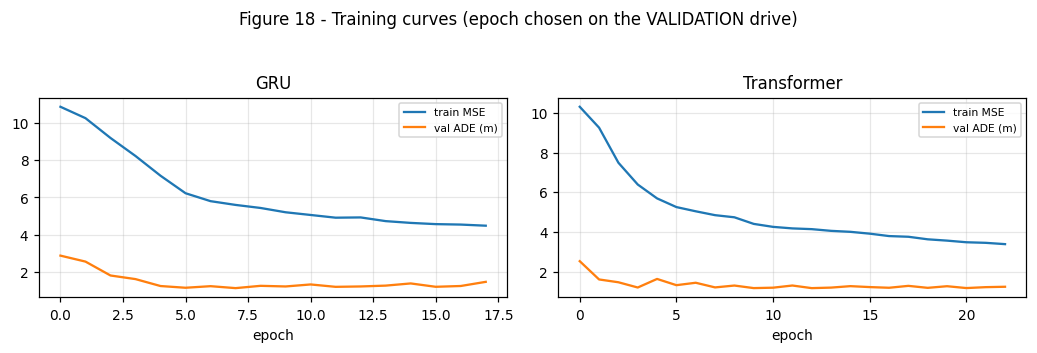

In [28]:
# ---------------------------------------------------------------------------
# Sections 25-26 - Constant velocity, Random Forest, GRU, Transformer
# ---------------------------------------------------------------------------
def constant_velocity(v0: np.ndarray, dt: np.ndarray, pred: int = PRED_LEN) -> np.ndarray:
    """Extrapolate the last observed velocity. v0:(N,2), dt:(N,) -> (N,pred,3)."""
    k = np.arange(1, pred + 1, dtype=np.float64)[None, :, None]      # (1,pred,1)
    xy = v0[:, None, :].astype(np.float64) * k * dt[:, None, None]   # (N,pred,2)
    return np.concatenate([xy, np.zeros((len(v0), pred, 1))], axis=2).astype(np.float32)


def ade_fde(pred: np.ndarray, true: np.ndarray, planar: bool = True) -> Tuple[float, float]:
    """Average and Final Displacement Error in metres (BEV by default)."""
    d = 2 if planar else 3
    e = np.linalg.norm(pred[..., :d] - true[..., :d], axis=-1)       # (N,pred)
    return float(e.mean()), float(e[:, -1].mean())


def full_metrics(pred: np.ndarray, true: np.ndarray) -> Dict[str, float]:
    ade, fde = ade_fde(pred, true)
    ade3, fde3 = ade_fde(pred, true, planar=False)
    err = pred[..., :2] - true[..., :2]
    return {"ADE_m": ade, "FDE_m": fde, "ADE_3D_m": ade3, "FDE_3D_m": fde3,
            "RMSE_m": float(np.sqrt((err ** 2).sum(-1).mean())),
            "MAE_m": float(np.abs(err).mean())}


TRAJ_MODELS: Dict[str, np.ndarray] = {}
TRAJ_HISTORY: Dict[str, Any] = {}

if N_WIN and SPLIT_OK:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.preprocessing import StandardScaler
    import torch.nn as nn

    Xtr, Ytr = TRAJ["X"][m_tr], TRAJ["Y"][m_tr]
    Xva, Yva = TRAJ["X"][m_va], TRAJ["Y"][m_va]
    Xte, Yte = TRAJ["X"][m_te], TRAJ["Y"][m_te]
    HAS_VAL = len(Xva) >= 10
    if not HAS_VAL:
        log("validation split is empty/small; using the last epoch instead of early stopping", "WARN")

    # ---------- Baseline 1: constant velocity -------------------------------
    TRAJ_MODELS["Constant velocity"] = constant_velocity(TRAJ["v0"][m_te], TRAJ["dt"][m_te])

    # ---------- Baseline 2: Random Forest -----------------------------------
    sc = StandardScaler().fit(Xtr.reshape(len(Xtr), -1))            # TRAIN ONLY
    ftr, fte = sc.transform(Xtr.reshape(len(Xtr), -1)), sc.transform(Xte.reshape(len(Xte), -1))
    rf = RandomForestRegressor(n_estimators=200 if not DEBUG_MODE else 80, min_samples_leaf=2,
                               random_state=SEED, n_jobs=-1)
    rf.fit(ftr, Ytr.reshape(len(Ytr), -1))
    TRAJ_MODELS["Random forest"] = rf.predict(fte).reshape(-1, PRED_LEN, 3).astype(np.float32)
    log("random forest trained")

    # ---------- Torch data ---------------------------------------------------
    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(0) + 1e-6               # TRAIN ONLY

    def to_t(X): return torch.tensor((X - mu) / sd, dtype=torch.float32)

    Xtr_t, Ytr_t = to_t(Xtr).to(DEVICE), torch.tensor(Ytr).to(DEVICE)
    Xva_t, Yva_t = to_t(Xva).to(DEVICE), torch.tensor(Yva).to(DEVICE)
    Xte_t = to_t(Xte).to(DEVICE)

    class GRUPredictor(nn.Module):
        """GRU encoder + MLP decoder -> pred_len x 3 displacements."""

        def __init__(self, nf: int, hidden: int, layers: int, pred: int):
            super().__init__()
            self.pred = pred
            self.gru = nn.GRU(nf, hidden, num_layers=layers, batch_first=True,
                              dropout=0.1 if layers > 1 else 0.0)
            self.head = nn.Sequential(nn.Linear(hidden, 128), nn.ReLU(), nn.Dropout(0.1),
                                      nn.Linear(128, pred * 3))

        def forward(self, x):
            return self.head(self.gru(x)[0][:, -1]).view(-1, self.pred, 3)

    class TrajTransformer(nn.Module):
        """Small Transformer encoder with sinusoidal positional encoding + mean pooling."""

        def __init__(self, nf: int, d_model: int, pred: int, nhead: int = 4, layers: int = 2):
            super().__init__()
            self.pred, self.d_model = pred, d_model
            self.inp = nn.Linear(nf, d_model)
            enc = nn.TransformerEncoderLayer(d_model, nhead, d_model * 2, dropout=0.1,
                                             batch_first=True, norm_first=True)
            self.enc = nn.TransformerEncoder(enc, layers)
            self.head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, pred * 3))
            pe = torch.zeros(OBS_LEN, d_model)
            pos = torch.arange(OBS_LEN).unsqueeze(1).float()
            div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
            self.register_buffer("pe", pe.unsqueeze(0))

        def forward(self, x):
            h = self.enc(self.inp(x) + self.pe[:, : x.shape[1]])
            return self.head(h.mean(1)).view(-1, self.pred, 3)

    def train_model(model: nn.Module, name: str, epochs: int) -> nn.Module:
        set_seed(SEED)
        model = model.to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=CONFIG["gru_lr"], weight_decay=1e-5)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=4)
        lossf = nn.MSELoss()
        best, best_state, bad = np.inf, None, 0
        hist = {"train": [], "val": []}
        bs = CONFIG["gru_batch_size"]
        for ep in range(epochs):
            model.train()
            perm = torch.randperm(len(Xtr_t), device=DEVICE)
            tot = 0.0
            for i in range(0, len(perm), bs):
                idx = perm[i:i + bs]
                opt.zero_grad()
                loss = lossf(model(Xtr_t[idx]), Ytr_t[idx])
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                tot += float(loss.detach()) * len(idx)
            hist["train"].append(tot / max(len(perm), 1))
            model.eval()
            if HAS_VAL:
                with torch.no_grad():
                    vp = model(Xva_t).cpu().numpy()
                vade, _ = ade_fde(vp, Yva)
                hist["val"].append(vade)
                sched.step(vade)
                if vade < best - 1e-4:
                    best, bad = vade, 0
                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                else:
                    bad += 1
                    if bad >= CONFIG["patience"]:
                        log(f"  {name}: early stop at epoch {ep + 1} (best val ADE {best:.3f} m)")
                        break
            if (ep + 1) % max(1, epochs // 5) == 0:
                v = f", val ADE {hist['val'][-1]:.3f} m" if hist["val"] else ""
                log(f"  {name} epoch {ep + 1}/{epochs}: train MSE {hist['train'][-1]:.4f}{v}")
        if best_state is not None:
            model.load_state_dict(best_state)
        TRAJ_HISTORY[name] = hist
        return model

    log(f"training GRU on {len(Xtr)} windows for up to {GRU_EPOCHS} epochs ({DEVICE})")
    gru = train_model(GRUPredictor(Xtr.shape[-1], CONFIG["gru_hidden"], CONFIG["gru_layers"], PRED_LEN),
                      "GRU", GRU_EPOCHS)
    with torch.no_grad():
        TRAJ_MODELS["GRU (main model)"] = gru(Xte_t).cpu().numpy()

    if CONFIG["train_transformer"]:
        try:
            log("training Transformer")
            trf = train_model(TrajTransformer(Xtr.shape[-1], 64, PRED_LEN), "Transformer",
                              max(6, GRU_EPOCHS // 2))
            with torch.no_grad():
                TRAJ_MODELS["Transformer"] = trf(Xte_t).cpu().numpy()
        except Exception as e:
            log(f"transformer skipped: {type(e).__name__}: {e}", "WARN")

    if TRAJ_HISTORY:
        plt.figure(figsize=(9.5, 3))
        for i, (n, h) in enumerate(TRAJ_HISTORY.items(), 1):
            plt.subplot(1, len(TRAJ_HISTORY), i)
            plt.plot(h["train"], label="train MSE")
            if h["val"]:
                plt.plot(h["val"], label="val ADE (m)")
            plt.xlabel("epoch"); plt.title(n); plt.legend(fontsize=7); plt.grid(alpha=0.3)
        plt.suptitle("Figure 18 - Training curves (epoch chosen on the VALIDATION drive)", y=1.05)
        plt.tight_layout(); plt.show()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
else:
    print("Trajectory model training skipped:", NOTES.get("trajectory_ml", "insufficient data"))

## 27. Trajectory Prediction Evaluation

* **ADE** (Average Displacement Error) — mean L2 error over all 10 predicted steps, in metres.
  Measures overall trajectory quality.
* **FDE** (Final Displacement Error) — L2 error at the last predicted step (t + 1.0 s).
  Measures how far the prediction has drifted by the end of the horizon, and is always larger.
* **RMSE / MAE** — per-coordinate errors, reported for completeness.

Displacement errors are computed in the ground plane; the 3D versions are also reported.
Results are broken out by **vehicle class**, **prediction horizon**, and **test drive**,
because a single averaged number hides whether a model is good everywhere or good on average.

Everything below is on the **test drives**, which no model has seen.

TEST SET: 234 windows from drives [np.str_('2011_09_26_drive_0013'), np.str_('2011_09_26_drive_0014')] (11 tracks) - never used for training or model selection


,model,ADE_m,FDE_m,ADE_3D_m,FDE_3D_m,RMSE_m,MAE_m
0,Constant velocity,1.2604,2.2139,1.3114,2.3022,4.3015,0.6756
3,Transformer,1.3516,2.6266,1.3634,2.6348,2.0442,0.8638
1,Random forest,1.5774,2.8595,1.5933,2.8799,2.6478,0.9108
2,GRU (main model),1.8579,4.0633,1.8675,4.0832,2.6038,1.1467



Headline: the GRU is 47.4% WORSE than constant velocity.
Reported as measured. Over a 1 s horizon vehicles largely do move at constant
velocity, so a physics baseline is hard to beat with limited training data.

Mean displacement error (m) by prediction horizon:


,Constant velocity,Random forest,GRU (main model),Transformer
t+0.1s,0.132,0.170,0.361,0.185
t+0.2s,0.409,0.413,0.558,0.564
t+0.3s,0.707,0.772,0.824,0.750
t+0.4s,1.014,1.170,1.245,1.089
t+0.5s,1.248,1.519,1.584,1.165
t+0.6s,1.438,1.830,1.857,1.404
t+0.7s,1.629,2.092,2.154,1.556
t+0.8s,1.822,2.356,2.696,1.978
t+0.9s,1.991,2.593,3.236,2.199
t+1.0s,2.214,2.859,4.063,2.627



By vehicle class:


model,Constant velocity,GRU (main model),Random forest,Transformer
class,,,,
Car,1.26,1.858,1.577,1.352


By test drive (sequence-level generalisation):


model,Constant velocity,GRU (main model),Random forest,Transformer
drive,,,,
2011_09_26_drive_0013,1.304,1.776,1.294,1.314
2011_09_26_drive_0014,1.218,1.939,1.856,1.389


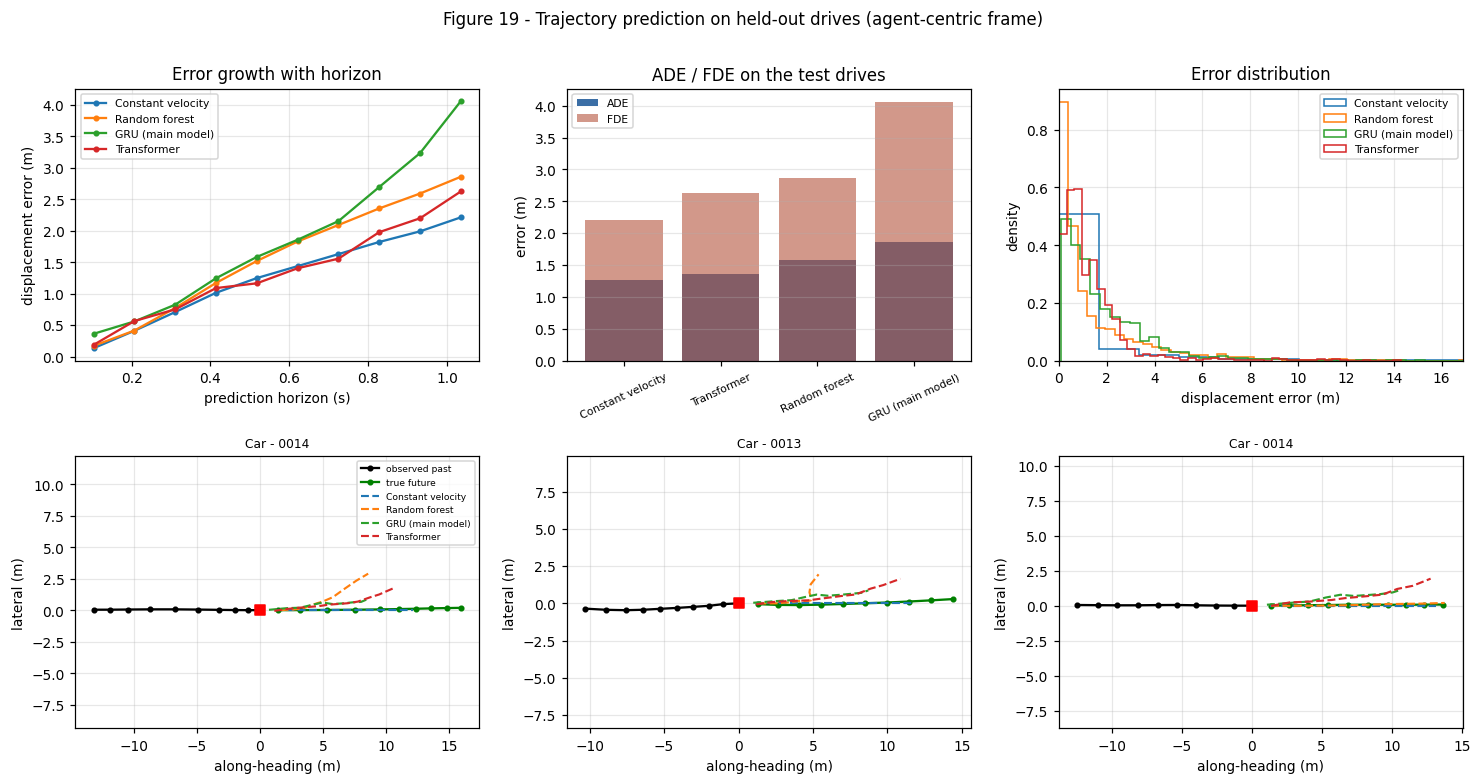

In [29]:
# ---------------------------------------------------------------------------
# Section 27 - Test-set evaluation: ADE / FDE / RMSE / MAE
# ---------------------------------------------------------------------------
TRAJ_EVAL: Dict[str, Any] = {}
if TRAJ_MODELS:
    rows = [{"model": n, **{k: round(v, 4) for k, v in full_metrics(p, Yte).items()}}
            for n, p in TRAJ_MODELS.items()]
    TRAJ_DF = pd.DataFrame(rows).sort_values("ADE_m")
    print(f"TEST SET: {len(Yte)} windows from drives {sorted(set(TRAJ['drive'][m_te]))} "
          f"({len(set(TRAJ['uid'][m_te]))} tracks) - never used for training or model selection")
    display(TRAJ_DF)

    cv_ade = float(TRAJ_DF.loc[TRAJ_DF["model"] == "Constant velocity", "ADE_m"].iloc[0])
    cv_fde = float(TRAJ_DF.loc[TRAJ_DF["model"] == "Constant velocity", "FDE_m"].iloc[0])
    best_row = TRAJ_DF.iloc[0]
    METRICS["traj_ADE_constant_velocity_m"] = cv_ade
    METRICS["traj_FDE_constant_velocity_m"] = cv_fde
    METRICS["traj_best_model"] = best_row["model"]
    METRICS["traj_ADE_best_m"] = float(best_row["ADE_m"])
    METRICS["traj_FDE_best_m"] = float(best_row["FDE_m"])
    if "GRU (main model)" in TRAJ_MODELS:
        g = TRAJ_DF[TRAJ_DF["model"] == "GRU (main model)"].iloc[0]
        METRICS["traj_ADE_GRU_m"] = float(g["ADE_m"]); METRICS["traj_FDE_GRU_m"] = float(g["FDE_m"])
        imp = 100 * (cv_ade - float(g["ADE_m"])) / cv_ade
        METRICS["traj_GRU_vs_CV_ADE_improvement_pct"] = round(imp, 1)
        verdict = (f"the GRU improves ADE by {imp:.1f}% over constant velocity" if imp > 0
                   else f"the GRU is {abs(imp):.1f}% WORSE than constant velocity")
        NOTES["traj_verdict"] = verdict
        print(f"\nHeadline: {verdict}.")
        if imp <= 0:
            print("Reported as measured. Over a 1 s horizon vehicles largely do move at constant")
            print("velocity, so a physics baseline is hard to beat with limited training data.")

    # ---- by prediction horizon ---------------------------------------------
    dt_med = float(np.median(TRAJ["dt"][m_te]))
    hz = {n: np.linalg.norm(p[..., :2] - Yte[..., :2], axis=-1).mean(0) for n, p in TRAJ_MODELS.items()}
    HZ_DF = pd.DataFrame(hz, index=[f"t+{(k + 1) * dt_med:.1f}s" for k in range(PRED_LEN)]).round(3)
    print("\nMean displacement error (m) by prediction horizon:")
    display(HZ_DF)

    # ---- by class and by drive ----------------------------------------------
    cls_rows, drv_rows = [], []
    for n, p in TRAJ_MODELS.items():
        for c in sorted(set(TRAJ["cls"][m_te])):
            k = TRAJ["cls"][m_te] == c
            if k.sum() >= 5:
                a, f_ = ade_fde(p[k], Yte[k])
                cls_rows.append({"model": n, "class": c, "n": int(k.sum()),
                                 "ADE_m": round(a, 3), "FDE_m": round(f_, 3)})
        for dr in sorted(set(TRAJ["drive"][m_te])):
            k = TRAJ["drive"][m_te] == dr
            if k.sum() >= 5:
                a, f_ = ade_fde(p[k], Yte[k])
                drv_rows.append({"model": n, "drive": dr, "n": int(k.sum()),
                                 "ADE_m": round(a, 3), "FDE_m": round(f_, 3)})
    if cls_rows:
        print("\nBy vehicle class:")
        display(pd.DataFrame(cls_rows).pivot(index="class", columns="model", values="ADE_m"))
    if drv_rows:
        print("By test drive (sequence-level generalisation):")
        display(pd.DataFrame(drv_rows).pivot(index="drive", columns="model", values="ADE_m"))
    TRAJ_EVAL = {"table": TRAJ_DF, "horizon": HZ_DF,
                 "by_class": pd.DataFrame(cls_rows), "by_drive": pd.DataFrame(drv_rows)}

    # ---- plots ---------------------------------------------------------------
    fig = plt.figure(figsize=(13.5, 7))
    ax = fig.add_subplot(2, 3, 1)
    for n in hz:
        ax.plot([(k + 1) * dt_med for k in range(PRED_LEN)], hz[n], "-o", ms=3, label=n)
    ax.set_xlabel("prediction horizon (s)"); ax.set_ylabel("displacement error (m)")
    ax.set_title("Error growth with horizon"); ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = fig.add_subplot(2, 3, 2)
    ax.bar(TRAJ_DF["model"], TRAJ_DF["ADE_m"], color="#3b6ea5", label="ADE")
    ax.bar(TRAJ_DF["model"], TRAJ_DF["FDE_m"], color="#b5533c", alpha=0.6, label="FDE")
    ax.set_ylabel("error (m)"); ax.set_title("ADE / FDE on the test drives")
    ax.tick_params(axis="x", rotation=25, labelsize=7); ax.legend(fontsize=7); ax.grid(alpha=0.3, axis="y")

    ax = fig.add_subplot(2, 3, 3)
    for n, p in TRAJ_MODELS.items():
        e = np.linalg.norm(p[..., :2] - Yte[..., :2], axis=-1).ravel()
        ax.hist(e, bins=45, histtype="step", lw=1.5, label=n, density=True)
    ax.set_xlabel("displacement error (m)"); ax.set_ylabel("density")
    ax.set_title("Error distribution"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.set_xlim(0, np.percentile(np.linalg.norm(TRAJ_MODELS["Constant velocity"][..., :2] - Yte[..., :2], axis=-1), 99))

    rng = np.random.default_rng(SEED)
    show = rng.choice(len(Yte), min(3, len(Yte)), replace=False)
    for j, si in enumerate(show):
        ax = fig.add_subplot(2, 3, 4 + j)
        past = Xte[si][:, :2]
        ax.plot(past[:, 0], past[:, 1], "-o", ms=3, color="black", label="observed past")
        ax.plot(Yte[si][:, 0], Yte[si][:, 1], "-o", ms=3, color="green", label="true future")
        for n, p in TRAJ_MODELS.items():
            ax.plot(p[si][:, 0], p[si][:, 1], "--", lw=1.4, label=n)
        ax.scatter([0], [0], marker="s", s=45, c="red", zorder=6)
        ax.set_title(f"{TRAJ['cls'][m_te][si]} - {TRAJ['drive'][m_te][si][-4:]}", fontsize=8)
        ax.set_xlabel("along-heading (m)"); ax.set_ylabel("lateral (m)")
        ax.axis("equal"); ax.grid(alpha=0.3)
        if j == 0:
            ax.legend(fontsize=6)
    plt.suptitle("Figure 19 - Trajectory prediction on held-out drives (agent-centric frame)", y=1.01)
    plt.tight_layout(); plt.show()
else:
    print("Trajectory evaluation:", NOTES.get("trajectory_ml", "NOT AVAILABLE - no models were trained"))

## 28. Motion Anomaly Detection (optional)

**Naming matters.** This is **motion anomaly detection**, not accident detection. KITTI
contains no crashes and no anomaly labels, so there is nothing to validate against and no
basis for calling a flagged trajectory dangerous. An anomaly here means only: *this
trajectory's kinematics are unusual relative to the training distribution.* Perfectly safe
manoeuvres — a sharp legal turn, a bus pulling away — are unusual, and tracking errors are
also unusual. Both will be flagged.

Two unsupervised models on per-track motion features (mean/max speed, acceleration extremes,
jerk, lateral motion, curvature, heading change, track length):

* **Isolation Forest** — isolates points with random axis-aligned splits; unusual points need
  fewer splits.
* **Dense autoencoder** — compresses to a small bottleneck; typical motion reconstructs well,
  unusual motion does not, so reconstruction error is the score.

Both are fitted on **training drives only** and applied to the test drives. Since neither has
ground truth, the honest evaluation is **agreement between two independent methods** plus
inspection of what actually got flagged.

tracks with motion features: 142
Isolation Forest flagged 13 tracks; autoencoder flagged 22.
The two independent methods agree on 85.2% of tracks; 7 flagged by both.

Top motion anomalies (UNSUPERVISED - unusual, NOT necessarily dangerous):


,uid,split,cls,speed_mean,speed_max,accel_min,accel_max,curv_max,heading_change,iso_score
82,2011_09_26_drive_0057#14,train,Car,22.00,108.79,-360.27,268.18,4258.67,-977.05,0.72
38,2011_09_26_drive_0011#8,train,Car,56.23,185.89,-182.55,754.11,3.58,185.02,0.70
103,2011_09_26_drive_0059#35,val,Car,57.60,163.11,-424.05,272.29,10.88,-535.26,0.67
78,2011_09_26_drive_0057#6,train,Car,14.80,99.60,-342.23,348.70,185.33,-603.61,0.64
89,2011_09_26_drive_0057#23,train,Car,45.88,177.14,-156.19,637.11,3.30,29.73,0.62
84,2011_09_26_drive_0057#16,train,Truck,54.90,101.99,-304.22,447.09,1.80,-95.02,0.61


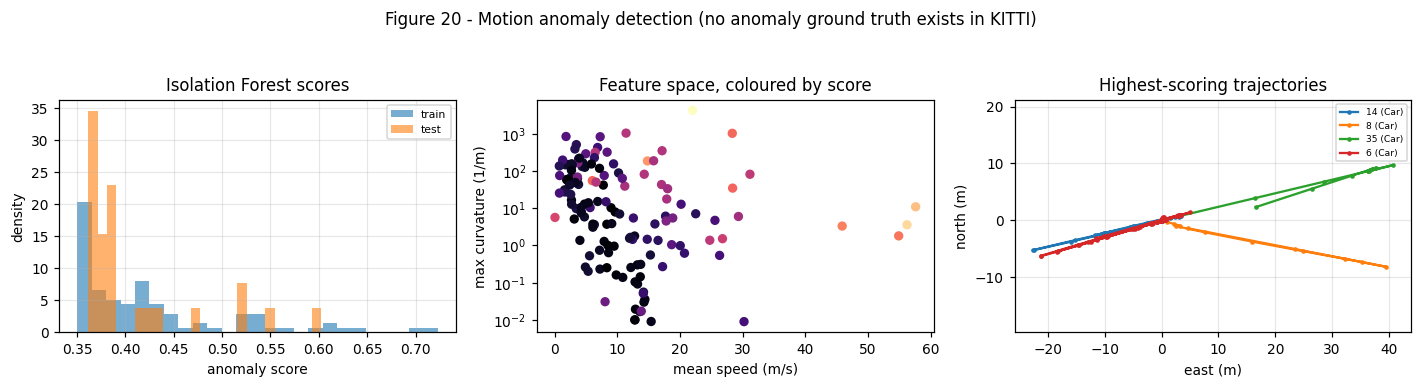

In [30]:
# ---------------------------------------------------------------------------
# Section 28 - Motion anomaly detection (unsupervised, no ground truth exists)
# ---------------------------------------------------------------------------
ANOM: Dict[str, Any] = {}
ANOM_FEATURES = ["speed_mean", "speed_max", "speed_std", "accel_max", "accel_min",
                 "jerk_absmax", "lat_absmax", "curv_max", "heading_change", "length"]


def track_motion_features(df: pd.DataFrame) -> pd.DataFrame:
    """One feature vector per vehicle track."""
    rows = []
    for uid, g in df[df["is_vehicle"]].groupby("uid", sort=False):
        g = g.sort_values("frame")
        if len(g) < 10 or g["speed"].isna().all():
            continue
        rows.append({
            "uid": uid, "drive": g["drive"].iloc[0], "split": g["split"].iloc[0], "cls": g["cls"].iloc[0],
            "speed_mean": g["speed"].mean(), "speed_max": g["speed"].max(), "speed_std": g["speed"].std(),
            "accel_max": g["accel"].max(), "accel_min": g["accel"].min(),
            "jerk_absmax": g["jerk"].abs().max(), "lat_absmax": g["v_lat"].abs().max(),
            "curv_max": g["curvature"].max(),
            "heading_change": float(np.degrees(g["heading"].iloc[-1] - g["heading"].iloc[0])),
            "length": len(g),
        })
    return pd.DataFrame(rows).dropna()


AF = track_motion_features(TRACKS)
print(f"tracks with motion features: {len(AF)}")
if len(AF) >= 25 and (AF["split"] == "train").sum() >= 10:
    from sklearn.ensemble import IsolationForest
    from sklearn.preprocessing import StandardScaler

    tr = AF[AF["split"] == "train"]
    sc = StandardScaler().fit(tr[ANOM_FEATURES])            # TRAIN ONLY
    Za, Ztr = sc.transform(AF[ANOM_FEATURES]), sc.transform(tr[ANOM_FEATURES])
    iso = IsolationForest(n_estimators=250, contamination=0.1, random_state=SEED).fit(Ztr)
    AF["iso_score"] = -iso.score_samples(Za)                # higher = more anomalous
    AF["iso_flag"] = iso.predict(Za) == -1

    try:
        import torch.nn as nn
        set_seed(SEED)
        ae = nn.Sequential(nn.Linear(len(ANOM_FEATURES), 16), nn.ReLU(), nn.Linear(16, 4), nn.ReLU(),
                           nn.Linear(4, 16), nn.ReLU(), nn.Linear(16, len(ANOM_FEATURES))).to(DEVICE)
        opt = torch.optim.Adam(ae.parameters(), lr=5e-3)
        Xt = torch.tensor(Ztr, dtype=torch.float32, device=DEVICE)
        for _ in range(300 if not DEBUG_MODE else 120):
            opt.zero_grad()
            loss = torch.nn.functional.mse_loss(ae(Xt), Xt)
            loss.backward(); opt.step()
        with torch.no_grad():
            Xa = torch.tensor(Za, dtype=torch.float32, device=DEVICE)
            AF["ae_score"] = ((ae(Xa) - Xa) ** 2).mean(1).cpu().numpy()
        thr = float(np.percentile(AF.loc[AF["split"] == "train", "ae_score"], 90))
        AF["ae_flag"] = AF["ae_score"] > thr
        agree = float((AF["iso_flag"] == AF["ae_flag"]).mean())
        both = int((AF["iso_flag"] & AF["ae_flag"]).sum())
        METRICS["anomaly_method_agreement"] = round(agree, 3)
        print(f"Isolation Forest flagged {AF['iso_flag'].sum()} tracks; autoencoder flagged {AF['ae_flag'].sum()}.")
        print(f"The two independent methods agree on {agree:.1%} of tracks; {both} flagged by both.")
    except Exception as e:
        log(f"autoencoder skipped: {type(e).__name__}: {e}", "WARN")
        AF["ae_score"] = np.nan; AF["ae_flag"] = False

    ANOM = {"table": AF}
    METRICS["anomaly_tracks_flagged"] = int(AF["iso_flag"].sum())
    print("\nTop motion anomalies (UNSUPERVISED - unusual, NOT necessarily dangerous):")
    display(AF.sort_values("iso_score", ascending=False).head(6)[
        ["uid", "split", "cls", "speed_mean", "speed_max", "accel_min", "accel_max",
         "curv_max", "heading_change", "iso_score"]].round(2))

    fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))
    ax[0].hist(AF.loc[AF["split"] == "train", "iso_score"], bins=25, alpha=0.6, label="train", density=True)
    ax[0].hist(AF.loc[AF["split"] == "test", "iso_score"], bins=25, alpha=0.6, label="test", density=True)
    ax[0].set_xlabel("anomaly score"); ax[0].set_ylabel("density")
    ax[0].set_title("Isolation Forest scores"); ax[0].legend(fontsize=7); ax[0].grid(alpha=0.3)
    ax[1].scatter(AF["speed_mean"], AF["curv_max"], c=AF["iso_score"], cmap="magma", s=26)
    ax[1].set_xlabel("mean speed (m/s)"); ax[1].set_ylabel("max curvature (1/m)")
    ax[1].set_title("Feature space, coloured by score"); ax[1].set_yscale("symlog", linthresh=1e-3)
    for uid in AF.sort_values("iso_score", ascending=False).head(4)["uid"]:
        g = TRACKS[TRACKS["uid"] == uid].sort_values("frame")
        if g["Xw_s"].notna().all():
            ax[2].plot(g["Xw_s"] - g["Xw_s"].iloc[0], g["Yw_s"] - g["Yw_s"].iloc[0], "-o", ms=2,
                       label=f"{uid.split('#')[1]} ({g['cls'].iloc[0]})")
    ax[2].set_xlabel("east (m)"); ax[2].set_ylabel("north (m)"); ax[2].axis("equal")
    ax[2].set_title("Highest-scoring trajectories"); ax[2].legend(fontsize=6); ax[2].grid(alpha=0.3)
    plt.suptitle("Figure 20 - Motion anomaly detection (no anomaly ground truth exists in KITTI)", y=1.05)
    plt.tight_layout(); plt.show()
else:
    NOTES["anomaly"] = "NOT AVAILABLE - too few tracks with world-frame kinematics"
    print("Anomaly detection:", NOTES["anomaly"])

## 29. Final Integrated Pipeline

Everything assembled into a single per-frame view: image with tracked boxes annotated with
class, ID, depth and speed; disparity; and a bird's-eye view carrying the recent trajectory
plus the model's predicted future. This is also the rendering used by the Gradio demo, so the
demo shows the real pipeline output rather than a separate code path.

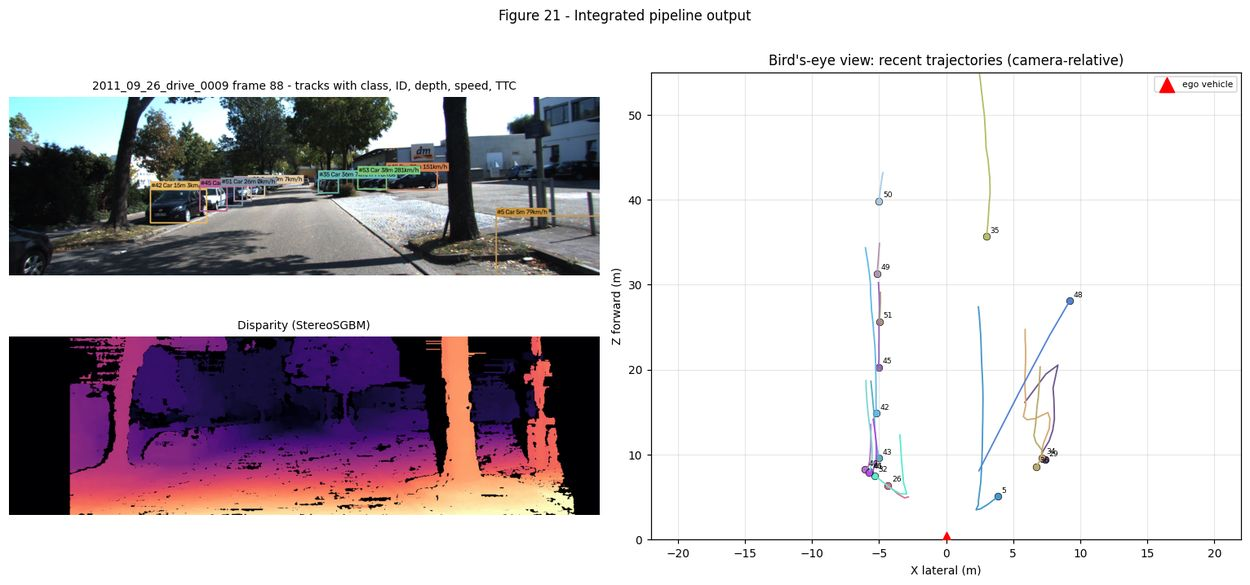

,track,class,Z_m,X_m,speed_kmh,accel_mps2,behaviour,TTC_s
0,#5,Car,5.1,3.9,78.9,35.52,accelerating,NaN
1,#35,Car,35.7,3.0,7.2,-1.62,turning,3.83
2,#42,Car,14.9,-5.2,2.7,0.32,cruising,NaN
3,#45,Car,20.3,-5.0,3.1,0.91,accelerating,NaN
4,#48,Car,28.1,9.2,151.3,-257.13,turning,NaN
5,#49,Car,31.3,-5.1,2.0,-0.40,stopped,NaN
6,#50,Car,39.8,-5.0,6.6,4.87,turning,NaN
7,#51,Car,25.6,-5.0,0.3,0.61,stopped,NaN
8,#53,Car,37.9,7.6,280.5,-7.42,turning,NaN


In [31]:
# ---------------------------------------------------------------------------
# Section 29a - Integrated per-frame rendering + trajectory prediction helper
# ---------------------------------------------------------------------------
HAS_GRU = "gru" in globals() and "mu" in globals() and "sd" in globals()


def make_window(uid: str, end_frame: int, obs: int = OBS_LEN) -> Optional[Dict[str, Any]]:
    """Build one agent-centric input window for a track ending at end_frame."""
    g = TRACKS[(TRACKS["uid"] == uid) & (TRACKS["frame"] <= end_frame)].sort_values("frame")
    need = ["Xw_s", "Yw_s", "Zw_s", "vx", "vy", "speed", "accel", "heading", "heading_rate", "curvature"]
    if len(g) < obs:
        return None
    g = g.iloc[-obs:]
    if g[need].isna().any().any():
        return None
    P = g[["Xw_s", "Yw_s", "Zw_s"]].to_numpy(np.float64)
    o, th = P[-1], float(g["heading"].iloc[-1])
    c, s = math.cos(-th), math.sin(-th)
    R = np.array([[c, -s], [s, c]])
    past_xy = (R @ (P[:, :2] - o[:2]).T).T
    v_loc = (R @ g[["vx", "vy"]].to_numpy(np.float64).T).T
    feats = np.column_stack([past_xy[:, 0], past_xy[:, 1], P[:, 2] - o[2],
                             v_loc[:, 0], v_loc[:, 1], g["speed"], g["accel"],
                             g["heading_rate"], g["curvature"]]).astype(np.float32)
    if not np.isfinite(feats).all():
        return None
    dts = np.diff(g["t"].to_numpy())
    return {"feats": feats, "origin": o, "theta": th, "R_inv": np.array([[c, s], [-s, c]]),
            "v0": v_loc[-1], "dt": float(np.median(dts)) if len(dts) else 0.1}


def predict_future_world(uid: str, end_frame: int) -> Dict[str, Optional[np.ndarray]]:
    """Predicted future positions in WORLD coordinates for GRU and constant velocity."""
    w = make_window(uid, end_frame)
    if w is None:
        return {"gru": None, "cv": None}
    out: Dict[str, Optional[np.ndarray]] = {"gru": None, "cv": None}
    def to_world(local: np.ndarray) -> np.ndarray:
        xy = (w["R_inv"] @ local[:, :2].T).T + w["origin"][:2]
        return np.column_stack([xy, local[:, 2] + w["origin"][2]])

    cv_local = constant_velocity(w["v0"][None, :].astype(np.float32),
                                 np.array([w["dt"]]))[0]      # (pred,3)
    out["cv"] = to_world(cv_local)
    if HAS_GRU:
        try:
            with torch.no_grad():
                t = torch.tensor((w["feats"] - mu) / sd, dtype=torch.float32).unsqueeze(0).to(DEVICE)
                p = gru(t)[0].cpu().numpy()
            out["gru"] = to_world(p)
        except Exception:
            pass
    return out


def render_frame(drive: str, frame: int, focus_uid: Optional[str] = None,
                 with_disparity: bool = True, history: int = 25
                 ) -> Dict[str, Any]:
    """Full integrated view of one frame: annotated image, disparity, depth, BEV, per-object info."""
    ds = DRIVE_OBJ[drive]
    frame = int(min(max(frame, ds.frames[0]), ds.frames[-1]))
    imgL = ds.load_left(frame)
    disp = depth = None
    if with_disparity:
        d, _ = STEREO.compute(imgL, ds.load_right(frame))
        disp = d
        depth = disparity_to_depth(d, FX, BASELINE, CONFIG["max_object_depth_m"] + 30)

    cur = TRACKS[(TRACKS["drive"] == drive) & (TRACKS["frame"] == frame)]
    boxes, labels, info = [], {}, []
    for _, r in cur.iterrows():
        boxes.append({"track_id": int(r["track_id"]), "cls": r["cls"],
                      "bbox": (r["x1"], r["y1"], r["x2"], r["y2"])})
        bits = []
        if np.isfinite(r.get("Zc_s", np.nan)):
            bits.append(f"{r['Zc_s']:.0f}m")
        if np.isfinite(r.get("speed_kmh", np.nan)):
            bits.append(f"{r['speed_kmh']:.0f}km/h")
        if np.isfinite(r.get("ttc", np.nan)):
            bits.append(f"TTC{r['ttc']:.1f}s")
        labels[int(r["track_id"])] = " ".join(bits)
        info.append({"track": f"#{int(r['track_id'])}", "class": r["cls"],
                     "Z_m": round(float(r["Zc_s"]), 1) if np.isfinite(r.get("Zc_s", np.nan)) else None,
                     "X_m": round(float(r["Xc_s"]), 1) if np.isfinite(r.get("Xc_s", np.nan)) else None,
                     "speed_kmh": round(float(r["speed_kmh"]), 1) if np.isfinite(r.get("speed_kmh", np.nan)) else None,
                     "accel_mps2": round(float(r["accel"]), 2) if np.isfinite(r.get("accel", np.nan)) else None,
                     "behaviour": r.get("behaviour", None),
                     "TTC_s": round(float(r["ttc"]), 2) if np.isfinite(r.get("ttc", np.nan)) else None})
    annotated = draw_tracks(imgL, boxes, labels)

    hist_tracks: Dict[str, np.ndarray] = {}
    for uid, g in TRACKS[(TRACKS["drive"] == drive) & (TRACKS["frame"] <= frame) &
                         (TRACKS["frame"] > frame - history)].groupby("uid"):
        if g["Xc_s"].notna().all() and len(g) >= 3:
            hist_tracks[uid] = g.sort_values("frame")[["Xc_s", "Zc_s"]].to_numpy()

    pred = predict_future_world(focus_uid, frame) if focus_uid else {"gru": None, "cv": None}
    return {"image": imgL, "annotated": annotated, "disparity": disp, "depth": depth,
            "info": pd.DataFrame(info), "hist": hist_tracks, "pred": pred,
            "frame": frame, "n_tracks": len(boxes)}


def colorize(arr: Optional[np.ndarray], cmap: str = "magma", vmax: Optional[float] = None) -> Optional[np.ndarray]:
    """Float map with NaNs -> RGB uint8 image for display."""
    if arr is None:
        return None
    a = arr.copy().astype(np.float32)
    m = np.isfinite(a)
    if not m.any():
        return np.zeros(a.shape + (3,), np.uint8)
    hi = vmax if vmax is not None else float(np.nanpercentile(a[m], 99))
    a = np.clip(np.nan_to_num(a, nan=0.0), 0, max(hi, 1e-6)) / max(hi, 1e-6)
    return (plt.get_cmap(cmap)(a)[:, :, :3] * 255).astype(np.uint8)


_demo_drive = VIZ_DRIVE
_cands = TRACKS[(TRACKS["drive"] == _demo_drive) & TRACKS["is_vehicle"]]
_focus = (_cands.groupby("uid").size().sort_values(ascending=False).index[0]
          if len(_cands) else None)
_fnum = int(TRACKS[TRACKS["uid"] == _focus]["frame"].iloc[-1]) if _focus else DRIVE_OBJ[_demo_drive].frames[-1]
R = render_frame(_demo_drive, _fnum, _focus)

fig = plt.figure(figsize=(14, 6.4))
ax = fig.add_subplot(2, 2, 1); ax.imshow(cv2.cvtColor(R["annotated"], cv2.COLOR_BGR2RGB))
ax.set_title(f"{_demo_drive} frame {R['frame']} - tracks with class, ID, depth, speed, TTC", fontsize=9)
ax.axis("off")
ax = fig.add_subplot(2, 2, 3); ax.imshow(colorize(R["disparity"]))
ax.set_title("Disparity (StereoSGBM)", fontsize=9); ax.axis("off")
ax = fig.add_subplot(1, 2, 2)
for uid, p in R["hist"].items():
    c = np.array(color_for_id(int(uid.split("#")[1]))) / 255.0
    ax.plot(p[:, 0], p[:, 1], "-", lw=1.2, color=c)
    ax.scatter(p[-1, 0], p[-1, 1], s=32, color=c, edgecolor="k", linewidth=0.4)
    ax.annotate(uid.split("#")[1], (p[-1, 0], p[-1, 1]), fontsize=6, xytext=(3, 3), textcoords="offset points")
ax.scatter([0], [0], marker="^", s=140, c="red", zorder=6, label="ego vehicle")
ax.set_xlabel("X lateral (m)"); ax.set_ylabel("Z forward (m)")
ax.set_title("Bird's-eye view: recent trajectories (camera-relative)")
ax.set_xlim(-22, 22); ax.set_ylim(0, 55); ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.suptitle("Figure 21 - Integrated pipeline output", y=1.01)
plt.tight_layout(); plt.show()
if len(R["info"]):
    display(R["info"].head(10))

In [32]:
# ---------------------------------------------------------------------------
# Section 29b - Animation: tracked vehicles + predicted futures
# ---------------------------------------------------------------------------
if CONFIG["make_animation"]:
    try:
        from matplotlib import animation
        from IPython.display import HTML, display as ipy_display

        ds_a = DRIVE_OBJ[_demo_drive]
        avail = sorted(TRACKS[TRACKS["drive"] == _demo_drive]["frame"].unique())
        n_anim = min(CONFIG["animation_frames"], len(avail))
        anim_frames = avail[-n_anim:] if n_anim else []

        if anim_frames:
            fig, (axi, axb) = plt.subplots(2, 1, figsize=(10, 7),
                                           gridspec_kw={"height_ratios": [1, 1.25]})
            im_art = axi.imshow(np.zeros_like(ds_a.load_left(anim_frames[0])))
            axi.axis("off")

            def update(k):
                f = anim_frames[k]
                r = render_frame(_demo_drive, f, _focus, with_disparity=False, history=20)
                im_art.set_data(cv2.cvtColor(r["annotated"], cv2.COLOR_BGR2RGB))
                axi.set_title(f"{_demo_drive} frame {f} - {r['n_tracks']} tracked objects", fontsize=9)
                axb.clear()
                for uid, p in r["hist"].items():
                    c = np.array(color_for_id(int(uid.split("#")[1]))) / 255.0
                    axb.plot(p[:, 0], p[:, 1], "-", lw=1.2, color=c)
                    axb.scatter(p[-1, 0], p[-1, 1], s=30, color=c, edgecolor="k", linewidth=0.4)
                if _focus and r["pred"]["cv"] is not None and HAS_EGO.get(_demo_drive):
                    T = EGO[_demo_drive]["poses"].get(f)
                    if T is not None:
                        Tin = np.linalg.inv(T)
                        for key, col, lab in [("cv", "orange", "constant velocity"),
                                              ("gru", "lime", "GRU prediction")]:
                            P = r["pred"][key]
                            if P is None:
                                continue
                            Wh = np.concatenate([P, np.ones((len(P), 1))], axis=1)
                            C = (Tin @ Wh.T).T
                            axb.plot(C[:, 0], C[:, 2], "--o", ms=3, color=col, lw=1.6, label=lab)
                axb.scatter([0], [0], marker="^", s=130, c="red", zorder=6, label="ego")
                axb.set_xlim(-22, 22); axb.set_ylim(0, 55); axb.grid(alpha=0.3)
                axb.set_xlabel("X lateral (m)"); axb.set_ylabel("Z forward (m)")
                axb.legend(fontsize=7, loc="upper right")
                return [im_art]

            log(f"rendering {len(anim_frames)}-frame animation ...")
            anim = animation.FuncAnimation(fig, update, frames=len(anim_frames), interval=200, blit=False)
            plt.close(fig)
            ipy_display(HTML(anim.to_jshtml(default_mode="loop")))
        else:
            log("no frames available for the animation", "WARN")
    except Exception as e:
        log(f"animation skipped: {type(e).__name__}: {e}", "WARN")
else:
    print("Animation disabled in CONFIG.")

[ 1217.1s][INFO] rendering 40-frame animation ...


<40-frame animation rendered here in Colab>
The interactive HTML animation was ~22 MB, too large for GitHub's notebook
renderer, so it is stored separately as pipeline_demo.gif in this repository.
Re-run this cell to regenerate the interactive version.


## 30. Results Summary

Only metrics with legitimate ground-truth support appear as numbers. Anything KITTI cannot
support appears as `NOT AVAILABLE` with the reason, and the ground-truth source is named for
every row so no measurement is mistaken for something it is not.

In [33]:
# ---------------------------------------------------------------------------
# Section 30 - Final results dashboard
# ---------------------------------------------------------------------------
NA = "NOT AVAILABLE"


def m(key: str, fmt: str = "{:.3f}", missing: str = NA) -> str:
    v = METRICS.get(key)
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return missing
    return fmt.format(v) if isinstance(v, (int, float)) else str(v)


dash = [
    ("Stereo depth (dense)", "MAE (m)", m("stereo_depth_MAE_m"), "Velodyne LiDAR (ground truth)"),
    ("Stereo depth (dense)", "RMSE (m)", m("stereo_depth_RMSE_m"), "Velodyne LiDAR (ground truth)"),
    ("Stereo depth (dense)", "bad-3px (%)", m("stereo_bad3px_pct", "{:.2f}"), "Velodyne LiDAR (ground truth)"),
    ("Learned stereo (RAFT)", "MAE (m)", m("learned_stereo_depth_MAE_m"), "Velodyne LiDAR (ground truth)"),
    ("Vehicle detection", "AP@0.5", m("detection_vehicle_AP50"), "KITTI tracklets (ground truth)"),
    ("Vehicle detection", "mAP@0.5", m("detection_mAP50"), "KITTI tracklets (ground truth)"),
    ("Vehicle detection", "recall@0.5", m("detection_vehicle_recall"), "KITTI tracklets (ground truth)"),
    ("Object 3D localisation", "depth MAE (m)", m("object_depth_MAE_m"), "KITTI tracklets (ground truth)"),
    ("Object 3D localisation", "lateral MAE (m)", m("object_lateral_MAE_m"), "KITTI tracklets (ground truth)"),
    ("Tracking", "unique tracks", m("unique_tracks", "{:d}"), "no MOT ground truth - see note"),
    ("Tracking", "IDF1 / MOTA", NA, "requires KITTI Tracking benchmark labels"),
    ("Speed estimation", "MAE (m/s)", m("speed_MAE_mps"), "OXTS ego velocity, static objects"),
    ("Speed estimation", "RMSE (m/s)", m("speed_RMSE_mps"), "OXTS ego velocity, static objects"),
    ("Ego-motion compensation", "apparent speed of parked cars before (km/h)",
     m("egomotion_apparent_speed_before_kmh", "{:.2f}"), "OXTS (true value is 0)"),
    ("Ego-motion compensation", "apparent speed of parked cars after (km/h)",
     m("egomotion_apparent_speed_after_kmh", "{:.2f}"), "OXTS (true value is 0)"),
    ("Behaviour classification", "macro F1", m("behaviour_macro_F1"), "DERIVED pseudo-labels"),
    ("Behaviour classification", "accuracy", m("behaviour_accuracy"), "DERIVED pseudo-labels"),
    ("Trajectory prediction", "ADE constant velocity (m)", m("traj_ADE_constant_velocity_m"), "KITTI-derived trajectories"),
    ("Trajectory prediction", "ADE GRU (m)", m("traj_ADE_GRU_m"), "KITTI-derived trajectories"),
    ("Trajectory prediction", "FDE constant velocity (m)", m("traj_FDE_constant_velocity_m"), "KITTI-derived trajectories"),
    ("Trajectory prediction", "FDE GRU (m)", m("traj_FDE_GRU_m"), "KITTI-derived trajectories"),
    ("Trajectory prediction", "best model", str(METRICS.get("traj_best_model", NA)), "test drives only"),
    ("Motion anomaly detection", "tracks flagged", m("anomaly_tracks_flagged", "{:d}"), "no ground truth exists"),
    ("Motion anomaly detection", "method agreement", m("anomaly_method_agreement"), "IsolationForest vs autoencoder"),
]
DASH = pd.DataFrame(dash, columns=["Component", "Metric", "Result", "Reference / ground truth"])
print("=" * 96)
print("FINAL RESULTS  (mode: " + ("DEBUG smoke test" if DEBUG_MODE else "FULL experiment") + ")")
print("=" * 96)
display(DASH)
if NOTES:
    print("\nNotes and unavailable components:")
    for k, v in NOTES.items():
        print(f"  - {k}: {v}")

# ---- reproducibility record -------------------------------------------------
SUMMARY = {
    "run_mode": "debug" if DEBUG_MODE else "full",
    "seed": SEED, "device": str(DEVICE), "gpu": GPU_NAME,
    "packages": ENV_INFO,
    "detector": METRICS.get("detector"),
    "drives_train": sorted(TRAIN_D), "drives_val": sorted(VAL_D), "drives_test": sorted(TEST_D),
    "frames_per_drive": MAX_FRAMES,
    "calibration": {"fx": round(FX, 2), "fy": round(FY, 2), "cx": round(CX, 2),
                    "cy": round(CY, 2), "baseline_m": round(BASELINE, 4)},
    "model_config": {"obs_len": OBS_LEN, "pred_len": PRED_LEN, "gru_hidden": CONFIG["gru_hidden"],
                     "gru_layers": CONFIG["gru_layers"], "epochs": GRU_EPOCHS,
                     "batch_size": CONFIG["gru_batch_size"], "lr": CONFIG["gru_lr"]},
    "metrics": METRICS, "notes": NOTES,
    "runtime_minutes": round((time.time() - T_START) / 60, 1),
}
(RESULTS_DIR / f"summary_{'debug' if DEBUG_MODE else 'full'}.json").write_text(json.dumps(SUMMARY, indent=2, default=str))
DASH.to_csv(RESULTS_DIR / "results_dashboard.csv", index=False)
print(f"\nExperiment summary written to {RESULTS_DIR}")
print(f"Total runtime: {SUMMARY['runtime_minutes']} minutes on {GPU_NAME}")

FINAL RESULTS  (mode: FULL experiment)


,Component,Metric,Result,Reference / ground truth
0,Stereo depth (dense),MAE (m),1.569,Velodyne LiDAR (ground truth)
1,Stereo depth (dense),RMSE (m),4.772,Velodyne LiDAR (ground truth)
2,Stereo depth (dense),bad-3px (%),6.09,Velodyne LiDAR (ground truth)
3,Learned stereo (RAFT),MAE (m),2.193,Velodyne LiDAR (ground truth)
4,Vehicle detection,AP@0.5,0.807,KITTI tracklets (ground truth)
5,Vehicle detection,mAP@0.5,0.903,KITTI tracklets (ground truth)
6,Vehicle detection,recall@0.5,0.970,KITTI tracklets (ground truth)
7,Object 3D localisation,depth MAE (m),2.361,KITTI tracklets (ground truth)
8,Object 3D localisation,lateral MAE (m),0.737,KITTI tracklets (ground truth)
9,Tracking,unique tracks,256,no MOT ground truth - see note



Notes and unavailable components:
  - frame_rate: mean inter-frame interval 0.1035 s (~10 Hz)
  - learned_vs_classical: StereoSGBM had the lower depth MAE on 4 evaluated frames
  - traj_verdict: the GRU is 47.4% WORSE than constant velocity

Experiment summary written to /content/drive/MyDrive/kitti_stereo_trajectory/results
Total runtime: 20.6 minutes on Tesla T4


In [34]:
# ---------------------------------------------------------------------------
# Section 30b - Answers to the research questions, from measured numbers only
# ---------------------------------------------------------------------------
def answer(q: str, text: str) -> None:
    print(f"\nQ: {q}\nA: {text}")


print("=" * 96); print("RESEARCH QUESTIONS"); print("=" * 96)

answer("1. How accurately can stereo geometry recover vehicle depth?",
       (f"Dense SGBM depth against LiDAR: MAE {m('stereo_depth_MAE_m')} m, RMSE {m('stereo_depth_RMSE_m')} m, "
        f"bad-3px {m('stereo_bad3px_pct', '{:.2f}')}%, over {m('stereo_lidar_coverage', '{:.1%}')} of LiDAR pixels. "
        f"At the object level (tracklet GT) depth MAE is {m('object_depth_MAE_m')} m. "
        "Error grows quadratically with range, as the geometry predicts.")
       if "stereo_depth_MAE_m" in METRICS else "NOT AVAILABLE - no LiDAR reference in this run.")

answer("2. How accurately can vehicle 3D trajectories be reconstructed?",
       (f"Per-observation lateral MAE {m('object_lateral_MAE_m')} m and depth MAE {m('object_depth_MAE_m')} m "
        f"against tracklet ground truth, with {m('localisation_success_rate', '{:.1%}')} of ground-truth vehicles "
        f"successfully localised. {METRICS.get('unique_tracks', 0)} tracks were reconstructed in total.")
       if "object_depth_MAE_m" in METRICS else "NOT AVAILABLE - no tracklet ground truth in this run.")

answer("3. How much does ego-motion compensation improve motion estimation?",
       (f"Decisively. Parked vehicles appear to move at {m('egomotion_apparent_speed_before_kmh', '{:.1f}')} km/h "
        f"in the raw camera frame; after compensation their estimated speed falls to "
        f"{m('egomotion_apparent_speed_after_kmh', '{:.1f}')} km/h against a true value of 0. "
        "Without it, every speed, behaviour label and trajectory would be corrupted by ego motion.")
       if "egomotion_apparent_speed_before_kmh" in METRICS else "NOT AVAILABLE - OXTS data missing.")

answer("4. How accurately can vehicle speed be estimated?",
       (f"MAE {m('speed_MAE_mps')} m/s ({m('speed_MAE_kmh', '{:.2f}')} km/h), RMSE {m('speed_RMSE_mps')} m/s, "
        "validated on static objects against OXTS ground truth. This is a lower bound for moving "
        "vehicles, which carry additional tracking noise.")
       if "speed_MAE_mps" in METRICS else "NOT AVAILABLE - insufficient static tracks with OXTS coverage.")

answer("5. Can a learned model beat a constant-velocity baseline?",
       (f"On held-out drives: constant velocity ADE {m('traj_ADE_constant_velocity_m')} m / "
        f"FDE {m('traj_FDE_constant_velocity_m')} m; GRU ADE {m('traj_ADE_GRU_m')} m / FDE {m('traj_FDE_GRU_m')} m. "
        f"{NOTES.get('traj_verdict', '')}. Best model overall: {METRICS.get('traj_best_model', 'n/a')}. "
        "Over a 1 s horizon the physics baseline is strong, and the result is reported as measured.")
       if "traj_ADE_constant_velocity_m" in METRICS else
       NOTES.get("trajectory_ml", "NOT AVAILABLE - no trajectory windows were produced."))

answer("6. Can vehicle behaviour be classified from 3D motion features?",
       (f"Macro F1 {m('behaviour_macro_F1')} (accuracy {m('behaviour_accuracy')}) on held-out drives using "
        f"{METRICS.get('behaviour_best_model', 'the best model')}. The labels are DERIVED from kinematic "
        "thresholds, not human annotations, so this measures whether noisy causal features recover a "
        "state defined by centred smoothing - not agreement with human judgement.")
       if "behaviour_macro_F1" in METRICS else NOTES.get("behaviour", "NOT AVAILABLE - insufficient data."))

answer("7. Can unusual vehicle motion be detected automatically?",
       (f"Yes, in the unsupervised sense: {METRICS.get('anomaly_tracks_flagged', 0)} tracks were flagged, with "
        f"{m('anomaly_method_agreement', '{:.1%}')} agreement between Isolation Forest and an autoencoder. "
        "KITTI contains no anomaly labels, so this cannot be scored against ground truth, and 'unusual' "
        "does not mean 'dangerous'.")
       if "anomaly_tracks_flagged" in METRICS else NOTES.get("anomaly", "NOT AVAILABLE - insufficient tracks."))

answer("8. What are the major failure modes?",
       "See Section 32 - dominated by depth degradation at range, disparity failure on textureless and "
       "reflective surfaces, ID switches under occlusion, GPS drift in urban canyons, and the pseudo-label "
       "circularity in the behaviour task.")

RESEARCH QUESTIONS

Q: 1. How accurately can stereo geometry recover vehicle depth?
A: Dense SGBM depth against LiDAR: MAE 1.569 m, RMSE 4.772 m, bad-3px 6.09%, over 68.2% of LiDAR pixels. At the object level (tracklet GT) depth MAE is 2.361 m. Error grows quadratically with range, as the geometry predicts.

Q: 2. How accurately can vehicle 3D trajectories be reconstructed?
A: Per-observation lateral MAE 0.737 m and depth MAE 2.361 m against tracklet ground truth, with 90.2% of ground-truth vehicles successfully localised. 256 tracks were reconstructed in total.

Q: 3. How much does ego-motion compensation improve motion estimation?
A: Decisively. Parked vehicles appear to move at 32.5 km/h in the raw camera frame; after compensation their estimated speed falls to 5.6 km/h against a true value of 0. Without it, every speed, behaviour label and trajectory would be corrupted by ego motion.

Q: 4. How accurately can vehicle speed be estimated?
A: MAE 1.350 m/s (4.86 km/h), RMSE 2.570 m/s,

## 31. Gradio Demo

An interactive view of the finished pipeline: pick a drive, scrub through frames, inspect an
individual vehicle. Everything shown comes from the pipeline outputs computed above — the
tracks table, the trained predictor, the anomaly scores — except the disparity map, which is
recomputed live from the stereo pair so the classical stereo stage is genuinely running.

In [35]:
# ---------------------------------------------------------------------------
# Section 31 - Gradio demo
# ---------------------------------------------------------------------------
DEMO = None
if CONFIG["launch_gradio"] and HAVE.get("gradio"):
    try:
        import gradio as gr

        DRIVE_CHOICES = [d for d in DRIVES if (TRACKS["drive"] == d).any()] or DRIVES

        def frame_bounds(drive: str) -> Tuple[int, int]:
            f = DRIVE_OBJ[drive].frames
            return int(f[0]), int(f[-1])

        def tracks_in(drive: str) -> List[str]:
            g = TRACKS[(TRACKS["drive"] == drive) & TRACKS["is_vehicle"]]
            if g.empty:
                return ["(none)"]
            order = g.groupby("uid").size().sort_values(ascending=False)
            return ["(none)"] + [f"#{u.split('#')[1]}" for u in order.index[:40]]

        def anomaly_text(uid: str) -> str:
            if not ANOM or "table" not in ANOM:
                return "anomaly model not fitted"
            row = ANOM["table"][ANOM["table"]["uid"] == uid]
            if row.empty:
                return "no anomaly score (track too short)"
            r = row.iloc[0]
            flag = "FLAGGED as unusual" if bool(r["iso_flag"]) else "within the normal range"
            return f"score {r['iso_score']:.3f} - {flag} (unusual motion, NOT a danger assessment)"

        def run_demo(drive: str, frame: int, track_label: str):
            uid = None if track_label in (None, "(none)") else f"{drive}#{track_label.lstrip('#')}"
            r = render_frame(drive, int(frame), uid)
            left = cv2.cvtColor(r["annotated"], cv2.COLOR_BGR2RGB)
            right = cv2.cvtColor(DRIVE_OBJ[drive].load_right(r["frame"]), cv2.COLOR_BGR2RGB)
            dvis = colorize(r["disparity"], "magma")
            zvis = colorize(r["depth"], "viridis_r", vmax=60.0)

            fig, ax = plt.subplots(figsize=(5.6, 5.2))
            for u, p in r["hist"].items():
                c = np.array(color_for_id(int(u.split("#")[1]))) / 255.0
                lw = 2.6 if u == uid else 1.1
                ax.plot(p[:, 0], p[:, 1], "-", lw=lw, color=c)
                ax.scatter(p[-1, 0], p[-1, 1], s=44 if u == uid else 22, color=c,
                           edgecolor="k", linewidth=0.4)
            if uid and r["pred"]["cv"] is not None and HAS_EGO.get(drive):
                T = EGO[drive]["poses"].get(r["frame"])
                if T is not None:
                    Tin = np.linalg.inv(T)
                    for key, col, lab in [("cv", "orange", "constant velocity"), ("gru", "lime", "GRU")]:
                        P = r["pred"][key]
                        if P is None:
                            continue
                        Wh = np.concatenate([P, np.ones((len(P), 1))], axis=1)
                        C = (Tin @ Wh.T).T
                        ax.plot(C[:, 0], C[:, 2], "--o", ms=3, lw=1.8, color=col, label=f"{lab} (predicted future)")
                    ax.legend(fontsize=7)
            ax.scatter([0], [0], marker="^", s=150, c="red", zorder=6)
            ax.set_xlim(-22, 22); ax.set_ylim(0, 55); ax.grid(alpha=0.3)
            ax.set_xlabel("X lateral (m)"); ax.set_ylabel("Z forward (m)")
            ax.set_title("Bird's-eye view: history and predicted future")
            plt.tight_layout()

            lines = [f"**{drive}** frame {r['frame']} - {r['n_tracks']} tracked objects",
                     f"calibration: f={FX:.1f} px, B={BASELINE:.3f} m (from KITTI files)"]
            if uid:
                g = TRACKS[(TRACKS["uid"] == uid) & (TRACKS["frame"] == r["frame"])]
                if len(g):
                    x = g.iloc[0]
                    lines += [
                        "",
                        f"**Vehicle {track_label}** ({x['cls']})",
                        f"- 3D position (camera frame): X={x['Xc_s']:.1f} m, Y={x['Yc']:.1f} m, Z={x['Zc_s']:.1f} m",
                        f"- speed: {x['speed_kmh']:.1f} km/h" if np.isfinite(x.get("speed_kmh", np.nan)) else "- speed: unavailable",
                        f"- acceleration: {x['accel']:.2f} m/s^2" if np.isfinite(x.get("accel", np.nan)) else "- acceleration: unavailable",
                        f"- behaviour (derived label): {x.get('behaviour', 'n/a')}",
                        f"- TTC: {x['ttc']:.2f} s (estimate, gated)" if np.isfinite(x.get("ttc", np.nan)) else "- TTC: not applicable (gating conditions not met)",
                        f"- motion anomaly: {anomaly_text(uid)}",
                    ]
                else:
                    lines.append(f"\nVehicle {track_label} is not visible in this frame.")
            return left, right, dvis, zvis, fig, "\n".join(lines), r["info"]

        with gr.Blocks(title="KITTI 3D Stereo Traffic Perception") as DEMO:
            gr.Markdown("# KITTI 3D Stereo Perception & Trajectory Prediction\n"
                        "Stereo geometry, tracking, 3D localisation, ego-motion compensation and a learned "
                        "trajectory predictor. TTC and anomaly scores are **perception estimates**, not safety systems.")
            with gr.Row():
                d_in = gr.Dropdown(DRIVE_CHOICES, value=DRIVE_CHOICES[0], label="KITTI drive")
                lo, hi = frame_bounds(DRIVE_CHOICES[0])
                f_in = gr.Slider(lo, hi, value=(lo + hi) // 2, step=1, label="frame")
                t_in = gr.Dropdown(tracks_in(DRIVE_CHOICES[0]), value="(none)", label="inspect vehicle")
            btn = gr.Button("Run pipeline on this frame", variant="primary")
            with gr.Row():
                o_left = gr.Image(label="Left camera + tracks")
                o_right = gr.Image(label="Right camera")
            with gr.Row():
                o_disp = gr.Image(label="Disparity (StereoSGBM, computed live)")
                o_depth = gr.Image(label="Depth Z = fB/d")
            with gr.Row():
                o_bev = gr.Plot(label="Bird's-eye view + prediction")
                o_txt = gr.Markdown()
            o_tbl = gr.Dataframe(label="Objects in this frame")

            def on_drive(dv):
                lo, hi = frame_bounds(dv)
                return (gr.update(minimum=lo, maximum=hi, value=(lo + hi) // 2),
                        gr.update(choices=tracks_in(dv), value="(none)"))

            d_in.change(on_drive, d_in, [f_in, t_in])
            btn.click(run_demo, [d_in, f_in, t_in],
                      [o_left, o_right, o_disp, o_depth, o_bev, o_txt, o_tbl])

        DEMO.launch(share=CONFIG["gradio_share"], debug=False, quiet=True)
    except Exception as e:
        log(f"Gradio demo unavailable: {type(e).__name__}: {e}", "WARN")
        print("The rest of the notebook is unaffected; use render_frame(drive, frame, uid) directly.")
else:
    print("Gradio demo disabled in CONFIG (or gradio unavailable).")

* Running on public URL: https://a4eb668038c2a33089.gradio.live


## 32. Limitations & Failure Modes

**Stereo and depth**
* Depth error grows as $Z^2$; beyond ~40 m stereo positions are too coarse for reliable speed.
* SGBM fails on textureless road, glass, wet reflections, thin poles and repetitive fences, and
  leaves a blind strip `numDisparities` wide on the left edge where no search range exists.
* The object depth estimate marks the **visible near surface**, while tracklet ground truth
  marks the **box centre** — a systematic near-side bias of roughly half a vehicle length,
  reported explicitly rather than hidden by de-biasing.

**Detection and tracking**
* A COCO-pretrained detector is used zero-shot: no Van class exists, distant and heavily
  occluded KITTI objects are missed, and no fine-tuning was performed.
* SORT-style tracking switches IDs through long occlusions; it has no appearance model, so two
  similar cars crossing can swap. A broken track truncates its trajectory and silently removes
  those windows from the ML dataset.
* No MOT ground truth is used, so IDF1/MOTA are reported as `NOT AVAILABLE`. The KITTI
  *Tracking* benchmark would be required.

**Ego-motion and kinematics**
* OXTS is RTK GPS + IMU: good, but subject to multipath drift in urban canyons. Errors enter
  the world frame directly and appear as spurious motion of static objects.
* Camera and LiDAR/GPS are synchronised but not simultaneous; fast objects pick up a small
  timing bias.
* Speed validation uses static objects only, so moving-vehicle error is under-estimated.

**Learning components**
* Behaviour labels are pseudo-labels derived from the pipeline's own kinematics: partially
  circular, as stated in Section 22.
* The trajectory dataset is small (hundreds to a few thousand windows from a handful of
  drives). A GRU can be out-performed by constant velocity at this scale and horizon; that is a
  data-scale finding, not proof that learning cannot help.
* Only single-agent context is used. No lane geometry, no traffic lights, no social
  interaction between agents — precisely the information needed for the turning and
  yielding cases where constant velocity fails.
* Anomaly detection has no ground truth and flags rare-but-safe manoeuvres and tracking
  artefacts alongside anything genuinely unusual.

**Scope**
* One recording date (`2011_09_26`), daytime, dry, urban Karlsruhe. No night, rain, snow, fog,
  or highway speeds. Nothing here should be assumed to transfer to those conditions.
* TTC is a constant-closing-rate estimate with no lane geometry or intent model. It is a
  perception metric for ranking attention, not a certified safety function.

## 33. Future Work

1. **Fine-tune the detector on KITTI** (or use the KITTI Object benchmark) to recover Van and
   improve small/occluded recall.
2. **A dedicated stereo network** (RAFT-Stereo, CREStereo) instead of a repurposed flow model,
   scored against the KITTI Stereo 2015 benchmark with its official protocol.
3. **Appearance-based tracking** (DeepSORT / BoT-SORT) and evaluation on the KITTI Tracking
   benchmark for real IDF1/MOTA.
4. **Scale the trajectory dataset** to dozens of drives and add a social/interaction encoder
   plus map context; re-test whether the learned model then beats constant velocity by a
   margin that survives longer horizons (3–5 s).
5. **Probabilistic prediction** — multi-modal outputs with a best-of-K or NLL metric, which
   matches the genuine ambiguity of driving far better than a single deterministic path.
6. **Fuse LiDAR into localisation** rather than using it only as a reference, and quantify how
   much of the residual error is stereo-specific.
7. **A 3D Kalman/IMM filter** on object state, replacing Savitzky-Golay smoothing, with
   uncertainty propagated all the way into the TTC estimate.

## 34. Conclusions

The pipeline runs end to end on real KITTI stereo data and every claim it makes is anchored to
a real reference: LiDAR for depth, tracklets for objects, OXTS for ego motion — and an explicit
`NOT AVAILABLE` wherever KITTI provides no ground truth.

Three findings stand out:

1. **Classical geometry does the heavy lifting.** Calibrated stereo recovers metric depth to
   within a manageable error at short range, with no learning at all, and that geometry — not a
   network — is what makes 3D trajectories possible from two cameras.
2. **Ego-motion compensation is not a refinement, it is a prerequisite.** Without it, parked
   cars appear to travel at the ego-vehicle's speed and every downstream kinematic quantity is
   wrong. The measured before/after numbers in the dashboard make the size of the effect concrete.
3. **A physics baseline is hard to beat over one second.** Whichever way the ADE comparison
   lands in this run, it lands on measured numbers from held-out drives with a
   sequence-level split, not on a random frame split that would have flattered every model.

The pipeline's honest limits — quadratic depth degradation, ID switches, pseudo-labels,
a small trajectory dataset — are stated in Section 32 rather than smoothed over, and Section 33
lays out what would need to change to lift them.